In [2]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
# from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
# from matplotlib.figure import Figure
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
from scipy.stats import ttest_ind, ks_2samp
import warnings

In [3]:
xr.__version__

'2024.2.0'

In [4]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [5]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    # "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
# rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
# rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_wmask = 'stats_2d_wmask_'
in_basename_env = 'stats_1d_env_2location_'

# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI/'
figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+2h/'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
# lon_range = [-65., -63.1]
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Environment location (0: fixed site, 1: CI location)
env_loc = 1
env_loc = 1
# Time for representative environment
time_env = -3

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
wmaskfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_wmask, 'd2')
wmaskfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd3')
wmaskfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of Wmask files (D2): {len(wmaskfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of Wmask files (D3): {len(wmaskfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of Wmask files (D4): {len(wmaskfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

# files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 17
Number of W files (D2): 17
Number of Wmask files (D2): 17
Number of ENV files (D2): 17
Number of stats files (D3): 17
Number of W files (D3): 17
Number of Wmask files (D3): 17
Number of ENV files (D3): 17
Number of stats files (D4): 17
Number of W files (D4): 17
Number of Wmask files (D4): 17
Number of ENV files (D4): 17


## Limit time window for analysis in each case
### The window is determined manually by examining cold pool animations to exclude periods when significant cold pools develop

In [6]:
# case_hours_dict_d2 = {
#     '20181129-gefs00': (12.0, 19.5),
#     '20181129-gefs03': (12.0, 20.0),
#     '20181129-gefs09': (12.0, 18.5),
#     '20181129-gefs18': (12.0, 18.5),
#     '20181204-gefs18': (12.0, 17.5),
#     '20181204-gefs19': (12.0, 19.0),
#     '20181205-gefs01': (12.0, 18.0),
#     '20181219-eda09': (12.0, 17.0),
#     '20190122-gefs01': (12.0, 21.5),
#     '20190122-gefs18': (12.0, 20.25),
#     '20190123-eda05': (12.0, 16.0),
#     '20190123-gefs18': (12.0, 17.5),
#     '20190125-eda07': (12.0, 18.5),
#     '20190125-gefs11': (12.0, 18.5),
#     '20190129-eda09': (12.0, 18.0),
#     '20190129-gefs11': (12.0, 17.5),
#     '20190208-eda03': (12.0, 19.5),
#     '20190208-eda08': (12.0, 19.75),
# }

In [7]:
# +2 h
case_hours_dict_d2 = {
    '20181129-gefs00': (12.0, 21.5),
    '20181129-gefs03': (12.0, 22.0),
    '20181129-gefs09': (12.0, 20.5),
    '20181129-gefs18': (12.0, 20.5),
    '20181204-gefs18': (12.0, 19.5),
    '20181204-gefs19': (12.0, 21.0),
    '20181205-gefs01': (12.0, 20.0),
    '20181219-eda09': (12.0, 19.0),
    '20190122-gefs01': (12.0, 23.5),
    '20190122-gefs18': (12.0, 22.25),
    '20190123-eda05': (12.0, 18.0),
    '20190123-gefs18': (12.0, 19.5),
    '20190125-eda07': (12.0, 20.5),
    '20190125-gefs11': (12.0, 20.5),
    '20190129-eda09': (12.0, 20.0),
    '20190129-gefs11': (12.0, 19.5),
    '20190208-eda03': (12.0, 21.5),
    '20190208-eda08': (12.0, 21.75),
}

In [8]:
# case_hours_dict_d3 = {
#     '20181129-gefs00': (12.0, 19.5),
#     '20181129-gefs03': (12.0, 20.0),
#     '20181129-gefs09': (12.0, 19.0),
#     '20181129-gefs18': (12.0, 19.0),
#     '20181204-gefs18': (12.0, 17.5),
#     '20181204-gefs19': (12.0, 19.0),
#     '20181205-gefs01': (12.0, 18.0),
#     '20181219-eda09': (12.0, 17.0),
#     '20190122-gefs01': (12.0, 21.5),
#     '20190122-gefs18': (12.0, 20.5),
#     '20190123-eda05': (12.0, 16.0),
#     '20190123-gefs18': (12.0, 17.5),
#     '20190125-eda07': (12.0, 18.5),
#     '20190125-gefs11': (12.0, 18.5),
#     '20190129-eda09': (12.0, 18.5),
#     '20190129-gefs11': (12.0, 18.25),
#     '20190208-eda03': (12.0, 20.0),
#     '20190208-eda08': (12.0, 20.0),
# }

In [9]:
# +1 h
case_hours_dict_d3 = {
    '20181129-gefs00': (12.0, 20.5),
    '20181129-gefs03': (12.0, 21.0),
    '20181129-gefs09': (12.0, 20.0),
    '20181129-gefs18': (12.0, 20.0),
    '20181204-gefs18': (12.0, 18.5),
    '20181204-gefs19': (12.0, 20.0),
    '20181205-gefs01': (12.0, 19.0),
    '20181219-eda09': (12.0, 18.0),
    '20190122-gefs01': (12.0, 22.5),
    '20190122-gefs18': (12.0, 21.5),
    '20190123-eda05': (12.0, 17.0),
    '20190123-gefs18': (12.0, 18.5),
    '20190125-eda07': (12.0, 19.5),
    '20190125-gefs11': (12.0, 19.5),
    '20190129-eda09': (12.0, 19.5),
    '20190129-gefs11': (12.0, 19.25),
    '20190208-eda03': (12.0, 21.0),
    '20190208-eda08': (12.0, 21.0),
}

In [10]:
# Assume same cold pool development times in D4 as in D3
case_hours_dict_d4 = case_hours_dict_d3

## Read & combine data files

In [11]:
def get_casename(in_file):
    """
    Get case date, ensemble member, and config from full filename
    """
    # Example file name with file directory:
    # .../meso//20181129/gefs09/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc
    caseconfig = (in_file).split(os.path.sep)[-4]
    ensmember = (in_file).split(os.path.sep)[-5]
    casedate = (in_file).split(os.path.sep)[-6]
    return caseconfig, ensmember, casedate

def subset_tracks(ds, time_res, lon_range, lat_range, lifetime_range, hours_range):
    # Get track min/max lat/lon
    minlon = ds['meanlon'].min(dim='times').load()
    maxlon = ds['meanlon'].max(dim='times').load()
    minlat = ds['meanlat'].min(dim='times').load()
    maxlat = ds['meanlat'].max(dim='times').load()
    # Get track lifetime in [minutes]
    lifetime = (ds['track_duration'] * time_res).load()
    # Get track start time in decimal [hours]
    start_hour = (ds['start_basetime'].dt.hour + ds['start_basetime'].dt.minute/60.).load()
    # Get track indices
    track_idx = np.where(
        (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
        (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range)) & \
        (lifetime >= min(lifetime_range)) & (lifetime <= np.max(lifetime_range)) & \
        (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
    )[0]
    # Subset tracks
    dsout = ds.isel(tracks=track_idx)
    return dsout, track_idx

In [12]:
def read_subset_combine(tfiles, wfiles, wmaskfiles, efiles, case_hours_dict, lon_range, lat_range, lifetime_range, time_res):
    """
    Read and subset track statistics files and combine multiple DataSets.
    
    Subsets based on:
    - Track inititial lat/lon
    - Track duration (lifetime)
    - Track initial times (different for each case)
    
    Args:
        tfiles: list
            List of track statistics files.
        wfiles: list
            List of W statistics files.
        wmaskfiles: list
            List of W mask statistics files.
        efiles: list
            List of environment statistics files.
        case_hours_dict: dictionary
            Case hour range dictionary.
        lon_range: list/tuple
            Longitude range to subset tracks.
        lat_range: list/tuple
            Latitude range to subset tracks.
        lifetime_range: list/tuple
            Lifetime range to subset tracks.
        time_res: float
            Time resolution of tracks [minutes].
        
    Returns:
        ds: Xarray DataSet
            Combined Xarray DataSet.
    """
    
    # Make lists for the DataSets
    dst_list = []
    dsw_list = []
    dsm_list = []
    dse_list = []

    # Loop over the number of files
    # for ii in range(len(tfiles[0:2])):
    for ii in range(len(tfiles)):
        tfile = tfiles[ii]
        wfile = wfiles[ii]
        mfile = wmaskfiles[ii]
        efile = efiles[ii]
        caseconfig, ensmember, casedate = get_casename(tfile)
        # Make casename (date-ensmember) and look up hours
        casename = f"{casedate}-{ensmember}"
        # Get hours range for the case
        hours_range = case_hours_dict[casename]
        print(casename, hours_range)
        # print(tfile, wfile, efile)
        
        # Read tracks file
        dst = xr.open_dataset(tfile)
        # Subset tracks
        dst_s, track_idx = subset_tracks(dst, time_res, lon_range, lat_range, lifetime_range, hours_range)
        # Add subsetted DataSet to the list
        dst_list.append(dst_s)
    
        # Read W file
        dsw = xr.open_dataset(wfile)
        # Subset W tracks (only keep largest core)
        dsw_s = dsw.isel(tracks=track_idx, core=0)
        dsw_list.append(dsw_s)
        
        # Read W mask file
        dsm = xr.open_dataset(mfile)
        # Subset W mask tracks
        dsm_s = dsm.isel(tracks=track_idx)
        dsm_list.append(dsm_s)
    
        # Read ENV file (drop 'height' dimension, i.e., profile variables)
        dse = xr.open_dataset(efile).drop_dims('height')
        # Subset ENV tracks (select CI location and representative time before CI)
        dse_s = dse.isel(tracks=track_idx).sel(location=env_loc, times=time_env)
        dse_list.append(dse_s)
    
    # Concetenante subsetted DataSets
    dst = xr.concat(dst_list, dim='tracks')
    # Renumber tracks to make it continuous
    ntracks = dst.sizes['tracks']
    dst['tracks'] = np.arange(0, ntracks)

    dsw = xr.concat(dsw_list, dim='tracks')
    dsw['tracks'] = np.arange(0, ntracks)
    
    dsm = xr.concat(dsm_list, dim='tracks')
    dsm['tracks'] = np.arange(0, ntracks)

    dse = xr.concat(dse_list, dim='tracks')
    dse['tracks'] = np.arange(0, ntracks)

    # Combine 2D and 3D datasets by coordinates
    ds = xr.combine_by_coords([dst, dsw, dsm, dse], combine_attrs='drop_conflicts')
    ntimes = ds.sizes['times']
    print(f'Number of tracks: {ntracks}')

    return ds

In [13]:
time_res = 5.0  # [minute]

# Read and subset D2 data
ds_d2 = read_subset_combine(files_d2, wfiles_d2, wmaskfiles_d2, efiles_d2, case_hours_dict_d2, lon_range, lat_range, lifetime_range, time_res)
ds_d2

20181129-gefs03 (12.0, 22.0)
20181129-gefs18 (12.0, 20.5)
20181129-gefs00 (12.0, 21.5)
20181129-gefs09 (12.0, 20.5)
20181204-gefs19 (12.0, 21.0)
20181204-gefs18 (12.0, 19.5)
20181205-gefs01 (12.0, 20.0)
20190122-gefs18 (12.0, 22.25)
20190122-gefs01 (12.0, 23.5)
20190123-eda05 (12.0, 18.0)
20190123-gefs18 (12.0, 19.5)
20190125-eda07 (12.0, 20.5)
20190125-gefs11 (12.0, 20.5)
20190129-eda09 (12.0, 20.0)
20190129-gefs11 (12.0, 19.5)
20190208-eda03 (12.0, 21.5)
20190208-eda08 (12.0, 21.75)
Number of tracks: 1228


<xarray.Dataset> Size: 943MB
Dimensions:                  (tracks: 1228, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 10kB 0 1 2 3 ... 1224 1225 1226 1227
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/201)
    conv_core                (tracks) float32 5kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 5kB 0.0 0.0 0.0 ... 12.0 0.0 0.0
    dbz_comp                 (tracks) float32 5kB -24.3 -25.39 ... -12.72 -35.0
    echotop10                (tracks) float32 5kB nan nan nan ... nan nan
    LWP                      (tracks) float32 5kB 0.2204 0.1273 ... 0.02345
    IWP                      (tracks) float32 5kB 0.0 0.0 0.0 ... 0.0001069 0.0
    ...                       ...
    start_split_tracknumber  (tracks) float64 10kB nan nan nan ... 255.0 nan nan
    start_split_timeindex    (tracks) float64 10kB nan nan nan ... 10.0 nan nan
    start_split_cloudnumber  (tracks) float64 10kB nan nan nan ... 2.0 nan nan
    end_merge_tracknumber    (tracks) float64 10kB nan 32.0 nan ... nan nan
    end_merge_timeindex      (tracks) float64 10kB nan 10.0 nan ... 14.0 nan nan
    end_merge_cloudnumber    (tracks) float64 10kB nan 1.0 nan ... 1.0 nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [14]:
# Read and subset D3 data
ds_d3 = read_subset_combine(files_d3, wfiles_d3, wmaskfiles_d3, efiles_d3, case_hours_dict_d3, lon_range, lat_range, lifetime_range, time_res)
ds_d3

20181129-gefs03 (12.0, 21.0)
20181129-gefs18 (12.0, 20.0)
20181129-gefs00 (12.0, 20.5)
20181129-gefs09 (12.0, 20.0)
20181204-gefs19 (12.0, 20.0)
20181204-gefs18 (12.0, 18.5)
20181205-gefs01 (12.0, 19.0)
20190122-gefs18 (12.0, 21.5)
20190122-gefs01 (12.0, 22.5)
20190123-eda05 (12.0, 17.0)
20190123-gefs18 (12.0, 18.5)
20190125-eda07 (12.0, 19.5)
20190125-gefs11 (12.0, 19.5)
20190129-eda09 (12.0, 19.5)
20190129-gefs11 (12.0, 19.25)
20190208-eda03 (12.0, 21.0)
20190208-eda08 (12.0, 21.0)
Number of tracks: 1748


<xarray.Dataset> Size: 1GB
Dimensions:                  (tracks: 1748, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 14kB 0 1 2 3 ... 1744 1745 1746 1747
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/201)
    conv_core                (tracks) float32 7kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 7kB 0.0 0.0 0.0 ... 2.0 0.0 0.0
    dbz_comp                 (tracks) float32 7kB 18.31 6.863 ... -22.14 -35.0
    echotop10                (tracks) float32 7kB 3.75e+03 nan nan ... nan nan
    LWP                      (tracks) float32 7kB 1.1 0.6788 ... 0.04629 0.0
    IWP                      (tracks) float32 7kB 0.0 0.0 0.0 ... 0.5776 0.0 0.0
    ...                       ...
    start_split_tracknumber  (tracks) float64 14kB nan nan nan ... 354.0 nan nan
    start_split_timeindex    (tracks) float64 14kB nan nan nan ... 10.0 nan nan
    start_split_cloudnumber  (tracks) float64 14kB nan nan nan ... 4.0 nan nan
    end_merge_tracknumber    (tracks) float64 14kB 3.0 nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 14kB 5.0 nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 14kB 1.0 nan nan ... nan nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [15]:
# Read and subset D4 data
ds_d4 = read_subset_combine(files_d4, wfiles_d4, wmaskfiles_d4, efiles_d4, case_hours_dict_d4, lon_range, lat_range, lifetime_range, time_res)
ds_d4

20181129-gefs03 (12.0, 21.0)
20181129-gefs18 (12.0, 20.0)
20181129-gefs00 (12.0, 20.5)
20181129-gefs09 (12.0, 20.0)
20181204-gefs19 (12.0, 20.0)
20181204-gefs18 (12.0, 18.5)
20181205-gefs01 (12.0, 19.0)
20190122-gefs18 (12.0, 21.5)
20190122-gefs01 (12.0, 22.5)
20190123-eda05 (12.0, 17.0)
20190123-gefs18 (12.0, 18.5)
20190125-eda07 (12.0, 19.5)
20190125-gefs11 (12.0, 19.5)
20190129-eda09 (12.0, 19.5)
20190129-gefs11 (12.0, 19.25)
20190208-eda03 (12.0, 21.0)
20190208-eda08 (12.0, 21.0)
Number of tracks: 1442


<xarray.Dataset> Size: 830MB
Dimensions:                  (tracks: 1442, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 12kB 0 1 2 3 ... 1438 1439 1440 1441
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/195)
    conv_core                (tracks) float32 6kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 6kB 0.0 0.0 0.0 ... 0.0 12.0 0.0
    dbz_comp                 (tracks) float32 6kB 15.54 9.996 ... 26.24 -29.62
    echotop10                (tracks) float32 6kB 3.75e+03 nan ... 4e+03 nan
    LWP                      (tracks) float32 6kB 0.05833 0.1297 ... 9.539e-09
    IWP                      (tracks) float32 6kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                       ...
    start_split_tracknumber  (tracks) float64 12kB nan nan nan ... nan nan nan
    start_split_timeindex    (tracks) float64 12kB nan nan nan ... nan nan nan
    start_split_cloudnumber  (tracks) float64 12kB nan nan nan ... nan nan nan
    end_merge_tracknumber    (tracks) float64 12kB nan 12.0 nan ... nan nan
    end_merge_timeindex      (tracks) float64 12kB nan 1.0 nan ... 3.0 nan nan
    end_merge_cloudnumber    (tracks) float64 12kB nan 3.0 nan ... 16.0 nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

## Subset tracks

In [16]:
# Constents common for all Datasets
time_res = 5.0  # [min]
xtime = ds_d2.times * time_res
height = ds_d2.z / 1000.

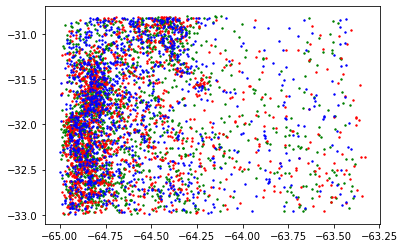

In [17]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

## Find merge/split track indices

In [22]:
# def find_merge_split_tracks(ds):
#     """
#     Find merge/split track indices.
#     """
#     # non-split tracks
#     idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
#     # non-merge tracks
#     idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
#     # non-merge and non-split tracks
#     idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
#     # merge or split tracks
#     idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
#     # Group outputs to dictionary
#     out_dict = {
#         'ms': idx_ms,
#         'nms': idx_nms,
#         'nm': idx_nmerge,
#         'ns': idx_nsplit,
#     }
#     return out_dict

In [20]:
def find_merge_split_tracks(ds, time_window):
    """
    Find merge/split track indices.
    """
    # Get track lifetime
    lifetime = ds.track_duration.load() * time_res

    # Non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())

    # Non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())

    # Merge after time window tracks
    idx_merge_after = ~np.isnan(ds.end_merge_cloudnumber.load()) & (lifetime > np.max(time_window))

    # Combine conditions (satisfy both):
    # - Non-merge or merge after time window
    # - Non-split
    idx_nms = np.logical_and(idx_nsplit, (np.logical_or(idx_nmerge, idx_merge_after)))

    # Group outputs to dictionary
    out_dict = {
        'ns': idx_nsplit,
        'nm': idx_nmerge,
        'ms': idx_merge_after,
        'nms': idx_nms,
    }
    return out_dict

## Subset DataSets with non-merge/non-split tracks

In [21]:
time_window = (ds_d2.attrs['time_start'], ds_d2.attrs['time_end'])
time_window

(0, 60)

In [22]:
tid_d2 = find_merge_split_tracks(ds_d2, time_window)
tid_d3 = find_merge_split_tracks(ds_d3, time_window)
tid_d4 = find_merge_split_tracks(ds_d4, time_window)

In [23]:
# Get number of tracks
ntracks_d2 = ds_d2.sizes['tracks']
ntracks_d3 = ds_d3.sizes['tracks']
ntracks_d4 = ds_d4.sizes['tracks']
print(f'D2 all tracks: {ntracks_d2}')
print(f'D3 all tracks: {ntracks_d3}')
print(f'D4 all tracks: {ntracks_d4}')

D2 all tracks: 1228
D3 all tracks: 1748
D4 all tracks: 1442


In [27]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2} ({100*ntracks_nms_d2/ntracks_d2:.0f}% of all tracks)')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3} ({100*ntracks_nms_d3/ntracks_d3:.0f}% of all tracks)')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4} ({100*ntracks_nms_d4/ntracks_d4:.0f}% of all tracks)')

D2 non-merge-split tracks: 646 (53% of all tracks)
D3 non-merge-split tracks: 1155 (66% of all tracks)
D4 non-merge-split tracks: 1031 (71% of all tracks)


In [25]:
# Get some constents common for all Datasets
ntimes = dsnms_d2.sizes['times']
nz = dsnms_d2.sizes['z']
time_coord = dsnms_d2.times
xtime = time_coord * time_res  # [min]

In [26]:
# Find time coordinate index of the time_window
tidx_start = np.abs(xtime - np.min(time_window)).argmin().item()
tidx_end = np.abs(xtime - np.max(time_window)).argmin().item()
tidx_start, tidx_end

(0, 12)

## Subset cell area/ETH stats to **CI time window** and get their CI-period max values

In [ ]:
# Subset DataSet to CI time_window
dsCI_d2 = dsnms_d2.isel(times=slice(tidx_start, tidx_end))
dsCI_d3 = dsnms_d3.isel(times=slice(tidx_start, tidx_end))
dsCI_d4 = dsnms_d4.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_d2 = dsCI_d2['max_dbz'].load()
maxdbz_d3 = dsCI_d3['max_dbz'].load()
maxdbz_d4 = dsCI_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsCI_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsCI_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsCI_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsCI_d2['cell_area'].load()
cellarea_d3 = dsCI_d3['cell_area'].load()
cellarea_d4 = dsCI_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)
# Max updraft top height
trackmaxWtop_d2 = dsCI_d2.Wtop.max(dim='times')
trackmaxWtop_d3 = dsCI_d3.Wtop.max(dim='times')
trackmaxWtop_d4 = dsCI_d4.Wtop.max(dim='times')
# Calculate max W diameter (Warea_max has no times dimension)
maxWdiam_d2 = 2*np.sqrt(dsCI_d2.Warea_max/np.pi)
maxWdiam_d3 = 2*np.sqrt(dsCI_d3.Warea_max/np.pi)
maxWdiam_d4 = 2*np.sqrt(dsCI_d4.Warea_max/np.pi)

NameError: name 'dsnms_d2' is not defined

## Get **CI-max** 10dBZ ETH and cell diameter percentile values

In [ ]:
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
trackmaxdbz_d2 = maxdbz_d2.max(dim='times')

trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
trackmaxdbz_d3 = maxdbz_d3.max(dim='times')

trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
trackmaxdbz_d4 = maxdbz_d4.max(dim='times')

NameError: name 'maxETH_10dbz_d2' is not defined

In [ ]:
# Add CI-period variables to DataSet
dsnms_d2['CImaxCellDiam'] = trackmaxCellDiam_d2
dsnms_d2['CImaxETH_10dbz'] = trackmaxETH_10dbz_d2
dsnms_d2['CImaxdbz'] = trackmaxdbz_d2
dsnms_d2['CImaxWDiam'] = maxWdiam_d2

# Add CI-period variables to DataSet
dsnms_d3['CImaxCellDiam'] = trackmaxCellDiam_d3
dsnms_d3['CImaxETH_10dbz'] = trackmaxETH_10dbz_d3
dsnms_d3['CImaxdbz'] = trackmaxdbz_d3
dsnms_d3['CImaxWDiam'] = maxWdiam_d3

# Add CI-period variables to DataSet
dsnms_d4['CImaxCellDiam'] = trackmaxCellDiam_d4
dsnms_d4['CImaxETH_10dbz'] = trackmaxETH_10dbz_d4
dsnms_d4['CImaxdbz'] = trackmaxdbz_d4
dsnms_d4['CImaxWDiam'] = maxWdiam_d4

In [33]:
# # Get preCI MU LNB
# # preCI_time = -3  # preCI time
# # Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
# # Add surface elevation to convert LNB from HAMSL to HAGL
# # MULNB_d2 = ((dsnms_d2.EL_height_mu + dsnms_d2.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# # MULNB_d3 = ((dsnms_d3.EL_height_mu + dsnms_d3.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# # MULNB_d4 = ((dsnms_d4.EL_height_mu + dsnms_d4.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# # MULNB_d2 = (dsnms_d2.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# # MULNB_d3 = (dsnms_d3.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# # MULNB_d4 = (dsnms_d4.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d2 = ((dsnms_d2.EL_height_mu)/1000)
# MULNB_d3 = ((dsnms_d3.EL_height_mu)/1000)
# MULNB_d4 = ((dsnms_d4.EL_height_mu)/1000)

In [34]:
# bins = np.arange(0, 16.1, 0.5)
# MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
# MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
# MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

## Get **CI-max** 10dBZ ETH and cell diameter percentile values

In [35]:
# ETH_percentiles = [0.33, 0.5, 0.66]
# trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
# max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

# trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
# maxCellDiam_pts_d2 = trackmaxCellDiam_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max CellDiam percentile values (D2): {maxCellDiam_pts_d2.values}")

In [36]:
# trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
# max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max 10dBZ percentile values (D3): {max10dbz_pts_d3.values}")

# trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
# maxCellDiam_pts_d3 = trackmaxCellDiam_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max CellDiam percentile values (D3): {maxCellDiam_pts_d3.values}")

In [37]:
# trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
# max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max 10dBZ percentile values (D4): {max10dbz_pts_d4.values}")

# trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
# maxCellDiam_pts_d4 = trackmaxCellDiam_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max CellDiam percentile values (D4): {maxCellDiam_pts_d4.values}")

In [38]:
# dsnms_d2.Wtop.mean(dim='tracks').plot(label='Wtop')
# maxETH_10dbz_d2.mean(dim='tracks').plot(label='ETH')
# plt.legend()

## Plot cell diameter & ETH PDF with narrow & wide cell cutoffs

In [39]:
# mpl.rcParams['font.size'] = 14
# mpl.rcParams['font.family'] = 'Helvetica'

# fig, axes = plt.subplots(1, 2, figsize=(12,4), dpi=100)
# lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
# name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

# ax = axes[0]
# bins = np.arange(2, 31, 1)
# bar_data = [trackmaxCellDiam_d2, trackmaxCellDiam_d3, trackmaxCellDiam_d4]
# bar_labels = list(name_map.values())
# bar_colors = list(lcolors.values())
# ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
# ax.legend()
# # Percentile lines
# ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.5), ls='--', color=lcolors['d2'],)
# ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.5), ls=':', color=lcolors['d3'],)
# ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.5), ls='dashdot', color=lcolors['d4'],)
# # ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.33), ls='--', color=lcolors['d2'],)
# # ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
# # ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.33), ls=':', color=lcolors['d3'],)
# # ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
# # ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.33), ls='dashdot', color=lcolors['d4'],)
# # ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
# ax.set_xlim((2,30))
# ax.set_xlabel('Max Cell Diameter (km)')
# ax.set_ylabel('PDF')
# ax.set_title('Cell Width', loc='left')
# ax.grid(ls=':')

# ax = axes[1]
# bins = np.arange(0, 16, 1)
# bar_data = [trackmaxETH_10dbz_d2, trackmaxETH_10dbz_d3, trackmaxETH_10dbz_d4]
# ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)

# # Percentile lines
# ax.axvline(max10dbz_pts_d2.sel(quantile=0.5), ls='--', color=lcolors['d2'],)
# # ax.axvline(max10dbz_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
# ax.axvline(max10dbz_pts_d3.sel(quantile=0.5), ls=':', color=lcolors['d3'],)
# # ax.axvline(max10dbz_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
# ax.axvline(max10dbz_pts_d4.sel(quantile=0.5), ls='dashdot', color=lcolors['d4'],)
# # ax.axvline(max10dbz_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
# ax.legend()
# ax.set_xlim((0,16))
# ax.set_xlabel('Max 10dBZ ETH (km)')
# ax.set_ylabel('PDF')
# ax.set_title('Cell Depth', loc='left')
# ax.grid(ls=':')

# figname = f'{figdir}PDF_maxCellDiam_maxETH10dBZ_d2_d3_d4.png'
# fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## Separate narrow vs. wide cell DataSets

In [42]:
narrow_diam_d2 = 12.93  # km 
narrow_diam_d3 = 7.05  # km  
narrow_diam_d4 = 7.44  # km

wide_diam_d2 = 15.71  # km
wide_diam_d3 = 9.10  # km
wide_diam_d4 = 8.97  # km

In [43]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]
# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0  # [km]
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

In [44]:
# # MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
# MULNB_thresh = 6.0  # [km]

# # Quantiles for narrow & wide
# # narrow_qt = 0.33
# # wide_qt = 0.66
# narrow_qt = 0.5
# wide_qt = 0.66

# # Threshold for max distance between updraft base and LCL height [km]
# max_Wbase_LCL_dist = 2.0
# # Threshold for updraft top fit line slope
# min_Wtop_slope = 0

In [54]:
# ds_narrow_d2.CImaxETH_10dbz

In [62]:
# # Define narrow vs. wide thresholds
# narrow_diam_d2 = maxCellDiam_pts_d2.sel(quantile=narrow_qt).item()
# wide_diam_d2 = maxCellDiam_pts_d2.sel(quantile=wide_qt).item()
# print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.02f} km')
# print(f'Wide diameter threshold (D2): {wide_diam_d2:.02f} km')

# # Define narrow cells:
# # 1. ETH < narrow threshold
# # 2. Mu LNB > MULNB_thresh
# narrow_tracks_d2 = ((trackmaxCellDiam_d2 < narrow_diam_d2) & (MULNB_d2 > MULNB_thresh) \
#                     & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
#                    ).compute()
# # wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# # Define wide cells:
# # 1. ETH >= wide threshold
# # 2. MU LNB > MULNB_thresh
# # 3. Positive updraft top slope
# # 4. Updraft base height close to LCL
# wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh) \
#                   & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
#                   & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
#                  ).compute()
# # Subset DataSets
# ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
# ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
# ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
# ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
# print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
# print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d2 = ((dsnms_d2.CImaxCellDiam < narrow_diam_d2) & (dsnms_d2.EL_height_mu/1000 > MULNB_thresh) \
                    & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d2 = ((dsnms_d2.CImaxCellDiam >= wide_diam_d2) & (dsnms_d2.EL_height_mu/1000 > MULNB_thresh) \
                  & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d2 = (ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d2 = (ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.CImaxdbz
wide_maxdbz_d2 = ds_wide_d2.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.CImaxETH_10dbz
wide_maxETH10dbz_d2 = ds_wide_d2.CImaxETH_10dbz
# CI-max cell diameter
narrow_maxdiam_d2 = ds_narrow_d2.CImaxCellDiam
wide_maxdiam_d2 = ds_wide_d2.CImaxCellDiam
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d2 = ds_narrow_d2.CImaxWDiam
wide_maxWdiam_d2 = ds_wide_d2.CImaxWDiam
# CI-window cloud-base updraft speed
narrow_maxWspeed_d2 = ds_narrow_d2.Wspeed_max
wide_maxWspeed_d2 = ds_wide_d2.Wspeed_max

Number of narrow cells (D2): 424
Number of wide cells (D2): 84


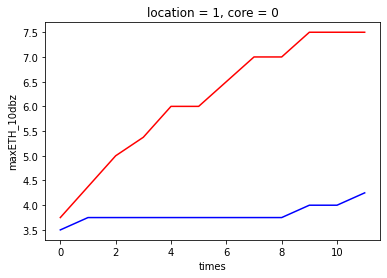

In [63]:
ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='b')
ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='r')

(array([ 0.,  0.,  0.,  1.,  0., 13.,  6., 12., 14., 13.,  7.,  3.,  5.,
         5.,  3.,  2.,  0.,  0.,  0.,  0.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20]),
 <BarContainer object of 20 artists>)

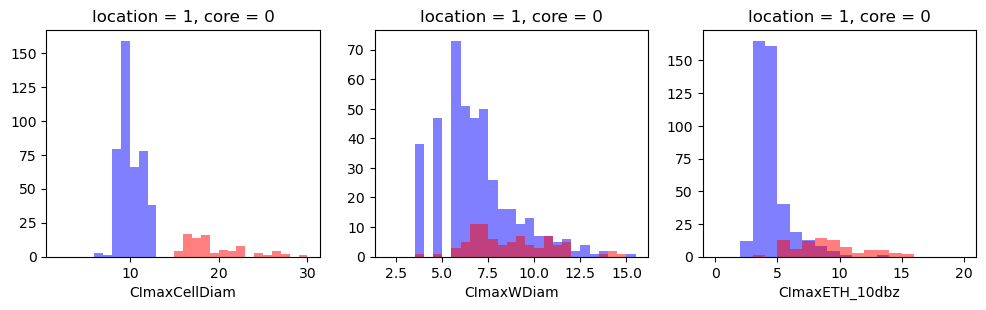

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(2, 16, 0.5)
narrow_maxWdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

In [65]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d3 = ((dsnms_d3.CImaxCellDiam < narrow_diam_d3) & (dsnms_d3.EL_height_mu/1000 > MULNB_thresh) \
                    & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d3 = ((dsnms_d3.CImaxCellDiam >= wide_diam_d3) & (dsnms_d3.EL_height_mu/1000 > MULNB_thresh) \
                  & (dsnms_d3.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (d3): {ntracks_narrow_d3}')
print(f'Number of wide cells (d3): {ntracks_wide_d3}')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d3 = (ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d3 = (ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.CImaxdbz
wide_maxdbz_d3 = ds_wide_d3.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.CImaxETH_10dbz
wide_maxETH10dbz_d3 = ds_wide_d3.CImaxETH_10dbz
# CI-max cell diameter
narrow_maxdiam_d3 = ds_narrow_d3.CImaxCellDiam
wide_maxdiam_d3 = ds_wide_d3.CImaxCellDiam
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d3 = ds_narrow_d3.CImaxWDiam
wide_maxWdiam_d3 = ds_wide_d3.CImaxWDiam
# CI-window cloud-base updraft speed
narrow_maxWspeed_d3 = ds_narrow_d3.Wspeed_max
wide_maxWspeed_d3 = ds_wide_d3.Wspeed_max

Number of narrow cells (d3): 713
Number of wide cells (d3): 217


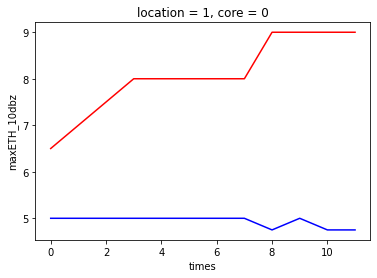

In [66]:
ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='b')
ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='r')

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  6., 14., 16., 62., 52., 25., 18.,
        12.,  8.,  1.,  3.,  0.,  0.,  0.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20]),
 <BarContainer object of 20 artists>)

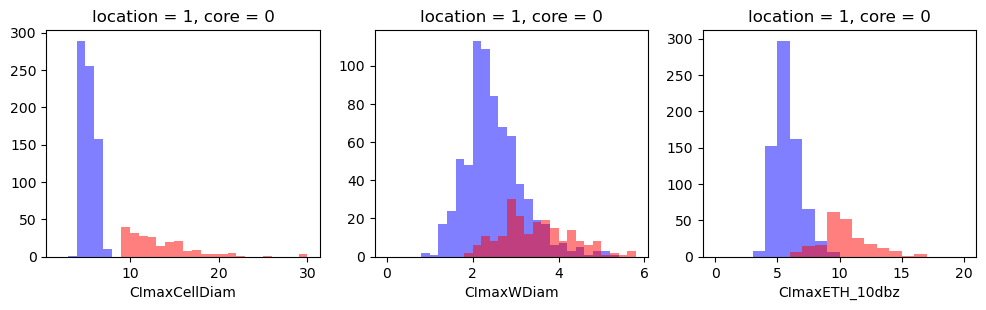

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(0, 6, 0.2)
narrow_maxWdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

In [68]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d4 = ((dsnms_d4.CImaxCellDiam < narrow_diam_d4) & (dsnms_d4.EL_height_mu/1000 > MULNB_thresh) \
                    & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d4 = ((dsnms_d4.CImaxCellDiam >= wide_diam_d4) & (dsnms_d4.EL_height_mu/1000 > MULNB_thresh) \
                  & (dsnms_d4.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (d4): {ntracks_narrow_d4}')
print(f'Number of wide cells (d4): {ntracks_wide_d4}')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d4 = (ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d4 = (ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.CImaxdbz
wide_maxdbz_d4 = ds_wide_d4.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.CImaxETH_10dbz
wide_maxETH10dbz_d4 = ds_wide_d4.CImaxETH_10dbz
# CI-max cell diameter
narrow_maxdiam_d4 = ds_narrow_d4.CImaxCellDiam
wide_maxdiam_d4 = ds_wide_d4.CImaxCellDiam
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d4 = ds_narrow_d4.CImaxWDiam
wide_maxWdiam_d4 = ds_wide_d4.CImaxWDiam
# CI-window cloud-base updraft speed
narrow_maxWspeed_d4 = ds_narrow_d4.Wspeed_max
wide_maxWspeed_d4 = ds_wide_d4.Wspeed_max

Number of narrow cells (d4): 704
Number of wide cells (d4): 190


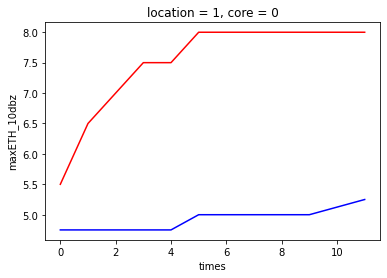

In [69]:
ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='b')
ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='r')

(array([ 0.,  0.,  0.,  0.,  1.,  2.,  9., 19., 39., 52., 30.,  9., 11.,
         6.,  4.,  8.,  0.,  0.,  0.,  0.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20]),
 <BarContainer object of 20 artists>)

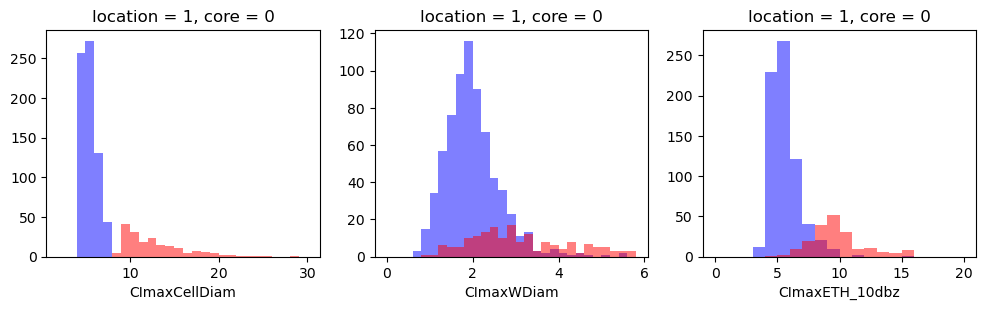

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(0, 6, 0.2)
narrow_maxWdiam_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

(array([ 1.,  5.,  6.,  8., 10., 11., 18.,  7., 11.,  6.,  1.]),
 array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]),
 <BarContainer object of 11 artists>)

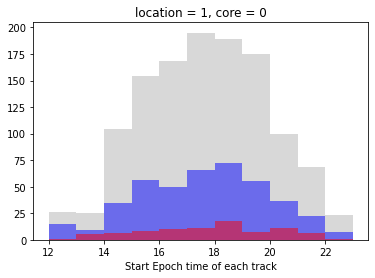

In [71]:
bins = np.arange(12, 24, 1)
ds_d2.start_basetime.dt.hour.plot.hist(bins=bins, color='gray',alpha=0.3,label='All')
# dsnms_d2.start_basetime.dt.hour.plot.hist(bins=bins, color='gray',alpha=0.3,label='All')
ds_narrow_d2.start_basetime.dt.hour.plot.hist(bins=bins, color='b',alpha=0.5,label='Narrow')
ds_wide_d2.start_basetime.dt.hour.plot.hist(bins=bins, color='r',alpha=0.5,label='Wide')

(array([ 0.,  2., 16., 34., 31., 26., 33., 32., 15.,  1.,  0.]),
 array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]),
 <BarContainer object of 11 artists>)

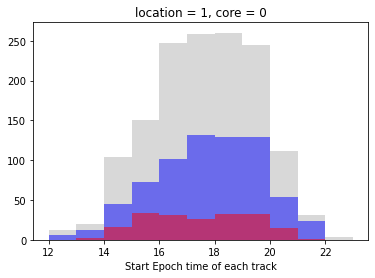

In [72]:
bins = np.arange(12, 24, 1)
ds_d4.start_basetime.dt.hour.plot.hist(bins=bins, color='gray',alpha=0.3,label='All')
# dsnms_d4.start_basetime.dt.hour.plot.hist(bins=bins, color='gray',alpha=0.3,label='All')
ds_narrow_d4.start_basetime.dt.hour.plot.hist(bins=bins, color='b',alpha=0.5,label='Narrow')
ds_wide_d4.start_basetime.dt.hour.plot.hist(bins=bins, color='r',alpha=0.5,label='Wide')

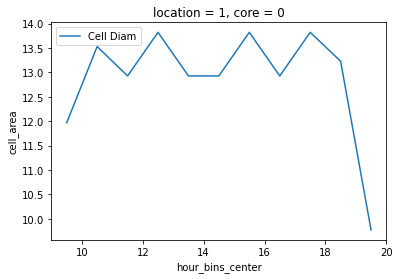

In [73]:
starthour_d2 = ds_d2['start_basetime'].dt.hour
starthourLT_d2 = starthour_d2-3
maxCellDiam_all_d2 = 2 * np.sqrt(ds_d2['cell_area'].max(dim='times').load() / np.pi)
maxETH10dbz_all_d2 = ds_d2['maxETH_10dbz'].max(dim='times').load()

bins_LT = np.arange(9, 21.1, 1)
maxCellDiam_group_d2 = maxCellDiam_all_d2.groupby_bins(starthourLT_d2, bins=bins_LT)
maxETH10dbz_group_d2 = maxETH10dbz_all_d2.groupby_bins(starthourLT_d2, bins=bins_LT)

med_maxCellDiam_LT_d2 = maxCellDiam_group_d2.median()
med_maxETH10dbz_LT_d2 = maxETH10dbz_group_d2.median()

med_maxCellDiam_LT_d2.plot(label='Cell Diam')
plt.legend()

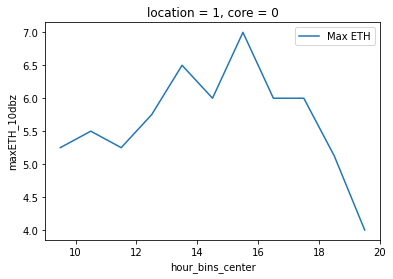

In [74]:
med_maxETH10dbz_LT_d2.plot(label='Max ETH')
plt.legend()

## Get environmental parameters for narrow vs. wide cells

In [75]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d2 = ds_narrow_d2.pEL_height_mu.load()/1000
narrow_pCAPEmu_d2 = ds_narrow_d2.pCAPE_mu.load()
narrow_pCAPEacbl_d2 = ds_narrow_d2.pCAPEacbl_ml.load()
narrow_pCINmu_d2 = ds_narrow_d2.pCIN_mu.load()
narrow_LCLz_d2 = ds_narrow_d2.LCL_height_mu.load()/1000
narrow_LCLt_d2 = ds_narrow_d2.LCL_temp_mu.load()
narrow_pLFCz_d2 = ds_narrow_d2.pLFC_height_mu.load()/1000
# Moisture
narrow_RHacbl_d2 = ds_narrow_d2.RH_mean_ACBL.load()
narrow_RH600mb_d2 = ds_narrow_d2.rh_600mb.load()
narrow_RH500mb_d2 = ds_narrow_d2.rh_500mb.load()
narrow_RH5km_d2 = ds_narrow_d2.rh_5000masl.load()
narrow_RHlfc1500_d2 = ds_narrow_d2.rh_at_pmuLFCplus1500m.load()
narrow_PW_d2 = ds_narrow_d2.PW.load()
narrow_Q850mb_d2 = ds_narrow_d2.rvap_850mb.load()
narrow_Q3km_d2 = ds_narrow_d2.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d2 = ds_narrow_d2.shear_mag_bulk_ACBL_mu.load()
narrow_BWS03km_d2 = ds_narrow_d2.shear_mag_bulk_0to3km.load()
narrow_BWS06km_d2 = ds_narrow_d2.shear_mag_bulk_0to6km.load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d2 = ds_wide_d2.pEL_height_mu.load()/1000
wide_pCAPEmu_d2 = ds_wide_d2.pCAPE_mu.load()
wide_pCAPEacbl_d2 = ds_wide_d2.pCAPEacbl_ml.load()
wide_pCINmu_d2 = ds_wide_d2.pCIN_mu.load()
wide_LCLz_d2 = ds_wide_d2.LCL_height_mu.load()/1000
wide_LCLt_d2 = ds_wide_d2.LCL_temp_mu.load()
wide_pLFCz_d2 = ds_wide_d2.pLFC_height_mu.load()/1000
# Moisture
wide_RHacbl_d2 = ds_wide_d2.RH_mean_ACBL.load()
wide_RH600mb_d2 = ds_wide_d2.rh_600mb.load()
wide_RH500mb_d2 = ds_wide_d2.rh_500mb.load()
wide_RH5km_d2 = ds_wide_d2.rh_5000masl.load()
wide_RHlfc1500_d2 = ds_wide_d2.rh_at_pmuLFCplus1500m.load()
wide_PW_d2 = ds_wide_d2.PW.load()
wide_Q850mb_d2 = ds_wide_d2.rvap_850mb.load()
wide_Q3km_d2 = ds_wide_d2.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d2 = ds_wide_d2.shear_mag_bulk_ACBL_mu.load()
wide_BWS03km_d2 = ds_wide_d2.shear_mag_bulk_0to3km.load()
wide_BWS06km_d2 = ds_wide_d2.shear_mag_bulk_0to6km.load()

In [76]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d3 = ds_narrow_d3.pEL_height_mu.load()/1000
narrow_pCAPEmu_d3 = ds_narrow_d3.pCAPE_mu.load()
narrow_pCAPEacbl_d3 = ds_narrow_d3.pCAPEacbl_ml.load()
narrow_pCINmu_d3 = ds_narrow_d3.pCIN_mu.load()
narrow_LCLz_d3 = ds_narrow_d3.LCL_height_mu.load()/1000
narrow_LCLt_d3 = ds_narrow_d3.LCL_temp_mu.load()
narrow_pLFCz_d3 = ds_narrow_d3.pLFC_height_mu.load()/1000
# Moisture
narrow_RHacbl_d3 = ds_narrow_d3.RH_mean_ACBL.load()
narrow_RH600mb_d3 = ds_narrow_d3.rh_600mb.load()
narrow_RH500mb_d3 = ds_narrow_d3.rh_500mb.load()
narrow_RH5km_d3 = ds_narrow_d3.rh_5000masl.load()
narrow_RHlfc1500_d3 = ds_narrow_d3.rh_at_pmuLFCplus1500m.load()
narrow_PW_d3 = ds_narrow_d3.PW.load()
narrow_Q850mb_d3 = ds_narrow_d3.rvap_850mb.load()
narrow_Q3km_d3 = ds_narrow_d3.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d3 = ds_narrow_d3.shear_mag_bulk_ACBL_mu.load()
narrow_BWS03km_d3 = ds_narrow_d3.shear_mag_bulk_0to3km.load()
narrow_BWS06km_d3 = ds_narrow_d3.shear_mag_bulk_0to6km.load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d3 = ds_wide_d3.pEL_height_mu.load()/1000
wide_pCAPEmu_d3 = ds_wide_d3.pCAPE_mu.load()
wide_pCAPEacbl_d3 = ds_wide_d3.pCAPEacbl_ml.load()
wide_pCINmu_d3 = ds_wide_d3.pCIN_mu.load()
wide_LCLz_d3 = ds_wide_d3.LCL_height_mu.load()/1000
wide_LCLt_d3 = ds_wide_d3.LCL_temp_mu.load()
wide_pLFCz_d3 = ds_wide_d3.pLFC_height_mu.load()/1000
# Moisture
wide_RHacbl_d3 = ds_wide_d3.RH_mean_ACBL.load()
wide_RH600mb_d3 = ds_wide_d3.rh_600mb.load()
wide_RH500mb_d3 = ds_wide_d3.rh_500mb.load()
wide_RH5km_d3 = ds_wide_d3.rh_5000masl.load()
wide_RHlfc1500_d3 = ds_wide_d3.rh_at_pmuLFCplus1500m.load()
wide_PW_d3 = ds_wide_d3.PW.load()
wide_Q850mb_d3 = ds_wide_d3.rvap_850mb.load()
wide_Q3km_d3 = ds_wide_d3.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d3 = ds_wide_d3.shear_mag_bulk_ACBL_mu.load()
wide_BWS03km_d3 = ds_wide_d3.shear_mag_bulk_0to3km.load()
wide_BWS06km_d3 = ds_wide_d3.shear_mag_bulk_0to6km.load()

In [77]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d4 = ds_narrow_d4.pEL_height_mu.load()/1000
narrow_pCAPEmu_d4 = ds_narrow_d4.pCAPE_mu.load()
narrow_pCAPEacbl_d4 = ds_narrow_d4.pCAPEacbl_ml.load()
narrow_pCINmu_d4 = ds_narrow_d4.pCIN_mu.load()
narrow_LCLz_d4 = ds_narrow_d4.LCL_height_mu.load()/1000
narrow_LCLt_d4 = ds_narrow_d4.LCL_temp_mu.load()
narrow_pLFCz_d4 = ds_narrow_d4.pLFC_height_mu.load()/1000
# Moisture
narrow_RHacbl_d4 = ds_narrow_d4.RH_mean_ACBL.load()
narrow_RH600mb_d4 = ds_narrow_d4.rh_600mb.load()
narrow_RH500mb_d4 = ds_narrow_d4.rh_500mb.load()
narrow_RH5km_d4 = ds_narrow_d4.rh_5000masl.load()
narrow_RHlfc1500_d4 = ds_narrow_d4.rh_at_pmuLFCplus1500m.load()
narrow_PW_d4 = ds_narrow_d4.PW.load()
narrow_Q850mb_d4 = ds_narrow_d4.rvap_850mb.load()
narrow_Q3km_d4 = ds_narrow_d4.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d4 = ds_narrow_d4.shear_mag_bulk_ACBL_mu.load()
narrow_BWS03km_d4 = ds_narrow_d4.shear_mag_bulk_0to3km.load()
narrow_BWS06km_d4 = ds_narrow_d4.shear_mag_bulk_0to6km.load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d4 = ds_wide_d4.pEL_height_mu.load()/1000
wide_pCAPEmu_d4 = ds_wide_d4.pCAPE_mu.load()
wide_pCAPEacbl_d4 = ds_wide_d4.pCAPEacbl_ml.load()
wide_pCINmu_d4 = ds_wide_d4.pCIN_mu.load()
wide_LCLz_d4 = ds_wide_d4.LCL_height_mu.load()/1000
wide_LCLt_d4 = ds_wide_d4.LCL_temp_mu.load()
wide_pLFCz_d4 = ds_wide_d4.pLFC_height_mu.load()/1000
# Moisture
wide_RHacbl_d4 = ds_wide_d4.RH_mean_ACBL.load()
wide_RH600mb_d4 = ds_wide_d4.rh_600mb.load()
wide_RH500mb_d4 = ds_wide_d4.rh_500mb.load()
wide_RH5km_d4 = ds_wide_d4.rh_5000masl.load()
wide_RHlfc1500_d4 = ds_wide_d4.rh_at_pmuLFCplus1500m.load()
wide_PW_d4 = ds_wide_d4.PW.load()
wide_Q850mb_d4 = ds_wide_d4.rvap_850mb.load()
wide_Q3km_d4 = ds_wide_d4.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d4 = ds_wide_d4.shear_mag_bulk_ACBL_mu.load()
wide_BWS03km_d4 = ds_wide_d4.shear_mag_bulk_0to3km.load()
wide_BWS06km_d4 = ds_wide_d4.shear_mag_bulk_0to6km.load()

(array([11., 32., 28., 31., 34., 11., 13., 12.,  7., 11.]),
 array([  9.08998 ,  18.18129 ,  27.272598,  36.363907,  45.45522 ,
         54.546528,  63.637836,  72.72915 ,  81.82046 ,  90.911766,
        100.003075], dtype=float32),
 <BarContainer object of 10 artists>)

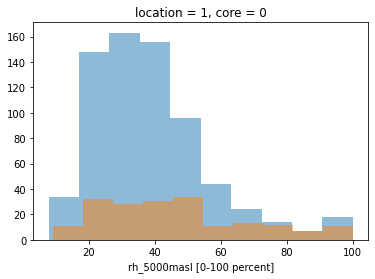

In [78]:
# bins_el = np.arange(0, 20.1, 1)
# narrow_MUEL_d2.sel(times=-3).plot.hist(bins=bins_el, density=True, alpha=0.5)
# wide_MUEL_d2.sel(times=-3).plot.hist(bins=bins_el, density=True, alpha=0.5)

narrow_RH5km_d4.plot.hist(alpha=0.5)
wide_RH5km_d4.plot.hist(alpha=0.5)

/tmp/ipykernel_437532/4151023521.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


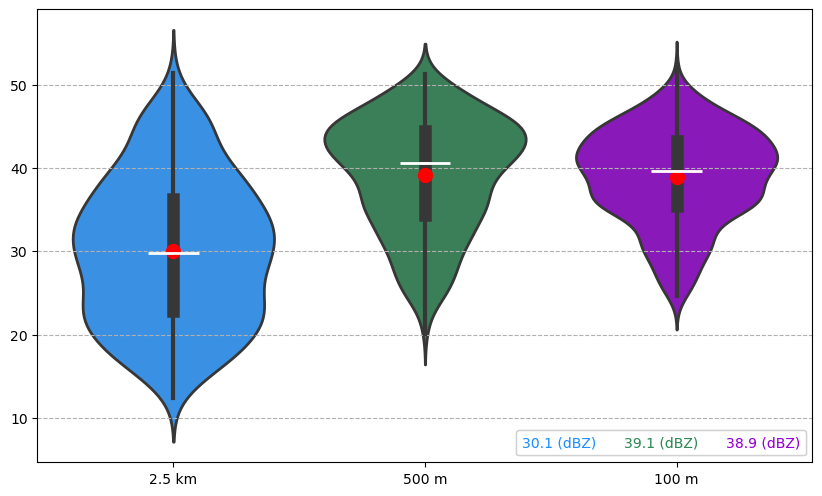

In [79]:
data = [narrow_maxdbz_d2.data, narrow_maxdbz_d3.data, narrow_maxdbz_d4.data]
avg2 = narrow_maxdbz_d2.mean().values
avg3 = narrow_maxdbz_d3.mean().values
avg4 = narrow_maxdbz_d4.mean().values
med2 = narrow_maxdbz_d2.median().values
med3 = narrow_maxdbz_d3.median().values
med4 = narrow_maxdbz_d4.median().values
lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
palette = list(lcolors.values())
lw_kde = 2
color_avg = 'red'
color_med = 'white'
xlabels = list(name_map.values())
leg_fontsize = None
leg_units = 'dBZ'

fig, ax = plt.subplots(1,1,figsize=(10,6),dpi=100)
data[0]
vp = sns.violinplot(data=data, ax=ax, palette=palette, linewidth=lw_kde)
# Plot median value as line
ax.hlines(med2, -0.1, 0.1, lw=2, color=color_med, zorder=4)
ax.hlines(med3, 0.9, 1.1, lw=2, color=color_med, zorder=4)
ax.hlines(med4, 1.9, 2.1, lw=2, color=color_med, zorder=4)
# Plot mean value as circle
ax.scatter(0, avg2, color=color_avg, s=100, zorder=3)
ax.scatter(1, avg3, color=color_avg, s=100, zorder=3)
ax.scatter(2, avg4, color=color_avg, s=100, zorder=3)
ax.grid(ls='--', axis='y')
ax.set_xticklabels(xlabels)
# ax.set_ylabel(ylabel)

legend_avg = [mpl.lines.Line2D([0], [0], color=lcolors['d2'], ls='none', label=f'{avg2:.1f}'+f' ({leg_units})'),
              mpl.lines.Line2D([0], [0], color=lcolors['d3'], ls='none', label=f'{avg3:.1f}'+f' ({leg_units})'),
              mpl.lines.Line2D([0], [0], color=lcolors['d4'], ls='none', label=f'{avg4:.1f}'+f' ({leg_units})'),]
legend = ax.legend(handles=legend_avg, handlelength=0, handletextpad=0, loc='lower right', fontsize=leg_fontsize, labelcolor='linecolor', ncol=3)
ax.add_artist(legend)

## Significance test

In [80]:
def kstest_data(data1, data2, name, alpha=0.05):
    # Remove NaN
    _data1 = data1[~np.isnan(data1)]
    _data2 = data2[~np.isnan(data2)]
    # compare samples
    stat, p = ks_2samp(_data1, _data2)
    # interpret
    # alpha = 0.05
    if p > alpha:
        print(f'{name}: Same distributions')
        sig = '$\\times$'
    else:
        print(f'{name}: Different distributions')
        sig = '$\checkmark$'
    print('Statistics=%.3f, p=%.3f' % (stat, p))
    return sig

In [81]:
# Significance level (P value)
alpha = 0.01
# Lifetime
narrow_sig_lifetime23 = kstest_data(narrow_track_lifetime_d2.data, narrow_track_lifetime_d3.data, 'Narrow Cell Lifetime D2 vs. D3', alpha=alpha)
narrow_sig_lifetime24 = kstest_data(narrow_track_lifetime_d2.data, narrow_track_lifetime_d4.data, 'Narrow Cell Lifetime D2 vs. D4', alpha=alpha)
narrow_sig_lifetime34 = kstest_data(narrow_track_lifetime_d3.data, narrow_track_lifetime_d4.data, 'Narrow Cell Lifetime D3 vs. D4', alpha=alpha)
# Max reflectivity
narrow_sig_maxdbz23 = kstest_data(narrow_maxdbz_d2.data, narrow_maxdbz_d3.data, 'Narrow Cell maxdbz D2 vs. D3', alpha=alpha)
narrow_sig_maxdbz24 = kstest_data(narrow_maxdbz_d2.data, narrow_maxdbz_d4.data, 'Narrow Cell maxdbz D2 vs. D4', alpha=alpha)
narrow_sig_maxdbz34 = kstest_data(narrow_maxdbz_d3.data, narrow_maxdbz_d4.data, 'Narrow Cell maxdbz D3 vs. D4', alpha=alpha)
# Max ETH
narrow_sig_maxETH10dbz23 = kstest_data(narrow_maxETH10dbz_d2.data, narrow_maxETH10dbz_d3.data, 'Narrow Cell maxETH10dbz D2 vs. D3', alpha=alpha)
narrow_sig_maxETH10dbz24 = kstest_data(narrow_maxETH10dbz_d2.data, narrow_maxETH10dbz_d4.data, 'Narrow Cell maxETH10dbz D2 vs. D4', alpha=alpha)
narrow_sig_maxETH10dbz34 = kstest_data(narrow_maxETH10dbz_d3.data, narrow_maxETH10dbz_d4.data, 'Narrow Cell maxETH10dbz D3 vs. D4', alpha=alpha)

# Lifetime
wide_sig_lifetime23 = kstest_data(wide_track_lifetime_d2.data, wide_track_lifetime_d3.data, 'Wide Cell Lifetime D2 vs. D3', alpha=alpha)
wide_sig_lifetime24 = kstest_data(wide_track_lifetime_d2.data, wide_track_lifetime_d4.data, 'Wide Cell Lifetime D2 vs. D4', alpha=alpha)
wide_sig_lifetime34 = kstest_data(wide_track_lifetime_d3.data, wide_track_lifetime_d4.data, 'Wide Cell Lifetime D3 vs. D4', alpha=alpha)
# Max reflectivity
wide_sig_maxdbz23 = kstest_data(wide_maxdbz_d2.data, wide_maxdbz_d3.data, 'Wide Cell maxdbz D2 vs. D3', alpha=alpha)
wide_sig_maxdbz24 = kstest_data(wide_maxdbz_d2.data, wide_maxdbz_d4.data, 'Wide Cell maxdbz D2 vs. D4', alpha=alpha)
wide_sig_maxdbz34 = kstest_data(wide_maxdbz_d3.data, wide_maxdbz_d4.data, 'Wide Cell maxdbz D3 vs. D4', alpha=alpha)
# Max ETH
wide_sig_maxETH10dbz23 = kstest_data(wide_maxETH10dbz_d2.data, wide_maxETH10dbz_d3.data, 'Wide Cell maxETH10dbz D2 vs. D3', alpha=alpha)
wide_sig_maxETH10dbz24 = kstest_data(wide_maxETH10dbz_d2.data, wide_maxETH10dbz_d4.data, 'Wide Cell maxETH10dbz D2 vs. D4', alpha=alpha)
wide_sig_maxETH10dbz34 = kstest_data(wide_maxETH10dbz_d3.data, wide_maxETH10dbz_d4.data, 'Wide Cell maxETH10dbz D3 vs. D4', alpha=alpha)

Narrow Cell Lifetime D2 vs. D3: Different distributions
Statistics=0.225, p=0.000
Narrow Cell Lifetime D2 vs. D4: Different distributions
Statistics=0.250, p=0.000
Narrow Cell Lifetime D3 vs. D4: Same distributions
Statistics=0.036, p=0.735
Narrow Cell maxdbz D2 vs. D3: Different distributions
Statistics=0.445, p=0.000
Narrow Cell maxdbz D2 vs. D4: Different distributions
Statistics=0.490, p=0.000
Narrow Cell maxdbz D3 vs. D4: Different distributions
Statistics=0.093, p=0.004
Narrow Cell maxETH10dbz D2 vs. D3: Different distributions
Statistics=0.578, p=0.000
Narrow Cell maxETH10dbz D2 vs. D4: Different distributions
Statistics=0.508, p=0.000
Narrow Cell maxETH10dbz D3 vs. D4: Different distributions
Statistics=0.120, p=0.000
Wide Cell Lifetime D2 vs. D3: Same distributions
Statistics=0.180, p=0.035
Wide Cell Lifetime D2 vs. D4: Same distributions
Statistics=0.168, p=0.066
Wide Cell Lifetime D3 vs. D4: Same distributions
Statistics=0.024, p=1.000
Wide Cell maxdbz D2 vs. D3: Different d

## Create Pandas DataFrame in long format for split violin plots

In [83]:
def make_df(var_n_d2, var_n_d3, var_n_d4, var_w_d2, var_w_d3, var_w_d4, varname):
    var_d2 = np.hstack((var_n_d2.values, var_w_d2.values))
    CellType_d2 = np.hstack((np.full(len(var_n_d2), 'Narrow'), np.full(len(var_w_d2), 'Wide')))

    var_d3 = np.hstack((var_n_d3.values, var_w_d3.values))
    CellType_d3 = np.hstack((np.full(len(var_n_d3), 'Narrow'), np.full(len(var_w_d3), 'Wide')))

    var_d4 = np.hstack((var_n_d4.values, var_w_d4.values))
    CellType_d4 = np.hstack((np.full(len(var_n_d4), 'Narrow'), np.full(len(var_w_d4), 'Wide')))

    # Create a DataFrame for each dataset
    df2 = pd.DataFrame({varname: var_d2, 'Cell Type': CellType_d2, 'WRF': '2.5 km'})
    df3 = pd.DataFrame({varname: var_d3, 'Cell Type': CellType_d3, 'WRF': '500 m'})
    df4 = pd.DataFrame({varname: var_d4, 'Cell Type': CellType_d4, 'WRF': '100 m'})

    # Concatenate the DataFrames into one long DataFrame
    df = pd.concat([df2, df3, df4], ignore_index=True)
    return df

In [93]:
df_maxdbz = make_df(narrow_maxdbz_d2, narrow_maxdbz_d3, narrow_maxdbz_d4, 
                    wide_maxdbz_d2, wide_maxdbz_d3, wide_maxdbz_d4, 'Max Reflectivity (dBZ)')

In [94]:
df_track_lifetime = make_df(narrow_track_lifetime_d2, narrow_track_lifetime_d3, narrow_track_lifetime_d4, 
                            wide_track_lifetime_d2, wide_track_lifetime_d3, wide_track_lifetime_d4, 'Lifetime (min)')

In [95]:
df_maxETH10dbz = make_df(narrow_maxETH10dbz_d2, narrow_maxETH10dbz_d3, narrow_maxETH10dbz_d4, 
                         wide_maxETH10dbz_d2, wide_maxETH10dbz_d3, wide_maxETH10dbz_d4, 'Max 10dBZ ETH (km)')

In [88]:
# maxdbz_d2 = np.hstack((narrow_maxdbz_d2.values, wide_maxdbz_d2.values))
# CellType_d2 = np.hstack((np.full(len(narrow_maxdbz_d2), 'Narrow'), np.full(len(wide_maxdbz_d2), 'Wide')))

# maxdbz_d3 = np.hstack((narrow_maxdbz_d3.values, wide_maxdbz_d3.values))
# CellType_d3 = np.hstack((np.full(len(narrow_maxdbz_d3), 'Narrow'), np.full(len(wide_maxdbz_d3), 'Wide')))

# maxdbz_d4 = np.hstack((narrow_maxdbz_d4.values, wide_maxdbz_d4.values))
# CellType_d4 = np.hstack((np.full(len(narrow_maxdbz_d4), 'Narrow'), np.full(len(wide_maxdbz_d4), 'Wide')))

# # Create a DataFrame for each dataset
# df2 = pd.DataFrame({'Max Reflectivity (dBZ)': maxdbz_d2, 'Cell Type': CellType_d2, 'WRF': '2.5 km'})
# df3 = pd.DataFrame({'Max Reflectivity (dBZ)': maxdbz_d3, 'Cell Type': CellType_d3, 'WRF': '500 m'})
# df4 = pd.DataFrame({'Max Reflectivity (dBZ)': maxdbz_d4, 'Cell Type': CellType_d4, 'WRF': '100 m'})

# # Concatenate the DataFrames into one long DataFrame
# df_maxdbz = pd.concat([df2, df3, df4], ignore_index=True)

In [70]:
# track_lifetime_d2 = np.hstack((narrow_track_lifetime_d2.values, wide_track_lifetime_d2.values))
# CellType_d2 = np.hstack((np.full(len(narrow_track_lifetime_d2), 'Narrow'), np.full(len(wide_track_lifetime_d2), 'Wide')))

# track_lifetime_d3 = np.hstack((narrow_track_lifetime_d3.values, wide_track_lifetime_d3.values))
# CellType_d3 = np.hstack((np.full(len(narrow_track_lifetime_d3), 'Narrow'), np.full(len(wide_track_lifetime_d3), 'Wide')))

# track_lifetime_d4 = np.hstack((narrow_track_lifetime_d4.values, wide_track_lifetime_d4.values))
# CellType_d4 = np.hstack((np.full(len(narrow_track_lifetime_d4), 'Narrow'), np.full(len(wide_track_lifetime_d4), 'Wide')))

# # Create a DataFrame for each dataset
# df2 = pd.DataFrame({'Lifetime (min)': track_lifetime_d2, 'Cell Type': CellType_d2, 'WRF': '2.5 km'})
# df3 = pd.DataFrame({'Lifetime (min)': track_lifetime_d3, 'Cell Type': CellType_d3, 'WRF': '500 m'})
# df4 = pd.DataFrame({'Lifetime (min)': track_lifetime_d4, 'Cell Type': CellType_d4, 'WRF': '100 m'})

# # Concatenate the DataFrames into one long DataFrame
# df_track_lifetime = pd.concat([df2, df3, df4], ignore_index=True)

In [71]:
# maxETH10dbz_d2 = np.hstack((narrow_maxETH10dbz_d2.values, wide_maxETH10dbz_d2.values))
# CellType_d2 = np.hstack((np.full(len(narrow_maxETH10dbz_d2), 'Narrow'), np.full(len(wide_maxETH10dbz_d2), 'Wide')))

# maxETH10dbz_d3 = np.hstack((narrow_maxETH10dbz_d3.values, wide_maxETH10dbz_d3.values))
# CellType_d3 = np.hstack((np.full(len(narrow_maxETH10dbz_d3), 'Narrow'), np.full(len(wide_maxETH10dbz_d3), 'Wide')))

# maxETH10dbz_d4 = np.hstack((narrow_maxETH10dbz_d4.values, wide_maxETH10dbz_d4.values))
# CellType_d4 = np.hstack((np.full(len(narrow_maxETH10dbz_d4), 'Narrow'), np.full(len(wide_maxETH10dbz_d4), 'Wide')))

# # Create a DataFrame for each dataset
# df2 = pd.DataFrame({'Max 10dBZ ETH (km)': maxETH10dbz_d2, 'Cell Type': CellType_d2, 'WRF': '2.5 km'})
# df3 = pd.DataFrame({'Max 10dBZ ETH (km)': maxETH10dbz_d3, 'Cell Type': CellType_d3, 'WRF': '500 m'})
# df4 = pd.DataFrame({'Max 10dBZ ETH (km)': maxETH10dbz_d4, 'Cell Type': CellType_d4, 'WRF': '100 m'})

# # Concatenate the DataFrames into one long DataFrame
# df_maxETH10dbz = pd.concat([df2, df3, df4], ignore_index=True)

In [96]:
# Significance level (P value)
alpha = 0.01
# Lifetime
sig_lifetime_d2 = kstest_data(narrow_track_lifetime_d2.data, wide_track_lifetime_d2.data, 'Cell Lifetime D2', alpha=alpha)
sig_lifetime_d3 = kstest_data(narrow_track_lifetime_d3.data, wide_track_lifetime_d3.data, 'Cell Lifetime D3', alpha=alpha)
sig_lifetime_d4 = kstest_data(narrow_track_lifetime_d4.data, wide_track_lifetime_d4.data, 'Cell Lifetime D4', alpha=alpha)
# Max reflectivity
sig_maxdbz_d2 = kstest_data(narrow_maxdbz_d2.data, wide_maxdbz_d2.data, 'Cell maxdbz D2', alpha=alpha)
sig_maxdbz_d3 = kstest_data(narrow_maxdbz_d3.data, wide_maxdbz_d3.data, 'Cell maxdbz D3', alpha=alpha)
sig_maxdbz_d4 = kstest_data(narrow_maxdbz_d4.data, wide_maxdbz_d4.data, 'Cell maxdbz D4', alpha=alpha)
# Max ETH
sig_maxETH10dbz_d2 = kstest_data(narrow_maxETH10dbz_d2.data, wide_maxETH10dbz_d2.data, 'Cell maxETH10dbz D2', alpha=alpha)
sig_maxETH10dbz_d3 = kstest_data(narrow_maxETH10dbz_d3.data, wide_maxETH10dbz_d3.data, 'Cell maxETH10dbz D3', alpha=alpha)
sig_maxETH10dbz_d4 = kstest_data(narrow_maxETH10dbz_d4.data, wide_maxETH10dbz_d4.data, 'Cell maxETH10dbz D4', alpha=alpha)

Cell Lifetime D2: Different distributions
Statistics=0.676, p=0.000
Cell Lifetime D3: Different distributions
Statistics=0.748, p=0.000
Cell Lifetime D4: Different distributions
Statistics=0.757, p=0.000
Cell maxdbz D2: Different distributions
Statistics=0.891, p=0.000
Cell maxdbz D3: Different distributions
Statistics=0.903, p=0.000
Cell maxdbz D4: Different distributions
Statistics=0.911, p=0.000
Cell maxETH10dbz D2: Different distributions
Statistics=0.809, p=0.000
Cell maxETH10dbz D3: Different distributions
Statistics=0.875, p=0.000
Cell maxETH10dbz D4: Different distributions
Statistics=0.839, p=0.000


## Function to plot nrow x ncol of split violin

In [97]:
def plot_mxn_violin_split(nrow, ncol, da, x_names=None, y_names=None, hue=None, sigtest=None, sig_markersize=None, 
                          wspace=None, hspace=None, gap=.15, box_width=.1,
                          ylabels=None, ylims=None, titles=None, fontsize=None, figsize=None, figname=None, dpi=300):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig = plt.figure(figsize=figsize, dpi=100)    
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    
    custom_palette = {'Narrow': 'orange', 'Wide': 'springgreen'}
    leg_fontsize = None
       
    for row in range(nrow):
        for col in range(ncol):
            ax = plt.subplot(gs[row,col])
            violin_data = da[row][col]
            # Violin plot (skip box plot: inner=None)
            vp = sns.violinplot(x=x_names[row][col], y=y_names[row][col], hue=hue, data=violin_data, split=True, gap=gap, palette=custom_palette, inner=None, ax=ax)
            
            # Overlay the box plot with custom properties (violin plot has limited control on box properties)
            # Note that the box position do not follow the violins if gap is changed from default
            sns.boxplot(x=x_names[row][col], y=y_names[row][col], hue=hue, data=violin_data, 
                        width=box_width,
                        showcaps=False, showfliers=False,
                        boxprops={'facecolor':'k'},  # No fill color for the box
                        whiskerprops={'linewidth':2, 'color':'black'},  # Custom whiskers
                        capprops={'visible': False},  # No caps
                        medianprops={'color':'white', 'linewidth':2},  # Median as white line
                        # meanline=True, showmeans=True,  # Show the mean as a line
                        # meanprops={'color':'red', 'linewidth':2},  # Mean as a red line
                        dodge=True, ax=ax)
            # Axis
            ax.set_xlabel('')
            ax.grid(ls=':', axis='y')
            ax.set_title(titles[row][col], loc='left')
            
            # Add significance test below each x-axis label
            for i, label in enumerate(ax.get_xticks()):
                ax.text(i, -0.1, sigtest[row][i], ha='center', va='top', fontsize=sig_markersize, color='r', transform=ax.get_xaxis_transform())
            
            # Remove the legend created by the boxplot
            handles, labels = ax.get_legend_handles_labels()
            if (row == 0) & (col == 0):
                ax.legend(handles[:2], labels[:2], title='', 
                          loc='lower right', bbox_to_anchor=(1, 1.01), ncol=2)  # Keep only the first 2 handles (violin legend)
            else:
                ax.legend([],[], frameon=False)

    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+2h/ViolinSplit_NarrowWide_Lifetime_maxRefl_maxETH10dBZ_d2_d3_d4.png


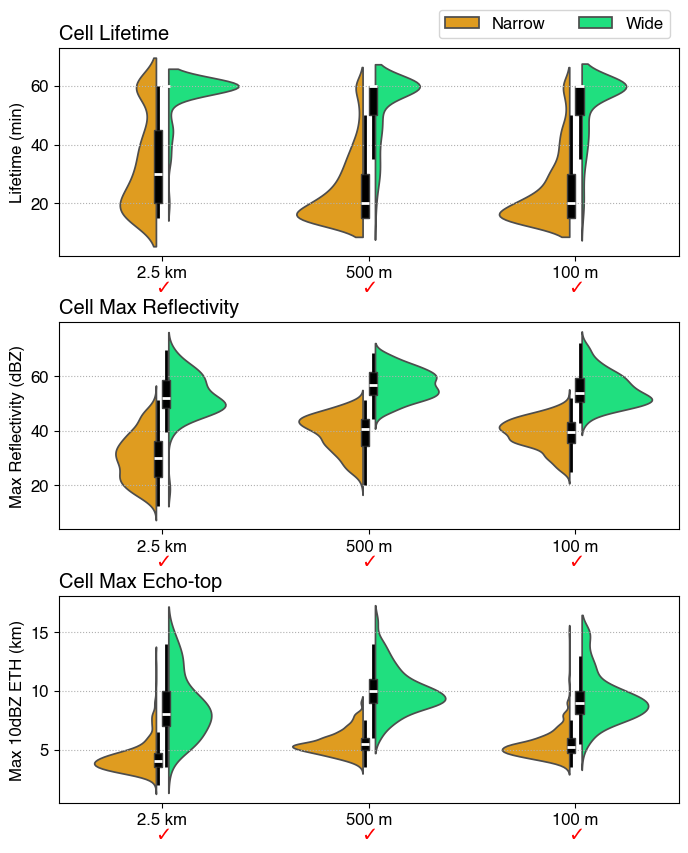

In [98]:
data_arr = [[df_track_lifetime], [df_maxdbz], [df_maxETH10dbz]]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
sigtest = [
    [sig_lifetime_d2, sig_lifetime_d3, sig_lifetime_d4],
    [sig_maxdbz_d2, sig_maxdbz_d3, sig_maxdbz_d4],
    [sig_maxETH10dbz_d2, sig_maxETH10dbz_d3, sig_maxETH10dbz_d4],
]
sig_markersize = 14
x_names = [['WRF']]*nrow
y_names = [['Lifetime (min)'], ['Max Reflectivity (dBZ)'], ['Max 10dBZ ETH (km)']]
hue='Cell Type'
titles = [['Cell Lifetime'], ['Cell Max Reflectivity'], ['Cell Max Echo-top']]

ylabels = None
ylims = None
# ylims = [[(0,80)]*2, [(0,75)]*2, [(0,18)]*2]
xlabels = None
gap = .15
box_width = 0.08
hspace = 0.32
fontsize = 12
figsize = (8, 10)
dpi = 300
figname = f'{figdir}ViolinSplit_NarrowWide_Lifetime_maxRefl_maxETH10dBZ_d2_d3_d4.png'
print(figname)
fig = plot_mxn_violin_split(nrow, ncol, data_arr, x_names=x_names, y_names=y_names, hue=hue, sigtest=sigtest, sig_markersize=sig_markersize,
                            hspace=hspace, gap=gap, box_width=box_width,
                            ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

## Instability variables

In [99]:
df_pELmu = make_df(narrow_pELmu_d2, narrow_pELmu_d3, narrow_pELmu_d4, 
                    wide_pELmu_d2, wide_pELmu_d3, wide_pELmu_d4, 'MU LNB (km)')

In [100]:
df_pCAPEmu = make_df(narrow_pCAPEmu_d2, narrow_pCAPEmu_d3, narrow_pCAPEmu_d4, 
                     wide_pCAPEmu_d2, wide_pCAPEmu_d3, wide_pCAPEmu_d4, 'MU CAPE (J kg$^{-1}$)')

In [101]:
df_pCAPEacbl = make_df(narrow_pCAPEacbl_d2, narrow_pCAPEacbl_d3, narrow_pCAPEacbl_d4, 
                     wide_pCAPEacbl_d2, wide_pCAPEacbl_d3, wide_pCAPEacbl_d4, 'ACBL CAPE (J kg$^{-1}$)')

In [104]:
# Significance level (P value)
alpha = 0.01
# MU LNB
sig_pELmu_d2 = kstest_data(narrow_pELmu_d2.data, wide_pELmu_d2.data, 'Cell pELmu D2', alpha=alpha)
sig_pELmu_d3 = kstest_data(narrow_pELmu_d3.data, wide_pELmu_d3.data, 'Cell pELmu D3', alpha=alpha)
sig_pELmu_d4 = kstest_data(narrow_pELmu_d4.data, wide_pELmu_d4.data, 'Cell pELmu D4', alpha=alpha)
# MU CAPE
sig_pCAPEmu_d2 = kstest_data(narrow_pCAPEmu_d2.data, wide_pCAPEmu_d2.data, 'Cell pCAPEmu D2', alpha=alpha)
sig_pCAPEmu_d3 = kstest_data(narrow_pCAPEmu_d3.data, wide_pCAPEmu_d3.data, 'Cell pCAPEmu D3', alpha=alpha)
sig_pCAPEmu_d4 = kstest_data(narrow_pCAPEmu_d4.data, wide_pCAPEmu_d4.data, 'Cell pCAPEmu D4', alpha=alpha)
# ACBL CAPE
sig_pCAPEacbl_d2 = kstest_data(narrow_pCAPEacbl_d2.data, wide_pCAPEacbl_d2.data, 'Cell pCAPEacbl D2', alpha=alpha)
sig_pCAPEacbl_d3 = kstest_data(narrow_pCAPEacbl_d3.data, wide_pCAPEacbl_d3.data, 'Cell pCAPEacbl D3', alpha=alpha)
sig_pCAPEacbl_d4 = kstest_data(narrow_pCAPEacbl_d4.data, wide_pCAPEacbl_d4.data, 'Cell pCAPEacbl D4', alpha=alpha)

Cell pELmu D2: Same distributions
Statistics=0.163, p=0.043
Cell pELmu D3: Same distributions
Statistics=0.089, p=0.136
Cell pELmu D4: Same distributions
Statistics=0.131, p=0.011
Cell pCAPEmu D2: Different distributions
Statistics=0.249, p=0.000
Cell pCAPEmu D3: Different distributions
Statistics=0.157, p=0.000
Cell pCAPEmu D4: Same distributions
Statistics=0.118, p=0.028
Cell pCAPEacbl D2: Different distributions
Statistics=0.318, p=0.000
Cell pCAPEacbl D3: Different distributions
Statistics=0.217, p=0.000
Cell pCAPEacbl D4: Different distributions
Statistics=0.154, p=0.001


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+2h/ViolinSplit_NarrowWide_pEL_pCAPE_d2_d3_d4.png


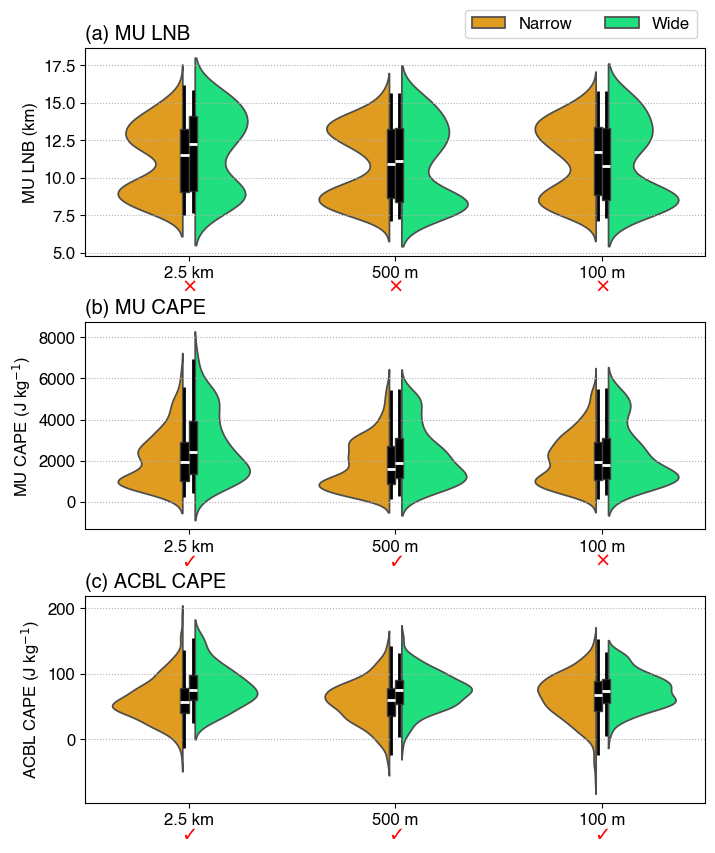

In [105]:
data_arr = [[df_pELmu], [df_pCAPEmu], [df_pCAPEacbl]]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
sigtest = [
    [sig_pELmu_d2, sig_pELmu_d3, sig_pELmu_d4],
    [sig_pCAPEmu_d2, sig_pCAPEmu_d3, sig_pCAPEmu_d4],
    [sig_pCAPEacbl_d2, sig_pCAPEacbl_d3, sig_pCAPEacbl_d4],
]
sig_markersize = 14
x_names = [['WRF']]*nrow
y_names = [['MU LNB (km)'], ['MU CAPE (J kg$^{-1}$)'], ['ACBL CAPE (J kg$^{-1}$)']]
hue='Cell Type'
titles = [['(a) MU LNB'], ['(b) MU CAPE'], ['(c) ACBL CAPE']]

ylabels = None
ylims = None
# ylims = [[(0,80)]*2, [(0,75)]*2, [(0,18)]*2]
xlabels = None
gap = .15
box_width = 0.08
hspace = 0.32
fontsize = 12
figsize = (8, 10)
dpi = 300
figname = f'{figdir}ViolinSplit_NarrowWide_pEL_pCAPE_d2_d3_d4.png'
print(figname)
fig = plot_mxn_violin_split(nrow, ncol, data_arr, x_names=x_names, y_names=y_names, hue=hue, sigtest=sigtest, sig_markersize=sig_markersize,
                            hspace=hspace, gap=gap, box_width=box_width,
                            ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

## Low level thermodynamics

In [106]:
df_LCLt = make_df(narrow_LCLt_d2, narrow_LCLt_d3, narrow_LCLt_d4, 
                  wide_LCLt_d2, wide_LCLt_d3, wide_LCLt_d4, 'LCL Temp (K)')

In [107]:
df_LCLz = make_df(narrow_LCLz_d2, narrow_LCLz_d3, narrow_LCLz_d4, 
                  wide_LCLz_d2, wide_LCLz_d3, wide_LCLz_d4, 'LCL Height (km)')

In [108]:
df_pLFCz = make_df(narrow_pLFCz_d2, narrow_pLFCz_d3, narrow_pLFCz_d4, 
                  wide_pLFCz_d2, wide_pLFCz_d3, wide_pLFCz_d4, 'LFC Height (km)')

In [111]:
# Significance level (P value)
alpha = 0.01
# LCL temp
sig_LCLt_d2 = kstest_data(narrow_LCLt_d2.data, wide_LCLt_d2.data, 'Cell LCLt D2', alpha=alpha)
sig_LCLt_d3 = kstest_data(narrow_LCLt_d3.data, wide_LCLt_d3.data, 'Cell LCLt D3', alpha=alpha)
sig_LCLt_d4 = kstest_data(narrow_LCLt_d4.data, wide_LCLt_d4.data, 'Cell LCLt D4', alpha=alpha)
# LCL height
sig_LCLz_d2 = kstest_data(narrow_LCLz_d2.data, wide_LCLz_d2.data, 'Cell LCLz D2', alpha=alpha)
sig_LCLz_d3 = kstest_data(narrow_LCLz_d3.data, wide_LCLz_d3.data, 'Cell LCLz D3', alpha=alpha)
sig_LCLz_d4 = kstest_data(narrow_LCLz_d4.data, wide_LCLz_d4.data, 'Cell LCLz D4', alpha=alpha)
# LFC height
sig_pLFCz_d2 = kstest_data(narrow_pLFCz_d2.data, wide_pLFCz_d2.data, 'Cell pLFCz D2', alpha=alpha)
sig_pLFCz_d3 = kstest_data(narrow_pLFCz_d3.data, wide_pLFCz_d3.data, 'Cell pLFCz D3', alpha=alpha)
sig_pLFCz_d4 = kstest_data(narrow_pLFCz_d4.data, wide_pLFCz_d4.data, 'Cell pLFCz D4', alpha=alpha)

Cell LCLt D2: Same distributions
Statistics=0.177, p=0.021
Cell LCLt D3: Different distributions
Statistics=0.147, p=0.001
Cell LCLt D4: Same distributions
Statistics=0.104, p=0.073
Cell LCLz D2: Different distributions
Statistics=0.204, p=0.005
Cell LCLz D3: Different distributions
Statistics=0.271, p=0.000
Cell LCLz D4: Different distributions
Statistics=0.222, p=0.000
Cell pLFCz D2: Different distributions
Statistics=0.223, p=0.002
Cell pLFCz D3: Different distributions
Statistics=0.283, p=0.000
Cell pLFCz D4: Different distributions
Statistics=0.223, p=0.000


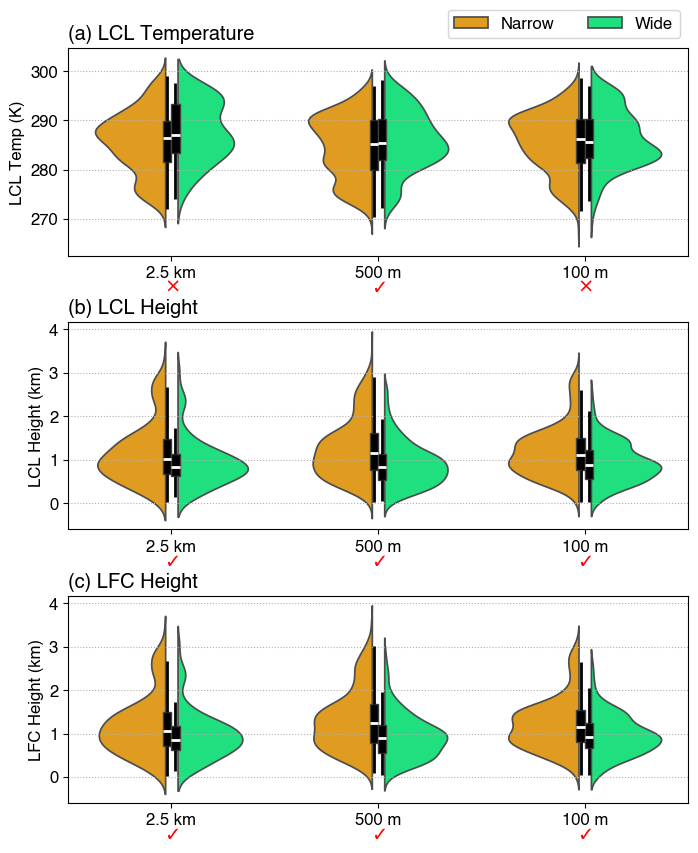

In [112]:
data_arr = [[df_LCLt], [df_LCLz], [df_pLFCz]]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
sigtest = [
    [sig_LCLt_d2, sig_LCLt_d3, sig_LCLt_d4],
    [sig_LCLz_d2, sig_LCLz_d3, sig_LCLz_d4],
    [sig_pLFCz_d2, sig_pLFCz_d3, sig_pLFCz_d4],
]
sig_markersize = 14
x_names = [['WRF']]*nrow
y_names = [['LCL Temp (K)'], ['LCL Height (km)'], ['LFC Height (km)']]
hue='Cell Type'
titles = [['(a) LCL Temperature'], ['(b) LCL Height'], ['(c) LFC Height']]

ylabels = None
ylims = None
# ylims = [[(0,80)]*2, [(0,75)]*2, [(0,18)]*2]
xlabels = None
gap = .15
box_width = 0.08
hspace = 0.32
fontsize = 12
figsize = (8, 10)
dpi = 300
figname = f'{figdir}ViolinSplit_NarrowWide_LCL_pLFC_d2_d3_d4.png'
fig = plot_mxn_violin_split(nrow, ncol, data_arr, x_names=x_names, y_names=y_names, hue=hue, sigtest=sigtest, sig_markersize=sig_markersize,
                            hspace=hspace, gap=gap, box_width=box_width,
                            ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

## Relative humidity variables

In [113]:
df_RHacbl = make_df(narrow_RHacbl_d2, narrow_RHacbl_d3, narrow_RHacbl_d4, 
                    wide_RHacbl_d2, wide_RHacbl_d3, wide_RHacbl_d4, 'ACBL RH (%)')

In [114]:
df_RHlfc1500 = make_df(narrow_RHlfc1500_d2, narrow_RHlfc1500_d3, narrow_RHlfc1500_d4, 
                       wide_RHlfc1500_d2, wide_RHlfc1500_d3, wide_RHlfc1500_d4, 'LFC+1.5km RH (%)')

In [115]:
df_RH600mb = make_df(narrow_RH600mb_d2, narrow_RH600mb_d3, narrow_RH600mb_d4, 
                       wide_RH600mb_d2, wide_RH600mb_d3, wide_RH600mb_d4, '600hPa RH (%)')

In [116]:
df_RH5km = make_df(narrow_RH5km_d2, narrow_RH5km_d3, narrow_RH5km_d4, 
                   wide_RH5km_d2, wide_RH5km_d3, wide_RH5km_d4, '5km RH (%)')

In [121]:
# Significance level (P value)
alpha = 0.01
# ACBL RH
sig_RHacbl_d2 = kstest_data(narrow_RHacbl_d2.data, wide_RHacbl_d2.data, 'Cell RHacbl D2', alpha=alpha)
sig_RHacbl_d3 = kstest_data(narrow_RHacbl_d3.data, wide_RHacbl_d3.data, 'Cell RHacbl D3', alpha=alpha)
sig_RHacbl_d4 = kstest_data(narrow_RHacbl_d4.data, wide_RHacbl_d4.data, 'Cell RHacbl D4', alpha=alpha)
# ACBL+1.5km RH
sig_RHlfc1500_d2 = kstest_data(narrow_RHlfc1500_d2.data, wide_RHlfc1500_d2.data, 'Cell RHlfc1500 D2', alpha=alpha)
sig_RHlfc1500_d3 = kstest_data(narrow_RHlfc1500_d3.data, wide_RHlfc1500_d3.data, 'Cell RHlfc1500 D3', alpha=alpha)
sig_RHlfc1500_d4 = kstest_data(narrow_RHlfc1500_d4.data, wide_RHlfc1500_d4.data, 'Cell RHlfc1500 D4', alpha=alpha)
# 600 hP RH
sig_RH600mb_d2 = kstest_data(narrow_RH600mb_d2.data, wide_RH600mb_d2.data, 'Cell RH600mb D2', alpha=alpha)
sig_RH600mb_d3 = kstest_data(narrow_RH600mb_d3.data, wide_RH600mb_d3.data, 'Cell RH600mb D3', alpha=alpha)
sig_RH600mb_d4 = kstest_data(narrow_RH600mb_d4.data, wide_RH600mb_d4.data, 'Cell RH600mb D4', alpha=alpha)
# 5km RH
sig_RH5km_d2 = kstest_data(narrow_RH5km_d2.data, wide_RH5km_d2.data, 'Cell RH5km D2', alpha=alpha)
sig_RH5km_d3 = kstest_data(narrow_RH5km_d3.data, wide_RH5km_d3.data, 'Cell RH5km D3', alpha=alpha)
sig_RH5km_d4 = kstest_data(narrow_RH5km_d4.data, wide_RH5km_d4.data, 'Cell RH5km D4', alpha=alpha)

Cell RHacbl D2: Different distributions
Statistics=0.323, p=0.000
Cell RHacbl D3: Different distributions
Statistics=0.236, p=0.000
Cell RHacbl D4: Different distributions
Statistics=0.311, p=0.000
Cell RHlfc1500 D2: Different distributions
Statistics=0.291, p=0.000
Cell RHlfc1500 D3: Different distributions
Statistics=0.273, p=0.000
Cell RHlfc1500 D4: Different distributions
Statistics=0.303, p=0.000
Cell RH600mb D2: Different distributions
Statistics=0.205, p=0.005
Cell RH600mb D3: Different distributions
Statistics=0.234, p=0.000
Cell RH600mb D4: Different distributions
Statistics=0.314, p=0.000
Cell RH5km D2: Same distributions
Statistics=0.134, p=0.144
Cell RH5km D3: Different distributions
Statistics=0.256, p=0.000
Cell RH5km D4: Different distributions
Statistics=0.214, p=0.000


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+2h/ViolinSplit_NarrowWide_RH_d2_d3_d4.png


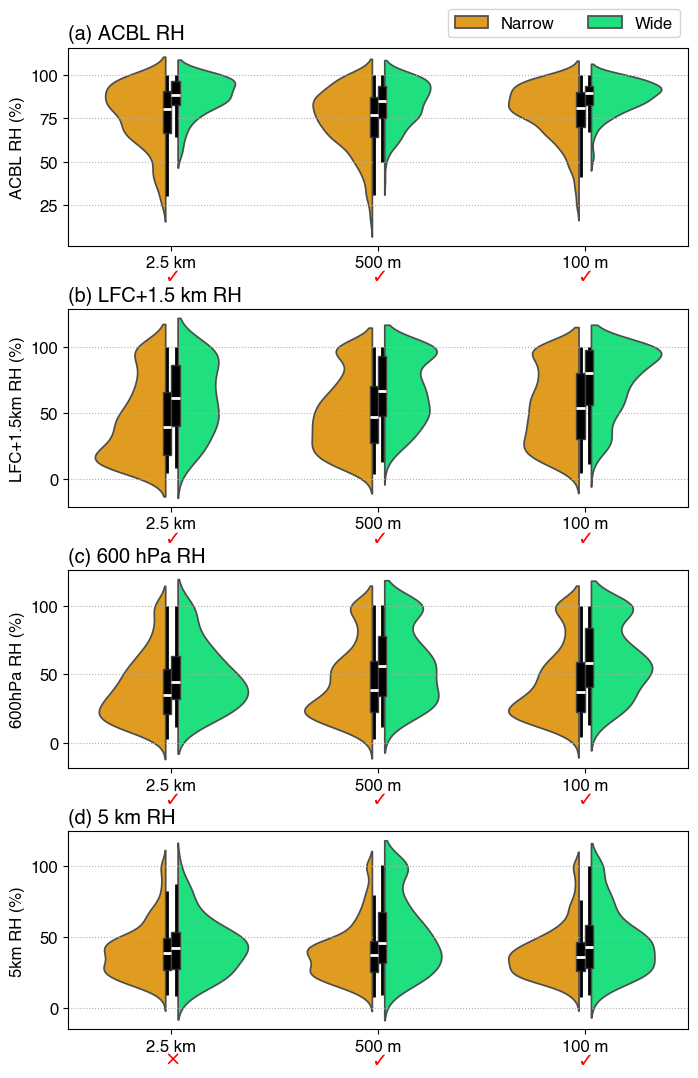

In [124]:
data_arr = [[df_RHacbl], [df_RHlfc1500], [df_RH600mb], [df_RH5km]]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
sigtest = [
    [sig_RHacbl_d2, sig_RHacbl_d3, sig_RHacbl_d4],
    [sig_RHlfc1500_d2, sig_RHlfc1500_d3, sig_RHlfc1500_d4],
    [sig_RH600mb_d2, sig_RH600mb_d3, sig_RH600mb_d4],
    [sig_RH5km_d2, sig_RH5km_d3, sig_RH5km_d4],
]
sig_markersize = 14
x_names = [['WRF']]*nrow
y_names = [['ACBL RH (%)'], ['LFC+1.5km RH (%)'], ['600hPa RH (%)'], ['5km RH (%)']]
hue='Cell Type'
titles = [['(a) ACBL RH'], ['(b) LFC+1.5 km RH'], ['(c) 600 hPa RH'], ['(d) 5 km RH']]

ylabels = None
ylims = None
# ylims = [[(0,80)]*2, [(0,75)]*2, [(0,18)]*2]
xlabels = None
gap = .15
box_width = 0.08
hspace = 0.32
fontsize = 12
figsize = (8, 13)
dpi = 300
figname = f'{figdir}ViolinSplit_NarrowWide_RH_d2_d3_d4.png'
print(figname)
fig = plot_mxn_violin_split(nrow, ncol, data_arr, x_names=x_names, y_names=y_names, hue=hue, sigtest=sigtest, sig_markersize=sig_markersize,
                            hspace=hspace, gap=gap, box_width=box_width,
                            ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

## Moisture content variables

In [125]:
df_PW = make_df(narrow_PW_d2, narrow_PW_d3, narrow_PW_d4, 
               wide_PW_d2, wide_PW_d3, wide_PW_d4, 'PW (cm)')

In [126]:
df_Q850mb = make_df(narrow_Q850mb_d2, narrow_Q850mb_d3, narrow_Q850mb_d4, 
                   wide_Q850mb_d2, wide_Q850mb_d3, wide_Q850mb_d4, '850hPa Qv (g/kg)')

In [127]:
df_Q3km = make_df(narrow_Q3km_d2, narrow_Q3km_d3, narrow_Q3km_d4, 
                   wide_Q3km_d2, wide_Q3km_d3, wide_Q3km_d4, '3km HAMSL Qv (g/kg)')

In [131]:
# Significance level (P value)
alpha = 0.01
# PW
sig_PW_d2 = kstest_data(narrow_PW_d2.data, wide_PW_d2.data, 'Cell PW D2', alpha=alpha)
sig_PW_d3 = kstest_data(narrow_PW_d3.data, wide_PW_d3.data, 'Cell PW D3', alpha=alpha)
sig_PW_d4 = kstest_data(narrow_PW_d4.data, wide_PW_d4.data, 'Cell PW D4', alpha=alpha)
# 850hPa Qv
sig_Q850mb_d2 = kstest_data(narrow_Q850mb_d2.data, wide_Q850mb_d2.data, 'Cell Q850mb D2', alpha=alpha)
sig_Q850mb_d3 = kstest_data(narrow_Q850mb_d3.data, wide_Q850mb_d3.data, 'Cell Q850mb D3', alpha=alpha)
sig_Q850mb_d4 = kstest_data(narrow_Q850mb_d4.data, wide_Q850mb_d4.data, 'Cell Q850mb D4', alpha=alpha)
# 3km Qv
sig_Q3km_d2 = kstest_data(narrow_Q3km_d2.data, wide_Q3km_d2.data, 'Cell Q3km D2', alpha=alpha)
sig_Q3km_d3 = kstest_data(narrow_Q3km_d3.data, wide_Q3km_d3.data, 'Cell Q3km D3', alpha=alpha)
sig_Q3km_d4 = kstest_data(narrow_Q3km_d4.data, wide_Q3km_d4.data, 'Cell Q3km D4', alpha=alpha)

Cell PW D2: Different distributions
Statistics=0.206, p=0.004
Cell PW D3: Same distributions
Statistics=0.073, p=0.316
Cell PW D4: Same distributions
Statistics=0.058, p=0.673
Cell Q850mb D2: Different distributions
Statistics=0.199, p=0.006
Cell Q850mb D3: Different distributions
Statistics=0.136, p=0.004
Cell Q850mb D4: Same distributions
Statistics=0.105, p=0.069
Cell Q3km D2: Different distributions
Statistics=0.199, p=0.006
Cell Q3km D3: Same distributions
Statistics=0.116, p=0.020
Cell Q3km D4: Same distributions
Statistics=0.096, p=0.115


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+2h/ViolinSplit_NarrowWide_PW_Qv_d2_d3_d4.png


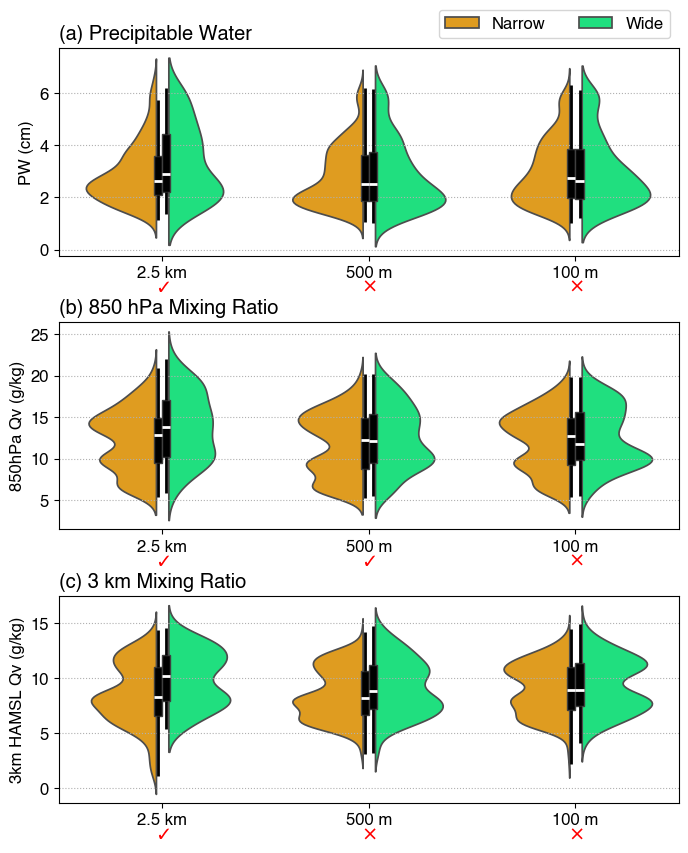

In [132]:
data_arr = [[df_PW], [df_Q850mb], [df_Q3km]]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
sigtest = [
    [sig_PW_d2, sig_PW_d3, sig_PW_d4],
    [sig_Q850mb_d2, sig_Q850mb_d3, sig_Q850mb_d4],
    [sig_Q3km_d2, sig_Q3km_d3, sig_Q3km_d4],
]
sig_markersize = 14
x_names = [['WRF']]*nrow
y_names = [['PW (cm)'], ['850hPa Qv (g/kg)'], ['3km HAMSL Qv (g/kg)']]
hue='Cell Type'
titles = [['(a) Precipitable Water'], ['(b) 850 hPa Mixing Ratio'], ['(c) 3 km Mixing Ratio']]

ylabels = None
ylims = None
# ylims = [[(0,80)]*2, [(0,75)]*2, [(0,18)]*2]
xlabels = None
gap = .15
box_width = 0.08
hspace = 0.32
fontsize = 12
figsize = (8, 10)
dpi = 300
figname = f'{figdir}ViolinSplit_NarrowWide_PW_Qv_d2_d3_d4.png'
print(figname)
fig = plot_mxn_violin_split(nrow, ncol, data_arr, x_names=x_names, y_names=y_names, hue=hue, sigtest=sigtest, sig_markersize=sig_markersize,
                            hspace=hspace, gap=gap, box_width=box_width,
                            ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

## Wind shear variables

In [133]:
df_BWSacbl = make_df(narrow_BWSacbl_d2, narrow_BWSacbl_d3, narrow_BWSacbl_d4, 
                   wide_BWSacbl_d2, wide_BWSacbl_d3, wide_BWSacbl_d4, 'ACBL BWS (m s$^{-1}$)')

In [134]:
df_BWS03km = make_df(narrow_BWS03km_d2, narrow_BWS03km_d3, narrow_BWS03km_d4, 
                   wide_BWS03km_d2, wide_BWS03km_d3, wide_BWS03km_d4, '0-3 km BWS (m s$^{-1}$)')

In [135]:
df_BWS06km = make_df(narrow_BWS06km_d2, narrow_BWS06km_d3, narrow_BWS06km_d4, 
                   wide_BWS06km_d2, wide_BWS06km_d3, wide_BWS06km_d4, '0-6 km BWS (m s$^{-1}$)')

In [159]:
# BWSacbl_d2 = np.hstack((narrow_BWSacbl_d2.values, wide_BWSacbl_d2.values))
# CellType_d2 = np.hstack((np.full(len(narrow_BWSacbl_d2), 'Narrow'), np.full(len(wide_BWSacbl_d2), 'Wide')))

# BWSacbl_d3 = np.hstack((narrow_BWSacbl_d3.values, wide_BWSacbl_d3.values))
# CellType_d3 = np.hstack((np.full(len(narrow_BWSacbl_d3), 'Narrow'), np.full(len(wide_BWSacbl_d3), 'Wide')))

# BWSacbl_d4 = np.hstack((narrow_BWSacbl_d4.values, wide_BWSacbl_d4.values))
# CellType_d4 = np.hstack((np.full(len(narrow_BWSacbl_d4), 'Narrow'), np.full(len(wide_BWSacbl_d4), 'Wide')))

# # Create a DataFrame for each dataset
# df2 = pd.DataFrame({'ACBL BWS (m s$^{-1}$)': BWSacbl_d2, 'Cell Type': CellType_d2, 'WRF': '2.5 km'})
# df3 = pd.DataFrame({'ACBL BWS (m s$^{-1}$)': BWSacbl_d3, 'Cell Type': CellType_d3, 'WRF': '500 m'})
# df4 = pd.DataFrame({'ACBL BWS (m s$^{-1}$)': BWSacbl_d4, 'Cell Type': CellType_d4, 'WRF': '100 m'})

# # Concatenate the DataFrames into one long DataFrame
# df_BWSacbl = pd.concat([df2, df3, df4], ignore_index=True)

In [160]:
# BWS03km_d2 = np.hstack((narrow_BWS03km_d2.values, wide_BWS03km_d2.values))
# CellType_d2 = np.hstack((np.full(len(narrow_BWS03km_d2), 'Narrow'), np.full(len(wide_BWS03km_d2), 'Wide')))

# BWS03km_d3 = np.hstack((narrow_BWS03km_d3.values, wide_BWS03km_d3.values))
# CellType_d3 = np.hstack((np.full(len(narrow_BWS03km_d3), 'Narrow'), np.full(len(wide_BWS03km_d3), 'Wide')))

# BWS03km_d4 = np.hstack((narrow_BWS03km_d4.values, wide_BWS03km_d4.values))
# CellType_d4 = np.hstack((np.full(len(narrow_BWS03km_d4), 'Narrow'), np.full(len(wide_BWS03km_d4), 'Wide')))

# # Create a DataFrame for each dataset
# df2 = pd.DataFrame({'0-3 km BWS (m s$^{-1}$)': BWS03km_d2, 'Cell Type': CellType_d2, 'WRF': '2.5 km'})
# df3 = pd.DataFrame({'0-3 km BWS (m s$^{-1}$)': BWS03km_d3, 'Cell Type': CellType_d3, 'WRF': '500 m'})
# df4 = pd.DataFrame({'0-3 km BWS (m s$^{-1}$)': BWS03km_d4, 'Cell Type': CellType_d4, 'WRF': '100 m'})

# # Concatenate the DataFrames into one long DataFrame
# df_BWS03km = pd.concat([df2, df3, df4], ignore_index=True)

In [161]:
# BWS06km_d2 = np.hstack((narrow_BWS06km_d2.values, wide_BWS06km_d2.values))
# CellType_d2 = np.hstack((np.full(len(narrow_BWS06km_d2), 'Narrow'), np.full(len(wide_BWS06km_d2), 'Wide')))

# BWS06km_d3 = np.hstack((narrow_BWS06km_d3.values, wide_BWS06km_d3.values))
# CellType_d3 = np.hstack((np.full(len(narrow_BWS06km_d3), 'Narrow'), np.full(len(wide_BWS06km_d3), 'Wide')))

# BWS06km_d4 = np.hstack((narrow_BWS06km_d4.values, wide_BWS06km_d4.values))
# CellType_d4 = np.hstack((np.full(len(narrow_BWS06km_d4), 'Narrow'), np.full(len(wide_BWS06km_d4), 'Wide')))

# # Create a DataFrame for each dataset
# df2 = pd.DataFrame({'0-6 km BWS (m s$^{-1}$)': BWS06km_d2, 'Cell Type': CellType_d2, 'WRF': '2.5 km'})
# df3 = pd.DataFrame({'0-6 km BWS (m s$^{-1}$)': BWS06km_d3, 'Cell Type': CellType_d3, 'WRF': '500 m'})
# df4 = pd.DataFrame({'0-6 km BWS (m s$^{-1}$)': BWS06km_d4, 'Cell Type': CellType_d4, 'WRF': '100 m'})

# # Concatenate the DataFrames into one long DataFrame
# df_BWS06km = pd.concat([df2, df3, df4], ignore_index=True)

In [136]:
# Significance level (P value)
alpha = 0.01
# ACBL BWS
sig_BWSacbl_d2 = kstest_data(narrow_BWSacbl_d2.data, wide_BWSacbl_d2.data, 'Cell BWSacbl D2', alpha=alpha)
sig_BWSacbl_d3 = kstest_data(narrow_BWSacbl_d3.data, wide_BWSacbl_d3.data, 'Cell BWSacbl D3', alpha=alpha)
sig_BWSacbl_d4 = kstest_data(narrow_BWSacbl_d4.data, wide_BWSacbl_d4.data, 'Cell BWSacbl D4', alpha=alpha)
# 0-3 km BWS
sig_BWS03km_d2 = kstest_data(narrow_BWS03km_d2.data, wide_BWS03km_d2.data, 'Cell BWS03km D2', alpha=alpha)
sig_BWS03km_d3 = kstest_data(narrow_BWS03km_d3.data, wide_BWS03km_d3.data, 'Cell BWS03km D3', alpha=alpha)
sig_BWS03km_d4 = kstest_data(narrow_BWS03km_d4.data, wide_BWS03km_d4.data, 'Cell BWS03km D4', alpha=alpha)
# 0-6 km BWS
sig_BWS06km_d2 = kstest_data(narrow_BWS06km_d2.data, wide_BWS06km_d2.data, 'Cell BWS06km D2', alpha=alpha)
sig_BWS06km_d3 = kstest_data(narrow_BWS06km_d3.data, wide_BWS06km_d3.data, 'Cell BWS06km D3', alpha=alpha)
sig_BWS06km_d4 = kstest_data(narrow_BWS06km_d4.data, wide_BWS06km_d4.data, 'Cell BWS06km D4', alpha=alpha)

Cell BWSacbl D2: Same distributions
Statistics=0.085, p=0.656
Cell BWSacbl D3: Same distributions
Statistics=0.076, p=0.277
Cell BWSacbl D4: Same distributions
Statistics=0.044, p=0.918
Cell BWS03km D2: Same distributions
Statistics=0.115, p=0.290
Cell BWS03km D3: Different distributions
Statistics=0.132, p=0.005
Cell BWS03km D4: Same distributions
Statistics=0.098, p=0.107
Cell BWS06km D2: Same distributions
Statistics=0.108, p=0.360
Cell BWS06km D3: Different distributions
Statistics=0.133, p=0.005
Cell BWS06km D4: Different distributions
Statistics=0.134, p=0.008


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+2h/ViolinSplit_NarrowWide_BWS_d2_d3_d4.png


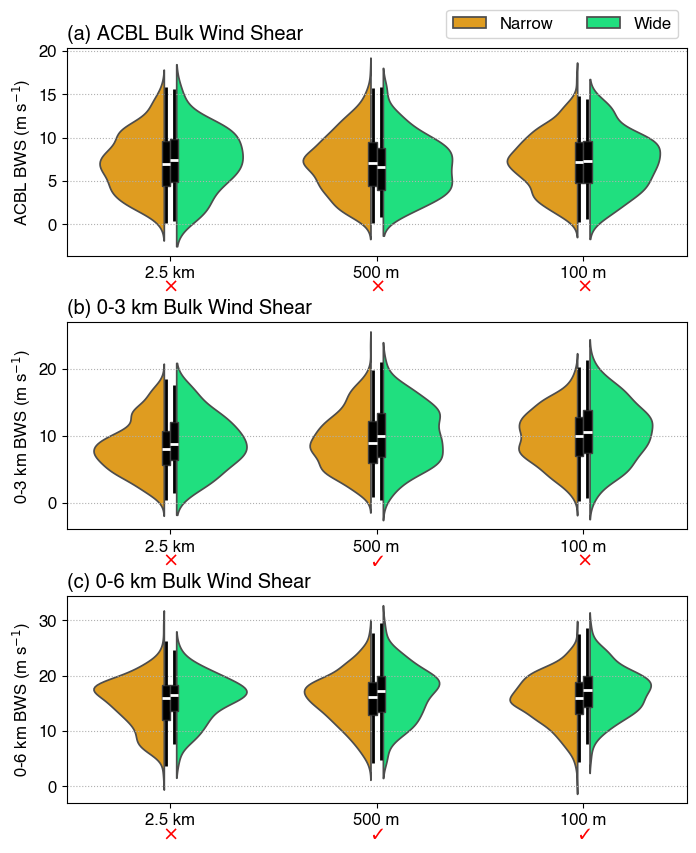

In [137]:
data_arr = [[df_BWSacbl], [df_BWS03km], [df_BWS06km]]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
sigtest = [
    [sig_BWSacbl_d2, sig_BWSacbl_d3, sig_BWSacbl_d4],
    [sig_BWS03km_d2, sig_BWS03km_d3, sig_BWS03km_d4],
    [sig_BWS06km_d2, sig_BWS06km_d3, sig_BWS06km_d4],
]
sig_markersize = 14
x_names = [['WRF']]*nrow
y_names = [['ACBL BWS (m s$^{-1}$)'], ['0-3 km BWS (m s$^{-1}$)'], ['0-6 km BWS (m s$^{-1}$)']]
hue='Cell Type'
titles = [['(a) ACBL Bulk Wind Shear'], ['(b) 0-3 km Bulk Wind Shear'], ['(c) 0-6 km Bulk Wind Shear']]

ylabels = None
ylims = None
# ylims = [[(0,80)]*2, [(0,75)]*2, [(0,18)]*2]
xlabels = None
gap = .15
box_width = 0.08
hspace = 0.32
fontsize = 12
figsize = (8, 10)
dpi = 300
figname = f'{figdir}ViolinSplit_NarrowWide_BWS_d2_d3_d4.png'
print(figname)
fig = plot_mxn_violin_split(nrow, ncol, data_arr, x_names=x_names, y_names=y_names, hue=hue, sigtest=sigtest, sig_markersize=sig_markersize,
                            hspace=hspace, gap=gap, box_width=box_width,
                            ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

In [138]:
figdir

'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+2h/'

## Function to plot nrow x ncol of violin plot

In [69]:
def plot_mxn_violin(nrow, ncol, da, sigtest=None, ypos_sig=None, ylabels=None, ylims=None, titles=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
    palette = list(lcolors.values())    
    lw_kde = 2
    size_avg = 60
    color_avg = 'red'
    color_med = 'white'
    xlabels = list(name_map.values())
    leg_fontsize = None
    # leg_units = 'dBZ'
    
    # bar_labels = list(name_map.values())
    # bar_colors = list(lcolors.values())
       
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col]
            violin_data = da[row][col]
            # Calculate means and medians
            avg2 = np.nanmean(violin_data[0])
            avg3 = np.nanmean(violin_data[1])
            avg4 = np.nanmean(violin_data[2])
            med2 = np.nanmedian(violin_data[0])
            med3 = np.nanmedian(violin_data[1])
            med4 = np.nanmedian(violin_data[2])
            # Violin plot
            vp = sns.violinplot(data=violin_data, ax=ax, palette=palette, linewidth=lw_kde)
            # Plot median value as line
            ax.hlines(med2, -0.1, 0.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med3, 0.9, 1.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med4, 1.9, 2.1, lw=2, color=color_med, zorder=4)
            # Plot mean value as circle
            ax.scatter(0, avg2, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(1, avg3, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(2, avg4, color=color_avg, s=size_avg, zorder=3)
            # Set plots
            ax.set_xticklabels(xlabels)
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':')
            if ylims is not None: ax.set_ylim(ylims[row][col][0], ylims[row][col][1])
            if sigtest is not None:
                ax.text(0.05, ypos_sig[row][col], sigtest[row][col]['d2'], color=color_avg, va='top', fontsize=leg_fontsize)
                ax.text(1.05, ypos_sig[row][col], sigtest[row][col]['d3'], color=color_avg, va='top', fontsize=leg_fontsize)
            # # Legend
            # legend_avg = [mpl.lines.Line2D([0], [0], color=lcolors['d2'], ls='none', label=f'{avg2:.1f}'+f' ({leg_units})'),
            #                 mpl.lines.Line2D([0], [0], color=lcolors['d3'], ls='none', label=f'{avg3:.1f}'+f' ({leg_units})'),
            #                 mpl.lines.Line2D([0], [0], color=lcolors['d4'], ls='none', label=f'{avg4:.1f}'+f' ({leg_units})'),]
            # legend = ax.legend(handles=legend_avg, handlelength=0, handletextpad=0, loc='lower right', fontsize=leg_fontsize, labelcolor='linecolor', ncol=3)
            # ax.add_artist(legend)
            
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


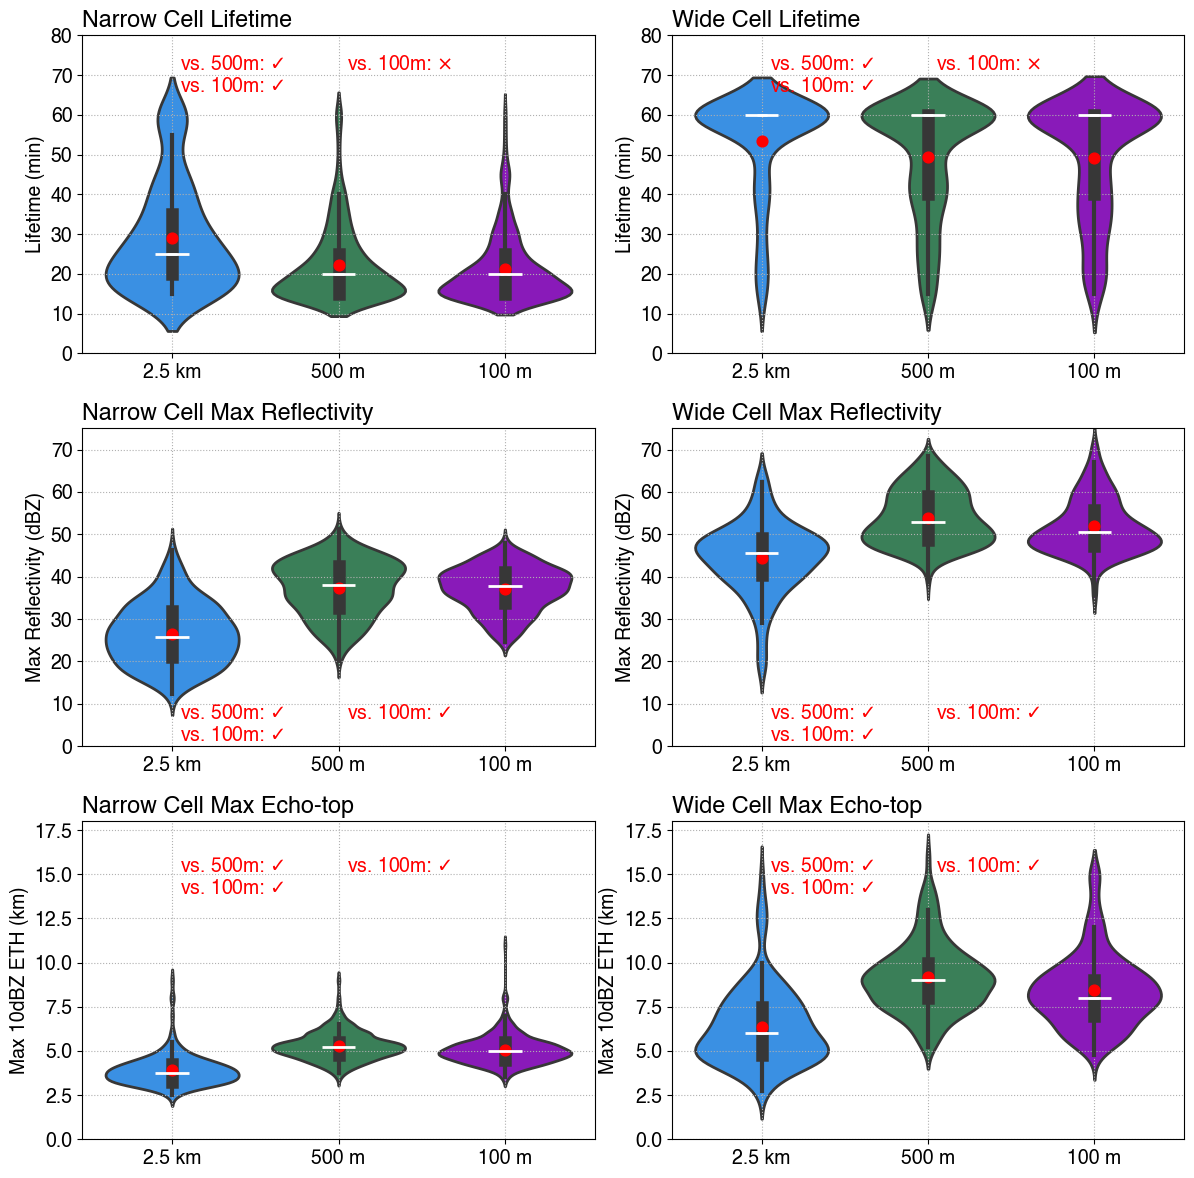

In [74]:
data_arr = [
    [[narrow_track_lifetime_d2.data, narrow_track_lifetime_d3.data, narrow_track_lifetime_d4.data],[wide_track_lifetime_d2.data, wide_track_lifetime_d3.data, wide_track_lifetime_d4.data]],
    [[narrow_maxdbz_d2.data, narrow_maxdbz_d3.data, narrow_maxdbz_d4.data],[wide_maxdbz_d2.data, wide_maxdbz_d3.data, wide_maxdbz_d4.data]],
    [[narrow_maxETH10dbz_d2.data, narrow_maxETH10dbz_d3.data, narrow_maxETH10dbz_d4.data],[wide_maxETH10dbz_d2.data, wide_maxETH10dbz_d3.data, wide_maxETH10dbz_d4.data]],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_lifetime23+'\n'+'vs. 100m: '+narrow_sig_lifetime23, 'd3':'vs. 100m: '+narrow_sig_lifetime34},
     {'d2':'vs. 500m: '+wide_sig_lifetime23+'\n'+'vs. 100m: '+wide_sig_lifetime23, 'd3':'vs. 100m: '+wide_sig_lifetime34},],
    [{'d2':'vs. 500m: '+narrow_sig_maxdbz23+'\n'+'vs. 100m: '+narrow_sig_maxdbz23, 'd3':'vs. 100m: '+narrow_sig_maxdbz34},
     {'d2':'vs. 500m: '+wide_sig_maxdbz23+'\n'+'vs. 100m: '+wide_sig_maxdbz23, 'd3':'vs. 100m: '+wide_sig_maxdbz34},],
    [{'d2':'vs. 500m: '+narrow_sig_maxETH10dbz23+'\n'+'vs. 100m: '+narrow_sig_maxETH10dbz23, 'd3':'vs. 100m: '+narrow_sig_maxETH10dbz34},
     {'d2':'vs. 500m: '+wide_sig_maxETH10dbz23+'\n'+'vs. 100m: '+wide_sig_maxETH10dbz23, 'd3':'vs. 100m: '+wide_sig_maxETH10dbz34},],
]
ypos_sig = [[75]*2, [10]*2, [16]*2]
titles = [['Narrow Cell Lifetime','Wide Cell Lifetime'], ['Narrow Cell Max Reflectivity','Wide Cell Max Reflectivity'], ['Narrow Cell Max Echo-top', 'Wide Cell Max Echo-top']]
ylabels = [['Lifetime (min)']*2, ['Max Reflectivity (dBZ)']*2, ['Max 10dBZ ETH (km)']*2, ]
ylims = [[(0,80)]*2, [(0,75)]*2, [(0,18)]*2]
xlabels = None
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
fontsize = 14
figsize = (12, 12)
figname = f'{figdir}Violin_NarrowWide_Lifetime_maxRefl_maxETH10dBZ_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [75]:
# MU LNB
narrow_sig_pELmu23 = kstest_data(narrow_pELmu_d2.values[~np.isnan(narrow_pELmu_d2)], 
                                     narrow_pELmu_d3.values[~np.isnan(narrow_pELmu_d3)], 'Narrow Cell pELmu D2 vs. D3', alpha=alpha)
narrow_sig_pELmu24 = kstest_data(narrow_pELmu_d2.values[~np.isnan(narrow_pELmu_d2)], 
                                     narrow_pELmu_d4.values[~np.isnan(narrow_pELmu_d4)], 'Narrow Cell pELmu D2 vs. D4', alpha=alpha)
narrow_sig_pELmu34 = kstest_data(narrow_pELmu_d3.values[~np.isnan(narrow_pELmu_d3)], 
                                     narrow_pELmu_d4.values[~np.isnan(narrow_pELmu_d4)], 'Narrow Cell pELmu D3 vs. D4', alpha=alpha)
# MU CAPE
narrow_sig_pCAPEmu23 = kstest_data(narrow_pCAPEmu_d2.values[~np.isnan(narrow_pCAPEmu_d2)], 
                                     narrow_pCAPEmu_d3.values[~np.isnan(narrow_pCAPEmu_d3)], 'Narrow Cell pCAPEmu D2 vs. D3', alpha=alpha)
narrow_sig_pCAPEmu24 = kstest_data(narrow_pCAPEmu_d2.values[~np.isnan(narrow_pCAPEmu_d2)], 
                                     narrow_pCAPEmu_d4.values[~np.isnan(narrow_pCAPEmu_d4)], 'Narrow Cell pCAPEmu D2 vs. D4', alpha=alpha)
narrow_sig_pCAPEmu34 = kstest_data(narrow_pCAPEmu_d3.values[~np.isnan(narrow_pCAPEmu_d3)], 
                                     narrow_pCAPEmu_d4.values[~np.isnan(narrow_pCAPEmu_d4)], 'Narrow Cell pCAPEmu D3 vs. D4', alpha=alpha)
# ACBL CAPE
narrow_sig_pCAPEacbl23 = kstest_data(narrow_pCAPEacbl_d2.values[~np.isnan(narrow_pCAPEacbl_d2)], 
                                     narrow_pCAPEacbl_d3.values[~np.isnan(narrow_pCAPEacbl_d3)], 'Narrow Cell pCAPEacbl D2 vs. D3', alpha=alpha)
narrow_sig_pCAPEacbl24 = kstest_data(narrow_pCAPEacbl_d2.values[~np.isnan(narrow_pCAPEacbl_d2)], 
                                     narrow_pCAPEacbl_d4.values[~np.isnan(narrow_pCAPEacbl_d4)], 'Narrow Cell pCAPEacbl D2 vs. D4', alpha=alpha)
narrow_sig_pCAPEacbl34 = kstest_data(narrow_pCAPEacbl_d3.values[~np.isnan(narrow_pCAPEacbl_d3)], 
                                     narrow_pCAPEacbl_d4.values[~np.isnan(narrow_pCAPEacbl_d4)], 'Narrow Cell pCAPEacbl D3 vs. D4', alpha=alpha)
# MU CIN
narrow_sig_pCINmu23 = kstest_data(narrow_pCINmu_d2.values[~np.isnan(narrow_pCINmu_d2)], 
                                     narrow_pCINmu_d3.values[~np.isnan(narrow_pCINmu_d3)], 'Narrow Cell pCINmu D2 vs. D3', alpha=alpha)
narrow_sig_pCINmu24 = kstest_data(narrow_pCINmu_d2.values[~np.isnan(narrow_pCINmu_d2)], 
                                     narrow_pCINmu_d4.values[~np.isnan(narrow_pCINmu_d4)], 'Narrow Cell pCINmu D2 vs. D4', alpha=alpha)
narrow_sig_pCINmu34 = kstest_data(narrow_pCINmu_d3.values[~np.isnan(narrow_pCINmu_d3)], 
                                     narrow_pCINmu_d4.values[~np.isnan(narrow_pCINmu_d4)], 'Narrow Cell pCINmu D3 vs. D4', alpha=alpha)

# MU LNB
wide_sig_pELmu23 = kstest_data(wide_pELmu_d2.values[~np.isnan(wide_pELmu_d2)], 
                                     wide_pELmu_d3.values[~np.isnan(wide_pELmu_d3)], 'Wide Cell pELmu D2 vs. D3', alpha=alpha)
wide_sig_pELmu24 = kstest_data(wide_pELmu_d2.values[~np.isnan(wide_pELmu_d2)], 
                                     wide_pELmu_d4.values[~np.isnan(wide_pELmu_d4)], 'Wide Cell pELmu D2 vs. D4', alpha=alpha)
wide_sig_pELmu34 = kstest_data(wide_pELmu_d3.values[~np.isnan(wide_pELmu_d3)], 
                                     wide_pELmu_d4.values[~np.isnan(wide_pELmu_d4)], 'Wide Cell pELmu D3 vs. D4', alpha=alpha)
# MU CAPE
wide_sig_pCAPEmu23 = kstest_data(wide_pCAPEmu_d2.values[~np.isnan(wide_pCAPEmu_d2)], 
                                     wide_pCAPEmu_d3.values[~np.isnan(wide_pCAPEmu_d3)], 'Wide Cell pCAPEmu D2 vs. D3', alpha=alpha)
wide_sig_pCAPEmu24 = kstest_data(wide_pCAPEmu_d2.values[~np.isnan(wide_pCAPEmu_d2)], 
                                     wide_pCAPEmu_d4.values[~np.isnan(wide_pCAPEmu_d4)], 'Wide Cell pCAPEmu D2 vs. D4', alpha=alpha)
wide_sig_pCAPEmu34 = kstest_data(wide_pCAPEmu_d3.values[~np.isnan(wide_pCAPEmu_d3)], 
                                     wide_pCAPEmu_d4.values[~np.isnan(wide_pCAPEmu_d4)], 'Wide Cell pCAPEmu D3 vs. D4', alpha=alpha)
# ACBL CAPE
wide_sig_pCAPEacbl23 = kstest_data(wide_pCAPEacbl_d2.values[~np.isnan(wide_pCAPEacbl_d2)], 
                                     wide_pCAPEacbl_d3.values[~np.isnan(wide_pCAPEacbl_d3)], 'Wide Cell pCAPEacbl D2 vs. D3', alpha=alpha)
wide_sig_pCAPEacbl24 = kstest_data(wide_pCAPEacbl_d2.values[~np.isnan(wide_pCAPEacbl_d2)], 
                                     wide_pCAPEacbl_d4.values[~np.isnan(wide_pCAPEacbl_d4)], 'Wide Cell pCAPEacbl D2 vs. D4', alpha=alpha)
wide_sig_pCAPEacbl34 = kstest_data(wide_pCAPEacbl_d3.values[~np.isnan(wide_pCAPEacbl_d3)], 
                                     wide_pCAPEacbl_d4.values[~np.isnan(wide_pCAPEacbl_d4)], 'Wide Cell pCAPEacbl D3 vs. D4', alpha=alpha)
# MU CIN
wide_sig_pCINmu23 = kstest_data(wide_pCINmu_d2.values[~np.isnan(wide_pCINmu_d2)], 
                                     wide_pCINmu_d3.values[~np.isnan(wide_pCINmu_d3)], 'wide Cell pCINmu D2 vs. D3', alpha=alpha)
wide_sig_pCINmu24 = kstest_data(wide_pCINmu_d2.values[~np.isnan(wide_pCINmu_d2)], 
                                     wide_pCINmu_d4.values[~np.isnan(wide_pCINmu_d4)], 'wide Cell pCINmu D2 vs. D4', alpha=alpha)
wide_sig_pCINmu34 = kstest_data(wide_pCINmu_d3.values[~np.isnan(wide_pCINmu_d3)], 
                                     wide_pCINmu_d4.values[~np.isnan(wide_pCINmu_d4)], 'wide Cell pCINmu D3 vs. D4', alpha=alpha)

Narrow Cell pELmu D2 vs. D3: Same distributions
Statistics=0.091, p=0.196
Narrow Cell pELmu D2 vs. D4: Same distributions
Statistics=0.083, p=0.315
Narrow Cell pELmu D3 vs. D4: Same distributions
Statistics=0.091, p=0.060
Narrow Cell pCAPEmu D2 vs. D3: Same distributions
Statistics=0.124, p=0.028
Narrow Cell pCAPEmu D2 vs. D4: Same distributions
Statistics=0.066, p=0.597
Narrow Cell pCAPEmu D3 vs. D4: Different distributions
Statistics=0.132, p=0.001
Narrow Cell pCAPEacbl D2 vs. D3: Same distributions
Statistics=0.097, p=0.141
Narrow Cell pCAPEacbl D2 vs. D4: Different distributions
Statistics=0.166, p=0.001
Narrow Cell pCAPEacbl D3 vs. D4: Different distributions
Statistics=0.117, p=0.006
Narrow Cell pCINmu D2 vs. D3: Different distributions
Statistics=0.261, p=0.000
Narrow Cell pCINmu D2 vs. D4: Different distributions
Statistics=0.158, p=0.003
Narrow Cell pCINmu D3 vs. D4: Same distributions
Statistics=0.107, p=0.016
Wide Cell pELmu D2 vs. D3: Different distributions
Statistics=0.17

/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


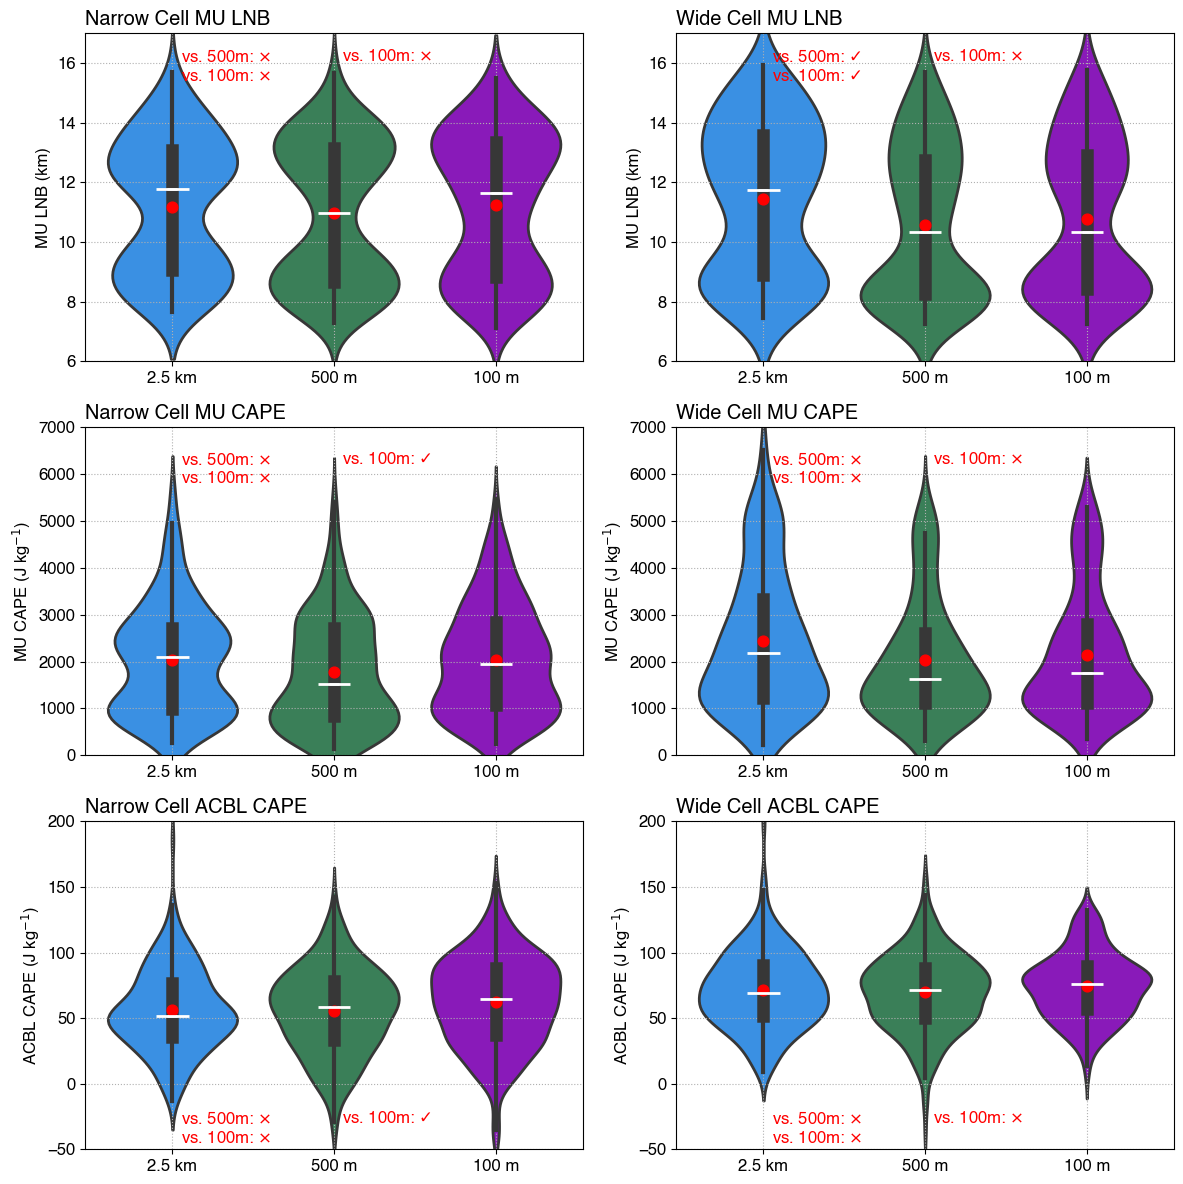

In [78]:
# preCI_t = -3  # preCI time to get a single value

# data_arr = [
#     [[narrow_pELmu_d2.sel(times=preCI_t).values, narrow_pELmu_d3.sel(times=preCI_t).values, narrow_pELmu_d4.sel(times=preCI_t).values],
#      [wide_pELmu_d2.sel(times=preCI_t).values, wide_pELmu_d3.sel(times=preCI_t), wide_pELmu_d4.sel(times=preCI_t).values]],
#     [[narrow_pCAPEmu_d2.sel(times=preCI_t).values, narrow_pCAPEmu_d3.sel(times=preCI_t).values, narrow_pCAPEmu_d4.sel(times=preCI_t).values],
#      [wide_pCAPEmu_d2.sel(times=preCI_t).values, wide_pCAPEmu_d3.sel(times=preCI_t).values, wide_pCAPEmu_d4.sel(times=preCI_t).values]],
#     [[narrow_pCAPEacbl_d2.sel(times=preCI_t).values, narrow_pCAPEacbl_d3.sel(times=preCI_t).values, narrow_pCAPEacbl_d4.sel(times=preCI_t).values],
#      [wide_pCAPEacbl_d2.sel(times=preCI_t).values, wide_pCAPEacbl_d3.sel(times=preCI_t).values, wide_pCAPEacbl_d4.sel(times=preCI_t).values]],
#     # [[narrow_pCINmu_d2.sel(times=preCI_t).values, narrow_pCINmu_d3.sel(times=preCI_t).values, narrow_pCINmu_d4.sel(times=preCI_t).values],
#     #  [wide_pCINmu_d2.sel(times=preCI_t).values, wide_pCINmu_d3.sel(times=preCI_t).values, wide_pCINmu_d4.sel(times=preCI_t).values]],
# ]
data_arr = [
    [[narrow_pELmu_d2.values, narrow_pELmu_d3.values, narrow_pELmu_d4.values],
     [wide_pELmu_d2.values, wide_pELmu_d3, wide_pELmu_d4.values]],
    [[narrow_pCAPEmu_d2.values, narrow_pCAPEmu_d3.values, narrow_pCAPEmu_d4.values],
     [wide_pCAPEmu_d2.values, wide_pCAPEmu_d3.values, wide_pCAPEmu_d4.values]],
    [[narrow_pCAPEacbl_d2.values, narrow_pCAPEacbl_d3.values, narrow_pCAPEacbl_d4.values],
     [wide_pCAPEacbl_d2.values, wide_pCAPEacbl_d3.values, wide_pCAPEacbl_d4.values]],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_pELmu23+'\n'+'vs. 100m: '+narrow_sig_pELmu23, 'd3':'vs. 100m: '+narrow_sig_pELmu34},
     {'d2':'vs. 500m: '+wide_sig_pELmu23+'\n'+'vs. 100m: '+wide_sig_pELmu23, 'd3':'vs. 100m: '+wide_sig_pELmu34},],
    [{'d2':'vs. 500m: '+narrow_sig_pCAPEmu23+'\n'+'vs. 100m: '+narrow_sig_pCAPEmu23, 'd3':'vs. 100m: '+narrow_sig_pCAPEmu34},
     {'d2':'vs. 500m: '+wide_sig_pCAPEmu23+'\n'+'vs. 100m: '+wide_sig_pCAPEmu23, 'd3':'vs. 100m: '+wide_sig_pCAPEmu34},],
    [{'d2':'vs. 500m: '+narrow_sig_pCAPEacbl23+'\n'+'vs. 100m: '+narrow_sig_pCAPEacbl23, 'd3':'vs. 100m: '+narrow_sig_pCAPEacbl34},
     {'d2':'vs. 500m: '+wide_sig_pCAPEacbl23+'\n'+'vs. 100m: '+wide_sig_pCAPEacbl23, 'd3':'vs. 100m: '+wide_sig_pCAPEacbl34},],
]
ypos_sig = [[16.5]*2, [6500]*2, [-20]*2]
titles = [
    ['Narrow Cell MU LNB','Wide Cell MU LNB'], 
    ['Narrow Cell MU CAPE','Wide Cell MU CAPE'], 
    ['Narrow Cell ACBL CAPE', 'Wide Cell ACBL CAPE'],
    # ['Narrow Cell MU CIN', 'Wide Cell MU CIN'],
]
ylabels = [['MU LNB (km)']*2, ['MU CAPE (J kg$^{-1}$)']*2, ['ACBL CAPE (J kg$^{-1}$)']*2]
ylims = [[(6,17)]*2, [(0,7000)]*2, [(-50,200)]*2]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 12
figsize = (12, 12)
figname = f'{figdir}Violin_NarrowWide_pEL_pCAPE_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [79]:
# LCL temperature
narrow_sig_LCLt23 = kstest_data(narrow_LCLt_d2.values[~np.isnan(narrow_LCLt_d2)], 
                                     narrow_LCLt_d3.values[~np.isnan(narrow_LCLt_d3)], 'Narrow Cell LCLt D2 vs. D3', alpha=alpha)
narrow_sig_LCLt24 = kstest_data(narrow_LCLt_d2.values[~np.isnan(narrow_LCLt_d2)], 
                                     narrow_LCLt_d4.values[~np.isnan(narrow_LCLt_d4)], 'Narrow Cell LCLt D2 vs. D4', alpha=alpha)
narrow_sig_LCLt34 = kstest_data(narrow_LCLt_d3.values[~np.isnan(narrow_LCLt_d3)], 
                                     narrow_LCLt_d4.values[~np.isnan(narrow_LCLt_d4)], 'Narrow Cell LCLt D3 vs. D4', alpha=alpha)
# LCL height
narrow_sig_LCLz23 = kstest_data(narrow_LCLz_d2.values[~np.isnan(narrow_LCLz_d2)], 
                                     narrow_LCLz_d3.values[~np.isnan(narrow_LCLz_d3)], 'Narrow Cell LCLz D2 vs. D3', alpha=alpha)
narrow_sig_LCLz24 = kstest_data(narrow_LCLz_d2.values[~np.isnan(narrow_LCLz_d2)], 
                                     narrow_LCLz_d4.values[~np.isnan(narrow_LCLz_d4)], 'Narrow Cell LCLz D2 vs. D4', alpha=alpha)
narrow_sig_LCLz34 = kstest_data(narrow_LCLz_d3.values[~np.isnan(narrow_LCLz_d3)], 
                                     narrow_LCLz_d4.values[~np.isnan(narrow_LCLz_d4)], 'Narrow Cell LCLz D3 vs. D4', alpha=alpha)
# LFC height
narrow_sig_pLFCz23 = kstest_data(narrow_pLFCz_d2.values[~np.isnan(narrow_pLFCz_d2)], 
                                     narrow_pLFCz_d3.values[~np.isnan(narrow_pLFCz_d3)], 'Narrow Cell pLFCz D2 vs. D3', alpha=alpha)
narrow_sig_pLFCz24 = kstest_data(narrow_pLFCz_d2.values[~np.isnan(narrow_pLFCz_d2)], 
                                     narrow_pLFCz_d4.values[~np.isnan(narrow_pLFCz_d4)], 'Narrow Cell pLFCz D2 vs. D4', alpha=alpha)
narrow_sig_pLFCz34 = kstest_data(narrow_pLFCz_d3.values[~np.isnan(narrow_pLFCz_d3)], 
                                     narrow_pLFCz_d4.values[~np.isnan(narrow_pLFCz_d4)], 'Narrow Cell pLFCz D3 vs. D4', alpha=alpha)

# LCL temperature
wide_sig_LCLt23 = kstest_data(wide_LCLt_d2.values[~np.isnan(wide_LCLt_d2)], 
                                     wide_LCLt_d3.values[~np.isnan(wide_LCLt_d3)], 'Wide Cell LCLt D2 vs. D3', alpha=alpha)
wide_sig_LCLt24 = kstest_data(wide_LCLt_d2.values[~np.isnan(wide_LCLt_d2)], 
                                     wide_LCLt_d4.values[~np.isnan(wide_LCLt_d4)], 'Wide Cell LCLt D2 vs. D4', alpha=alpha)
wide_sig_LCLt34 = kstest_data(wide_LCLt_d3.values[~np.isnan(wide_LCLt_d3)], 
                                     wide_LCLt_d4.values[~np.isnan(wide_LCLt_d4)], 'Wide Cell LCLt D3 vs. D4', alpha=alpha)
# LCL height
wide_sig_LCLz23 = kstest_data(wide_LCLz_d2.values[~np.isnan(wide_LCLz_d2)], 
                                     wide_LCLz_d3.values[~np.isnan(wide_LCLz_d3)], 'Wide Cell LCLz D2 vs. D3', alpha=alpha)
wide_sig_LCLz24 = kstest_data(wide_LCLz_d2.values[~np.isnan(wide_LCLz_d2)], 
                                     wide_LCLz_d4.values[~np.isnan(wide_LCLz_d4)], 'Wide Cell LCLz D2 vs. D4', alpha=alpha)
wide_sig_LCLz34 = kstest_data(wide_LCLz_d3.values[~np.isnan(wide_LCLz_d3)], 
                                     wide_LCLz_d4.values[~np.isnan(wide_LCLz_d4)], 'Wide Cell LCLz D3 vs. D4', alpha=alpha)
# LFC height
wide_sig_pLFCz23 = kstest_data(wide_pLFCz_d2.values[~np.isnan(wide_pLFCz_d2)], 
                                     wide_pLFCz_d3.values[~np.isnan(wide_pLFCz_d3)], 'Wide Cell pLFCz D2 vs. D3', alpha=alpha)
wide_sig_pLFCz24 = kstest_data(wide_pLFCz_d2.values[~np.isnan(wide_pLFCz_d2)], 
                                     wide_pLFCz_d4.values[~np.isnan(wide_pLFCz_d4)], 'Wide Cell pLFCz D2 vs. D4', alpha=alpha)
wide_sig_pLFCz34 = kstest_data(wide_pLFCz_d3.values[~np.isnan(wide_pLFCz_d3)], 
                                     wide_pLFCz_d4.values[~np.isnan(wide_pLFCz_d4)], 'Wide Cell pLFCz D3 vs. D4', alpha=alpha)

Narrow Cell LCLt D2 vs. D3: Same distributions
Statistics=0.119, p=0.039
Narrow Cell LCLt D2 vs. D4: Same distributions
Statistics=0.065, p=0.603
Narrow Cell LCLt D3 vs. D4: Same distributions
Statistics=0.100, p=0.027
Narrow Cell LCLz D2 vs. D3: Same distributions
Statistics=0.115, p=0.051
Narrow Cell LCLz D2 vs. D4: Same distributions
Statistics=0.065, p=0.611
Narrow Cell LCLz D3 vs. D4: Same distributions
Statistics=0.088, p=0.071
Narrow Cell pLFCz D2 vs. D3: Same distributions
Statistics=0.127, p=0.022
Narrow Cell pLFCz D2 vs. D4: Same distributions
Statistics=0.060, p=0.712
Narrow Cell pLFCz D3 vs. D4: Same distributions
Statistics=0.095, p=0.043
Wide Cell LCLt D2 vs. D3: Different distributions
Statistics=0.183, p=0.002
Wide Cell LCLt D2 vs. D4: Same distributions
Statistics=0.134, p=0.056
Wide Cell LCLt D3 vs. D4: Same distributions
Statistics=0.074, p=0.442
Wide Cell LCLz D2 vs. D3: Same distributions
Statistics=0.049, p=0.948
Wide Cell LCLz D2 vs. D4: Same distributions
Statis

/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


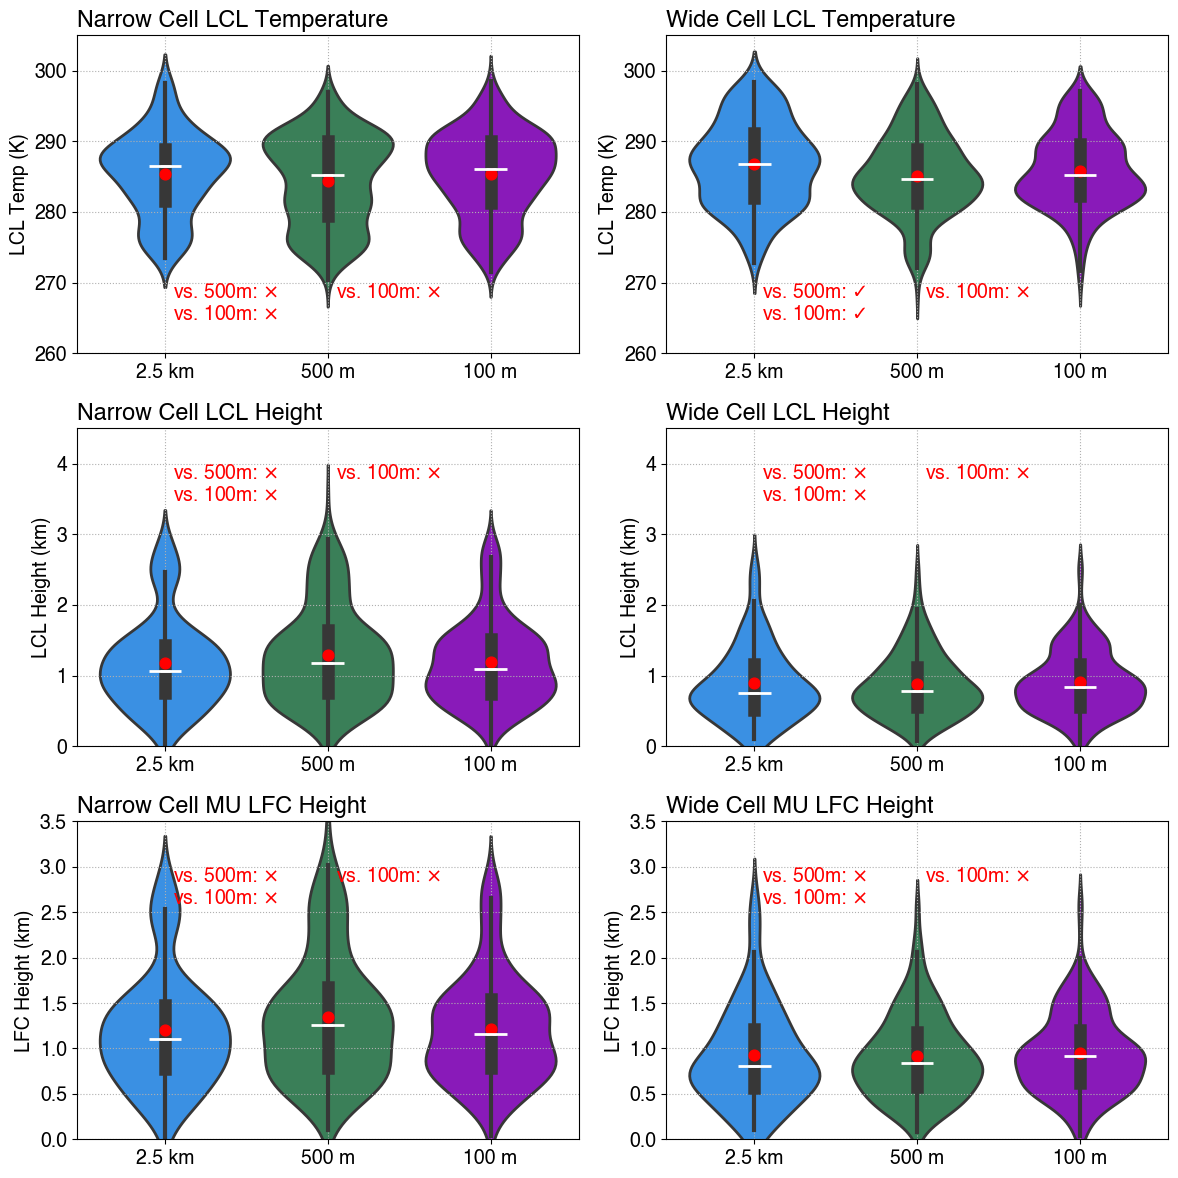

In [85]:
data_arr = [
    [[narrow_LCLt_d2.values, narrow_LCLt_d3.values, narrow_LCLt_d4.values],
     [wide_LCLt_d2.values, wide_LCLt_d3.values, wide_LCLt_d4.values]],
    [[narrow_LCLz_d2.values, narrow_LCLz_d3.values, narrow_LCLz_d4.values],
     [wide_LCLz_d2.values, wide_LCLz_d3.values, wide_LCLz_d4.values]],
    [[narrow_pLFCz_d2.values, narrow_pLFCz_d3.values, narrow_pLFCz_d4.values],
     [wide_pLFCz_d2.values, wide_pLFCz_d3.values, wide_pLFCz_d4.values]],
]
titles = [
    ['Narrow Cell LCL Temperature','Wide Cell LCL Temperature'], 
    ['Narrow Cell LCL Height','Wide Cell LCL Height'], 
    ['Narrow Cell MU LFC Height', 'Wide Cell MU LFC Height'],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_LCLt23+'\n'+'vs. 100m: '+narrow_sig_LCLt23, 'd3':'vs. 100m: '+narrow_sig_LCLt34},
     {'d2':'vs. 500m: '+wide_sig_LCLt23+'\n'+'vs. 100m: '+wide_sig_LCLt23, 'd3':'vs. 100m: '+wide_sig_LCLt34},],
    [{'d2':'vs. 500m: '+narrow_sig_LCLz23+'\n'+'vs. 100m: '+narrow_sig_LCLz23, 'd3':'vs. 100m: '+narrow_sig_LCLz34},
     {'d2':'vs. 500m: '+wide_sig_LCLz23+'\n'+'vs. 100m: '+wide_sig_LCLz23, 'd3':'vs. 100m: '+wide_sig_LCLz34},],
    [{'d2':'vs. 500m: '+narrow_sig_pLFCz23+'\n'+'vs. 100m: '+narrow_sig_pLFCz23, 'd3':'vs. 100m: '+narrow_sig_pLFCz34},
     {'d2':'vs. 500m: '+wide_sig_pLFCz23+'\n'+'vs. 100m: '+wide_sig_pLFCz23, 'd3':'vs. 100m: '+wide_sig_pLFCz34},],
]
ypos_sig = [[270]*2, [4]*2, [3]*2]
ylabels = [['LCL Temp (K)']*2, ['LCL Height (km)']*2, ['LFC Height (km)']*2, ]
ylims = [[(260,305)]*2, [(0,4.5)]*2, [(0,3.5)]*2]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 14
figsize = (12, 12)
figname = f'{figdir}Violin_NarrowWide_LCL_pLFC_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [102]:
# # Qv at a height
# wide_sig_Q850mb23 = kstest_data(wide_Q850mb_d2.values[~np.isnan(wide_Q850mb_d2)], 
#                                      wide_Q850mb_d3.values[~np.isnan(wide_Q850mb_d3)], 'wide Cell Q850mb D2 vs. D3', alpha=alpha)
# wide_sig_Q850mb24 = kstest_data(wide_Q850mb_d2.values[~np.isnan(wide_Q850mb_d2)], 
#                                      wide_Q850mb_d4.values[~np.isnan(wide_Q850mb_d4)], 'wide Cell Q850mb D2 vs. D4', alpha=alpha)
# wide_sig_Q850mb34 = kstest_data(wide_Q850mb_d3.values[~np.isnan(wide_Q850mb_d3)], 
#                                      wide_Q850mb_d4.values[~np.isnan(wide_Q850mb_d4)], 'wide Cell Q850mb D3 vs. D4', alpha=alpha)

# wide_sig_Q3km23 = kstest_data(wide_Q3km_d2.values[~np.isnan(wide_Q3km_d2)], 
#                                      wide_Q3km_d3.values[~np.isnan(wide_Q3km_d3)], 'wide Cell Q3km D2 vs. D3', alpha=alpha)
# wide_sig_Q3km24 = kstest_data(wide_Q3km_d2.values[~np.isnan(wide_Q3km_d2)], 
#                                      wide_Q3km_d4.values[~np.isnan(wide_Q3km_d4)], 'wide Cell Q3km D2 vs. D4', alpha=alpha)
# wide_sig_Q3km34 = kstest_data(wide_Q3km_d3.values[~np.isnan(wide_Q3km_d3)], 
#                                      wide_Q3km_d4.values[~np.isnan(wide_Q3km_d4)], 'wide Cell Q3km D3 vs. D4', alpha=alpha)

In [104]:
# ACBL RH
narrow_sig_RHacbl23 = kstest_data(narrow_RHacbl_d2.values[~np.isnan(narrow_RHacbl_d2)], 
                                     narrow_RHacbl_d3.values[~np.isnan(narrow_RHacbl_d3)], 'Narrow Cell RHacbl D2 vs. D3', alpha=alpha)
narrow_sig_RHacbl24 = kstest_data(narrow_RHacbl_d2.values[~np.isnan(narrow_RHacbl_d2)], 
                                     narrow_RHacbl_d4.values[~np.isnan(narrow_RHacbl_d4)], 'Narrow Cell RHacbl D2 vs. D4', alpha=alpha)
narrow_sig_RHacbl34 = kstest_data(narrow_RHacbl_d3.values[~np.isnan(narrow_RHacbl_d3)], 
                                     narrow_RHacbl_d4.values[~np.isnan(narrow_RHacbl_d4)], 'Narrow Cell RHacbl D3 vs. D4', alpha=alpha)
# LFC to LFC+1500m RH
narrow_sig_RHlfc150023 = kstest_data(narrow_RHlfc1500_d2.values[~np.isnan(narrow_RHlfc1500_d2)], 
                                     narrow_RHlfc1500_d3.values[~np.isnan(narrow_RHlfc1500_d3)], 'Narrow Cell RHlfc1500 D2 vs. D3', alpha=alpha)
narrow_sig_RHlfc150024 = kstest_data(narrow_RHlfc1500_d2.values[~np.isnan(narrow_RHlfc1500_d2)], 
                                     narrow_RHlfc1500_d4.values[~np.isnan(narrow_RHlfc1500_d4)], 'Narrow Cell RHlfc1500 D2 vs. D4', alpha=alpha)
narrow_sig_RHlfc150034 = kstest_data(narrow_RHlfc1500_d3.values[~np.isnan(narrow_RHlfc1500_d3)], 
                                     narrow_RHlfc1500_d4.values[~np.isnan(narrow_RHlfc1500_d4)], 'Narrow Cell RHlfc1500 D3 vs. D4', alpha=alpha)
# RH at a height
narrow_sig_RH5km23 = kstest_data(narrow_RH5km_d2.values[~np.isnan(narrow_RH5km_d2)], 
                                     narrow_RH5km_d3.values[~np.isnan(narrow_RH5km_d3)], 'Narrow Cell RH5km D2 vs. D3', alpha=alpha)
narrow_sig_RH5km24 = kstest_data(narrow_RH5km_d2.values[~np.isnan(narrow_RH5km_d2)], 
                                     narrow_RH5km_d4.values[~np.isnan(narrow_RH5km_d4)], 'Narrow Cell RH5km D2 vs. D4', alpha=alpha)
narrow_sig_RH5km34 = kstest_data(narrow_RH5km_d3.values[~np.isnan(narrow_RH5km_d3)], 
                                     narrow_RH5km_d4.values[~np.isnan(narrow_RH5km_d4)], 'Narrow Cell RH5km D3 vs. D4', alpha=alpha)

narrow_sig_RH600mb23 = kstest_data(narrow_RH600mb_d2.values[~np.isnan(narrow_RH600mb_d2)], 
                                     narrow_RH600mb_d3.values[~np.isnan(narrow_RH600mb_d3)], 'Narrow Cell RH600mb D2 vs. D3', alpha=alpha)
narrow_sig_RH600mb24 = kstest_data(narrow_RH600mb_d2.values[~np.isnan(narrow_RH600mb_d2)], 
                                     narrow_RH600mb_d4.values[~np.isnan(narrow_RH600mb_d4)], 'Narrow Cell RH600mb D2 vs. D4', alpha=alpha)
narrow_sig_RH600mb34 = kstest_data(narrow_RH600mb_d3.values[~np.isnan(narrow_RH600mb_d3)], 
                                     narrow_RH600mb_d4.values[~np.isnan(narrow_RH600mb_d4)], 'Narrow Cell RH600mb D3 vs. D4', alpha=alpha)

narrow_sig_RH500mb23 = kstest_data(narrow_RH500mb_d2.values[~np.isnan(narrow_RH500mb_d2)], 
                                     narrow_RH500mb_d3.values[~np.isnan(narrow_RH500mb_d3)], 'Narrow Cell RH500mb D2 vs. D3', alpha=alpha)
narrow_sig_RH500mb24 = kstest_data(narrow_RH500mb_d2.values[~np.isnan(narrow_RH500mb_d2)], 
                                     narrow_RH500mb_d4.values[~np.isnan(narrow_RH500mb_d4)], 'Narrow Cell RH500mb D2 vs. D4', alpha=alpha)
narrow_sig_RH500mb34 = kstest_data(narrow_RH500mb_d3.values[~np.isnan(narrow_RH500mb_d3)], 
                                     narrow_RH500mb_d4.values[~np.isnan(narrow_RH500mb_d4)], 'Narrow Cell RH500mb D3 vs. D4', alpha=alpha)
# PW
narrow_sig_PW23 = kstest_data(narrow_PW_d2.values[~np.isnan(narrow_PW_d2)], 
                                     narrow_PW_d3.values[~np.isnan(narrow_PW_d3)], 'narrow Cell PW D2 vs. D3', alpha=alpha)
narrow_sig_PW24 = kstest_data(narrow_PW_d2.values[~np.isnan(narrow_PW_d2)], 
                                     narrow_PW_d4.values[~np.isnan(narrow_PW_d4)], 'narrow Cell PW D2 vs. D4', alpha=alpha)
narrow_sig_PW34 = kstest_data(narrow_PW_d3.values[~np.isnan(narrow_PW_d3)], 
                                     narrow_PW_d4.values[~np.isnan(narrow_PW_d4)], 'narrow Cell PW D3 vs. D4', alpha=alpha)
# Qv at a height
narrow_sig_Q850mb23 = kstest_data(narrow_Q850mb_d2.values[~np.isnan(narrow_Q850mb_d2)], 
                                     narrow_Q850mb_d3.values[~np.isnan(narrow_Q850mb_d3)], 'narrow Cell Q850mb D2 vs. D3', alpha=alpha)
narrow_sig_Q850mb24 = kstest_data(narrow_Q850mb_d2.values[~np.isnan(narrow_Q850mb_d2)], 
                                     narrow_Q850mb_d4.values[~np.isnan(narrow_Q850mb_d4)], 'narrow Cell Q850mb D2 vs. D4', alpha=alpha)
narrow_sig_Q850mb34 = kstest_data(narrow_Q850mb_d3.values[~np.isnan(narrow_Q850mb_d3)], 
                                     narrow_Q850mb_d4.values[~np.isnan(narrow_Q850mb_d4)], 'narrow Cell Q850mb D3 vs. D4', alpha=alpha)

narrow_sig_Q3km23 = kstest_data(narrow_Q3km_d2.values[~np.isnan(narrow_Q3km_d2)], 
                                     narrow_Q3km_d3.values[~np.isnan(narrow_Q3km_d3)], 'narrow Cell Q3km D2 vs. D3', alpha=alpha)
narrow_sig_Q3km24 = kstest_data(narrow_Q3km_d2.values[~np.isnan(narrow_Q3km_d2)], 
                                     narrow_Q3km_d4.values[~np.isnan(narrow_Q3km_d4)], 'narrow Cell Q3km D2 vs. D4', alpha=alpha)
narrow_sig_Q3km34 = kstest_data(narrow_Q3km_d3.values[~np.isnan(narrow_Q3km_d3)], 
                                     narrow_Q3km_d4.values[~np.isnan(narrow_Q3km_d4)], 'narrow Cell Q3km D3 vs. D4', alpha=alpha)

# ACBL RH
wide_sig_RHacbl23 = kstest_data(wide_RHacbl_d2.values[~np.isnan(wide_RHacbl_d2)], 
                                     wide_RHacbl_d3.values[~np.isnan(wide_RHacbl_d3)], 'Wide Cell RHacbl D2 vs. D3', alpha=alpha)
wide_sig_RHacbl24 = kstest_data(wide_RHacbl_d2.values[~np.isnan(wide_RHacbl_d2)], 
                                     wide_RHacbl_d4.values[~np.isnan(wide_RHacbl_d4)], 'Wide Cell RHacbl D2 vs. D4', alpha=alpha)
wide_sig_RHacbl34 = kstest_data(wide_RHacbl_d3.values[~np.isnan(wide_RHacbl_d3)], 
                                     wide_RHacbl_d4.values[~np.isnan(wide_RHacbl_d4)], 'Wide Cell RHacbl D3 vs. D4', alpha=alpha)
# LFC to LFC+1500m RH
wide_sig_RHlfc150023 = kstest_data(wide_RHlfc1500_d2.values[~np.isnan(wide_RHlfc1500_d2)], 
                                     wide_RHlfc1500_d3.values[~np.isnan(wide_RHlfc1500_d3)], 'Wide Cell RHlfc1500 D2 vs. D3', alpha=alpha)
wide_sig_RHlfc150024 = kstest_data(wide_RHlfc1500_d2.values[~np.isnan(wide_RHlfc1500_d2)], 
                                     wide_RHlfc1500_d4.values[~np.isnan(wide_RHlfc1500_d4)], 'Wide Cell RHlfc1500 D2 vs. D4', alpha=alpha)
wide_sig_RHlfc150034 = kstest_data(wide_RHlfc1500_d3.values[~np.isnan(wide_RHlfc1500_d3)], 
                                     wide_RHlfc1500_d4.values[~np.isnan(wide_RHlfc1500_d4)], 'Wide Cell RHlfc1500 D3 vs. D4', alpha=alpha)
# RH at a height
wide_sig_RH5km23 = kstest_data(wide_RH5km_d2.values[~np.isnan(wide_RH5km_d2)], 
                                     wide_RH5km_d3.values[~np.isnan(wide_RH5km_d3)], 'wide Cell RH5km D2 vs. D3', alpha=alpha)
wide_sig_RH5km24 = kstest_data(wide_RH5km_d2.values[~np.isnan(wide_RH5km_d2)], 
                                     wide_RH5km_d4.values[~np.isnan(wide_RH5km_d4)], 'wide Cell RH5km D2 vs. D4', alpha=alpha)
wide_sig_RH5km34 = kstest_data(wide_RH5km_d3.values[~np.isnan(wide_RH5km_d3)], 
                                     wide_RH5km_d4.values[~np.isnan(wide_RH5km_d4)], 'wide Cell RH5km D3 vs. D4', alpha=alpha)

wide_sig_RH600mb23 = kstest_data(wide_RH600mb_d2.values[~np.isnan(wide_RH600mb_d2)], 
                                     wide_RH600mb_d3.values[~np.isnan(wide_RH600mb_d3)], 'Wide Cell RH600mb D2 vs. D3', alpha=alpha)
wide_sig_RH600mb24 = kstest_data(wide_RH600mb_d2.values[~np.isnan(wide_RH600mb_d2)], 
                                     wide_RH600mb_d4.values[~np.isnan(wide_RH600mb_d4)], 'Wide Cell RH600mb D2 vs. D4', alpha=alpha)
wide_sig_RH600mb34 = kstest_data(wide_RH600mb_d3.values[~np.isnan(wide_RH600mb_d3)], 
                                     wide_RH600mb_d4.values[~np.isnan(wide_RH600mb_d4)], 'Wide Cell RH600mb D3 vs. D4', alpha=alpha)

wide_sig_RH500mb23 = kstest_data(wide_RH500mb_d2.values[~np.isnan(wide_RH500mb_d2)], 
                                     wide_RH500mb_d3.values[~np.isnan(wide_RH500mb_d3)], 'wide Cell RH500mb D2 vs. D3', alpha=alpha)
wide_sig_RH500mb24 = kstest_data(wide_RH500mb_d2.values[~np.isnan(wide_RH500mb_d2)], 
                                     wide_RH500mb_d4.values[~np.isnan(wide_RH500mb_d4)], 'wide Cell RH500mb D2 vs. D4', alpha=alpha)
wide_sig_RH500mb34 = kstest_data(wide_RH500mb_d3.values[~np.isnan(wide_RH500mb_d3)], 
                                     wide_RH500mb_d4.values[~np.isnan(wide_RH500mb_d4)], 'wide Cell RH500mb D3 vs. D4', alpha=alpha)
# PW
wide_sig_PW23 = kstest_data(wide_PW_d2.values[~np.isnan(wide_PW_d2)], 
                                     wide_PW_d3.values[~np.isnan(wide_PW_d3)], 'wide Cell PW D2 vs. D3', alpha=alpha)
wide_sig_PW24 = kstest_data(wide_PW_d2.values[~np.isnan(wide_PW_d2)], 
                                     wide_PW_d4.values[~np.isnan(wide_PW_d4)], 'wide Cell PW D2 vs. D4', alpha=alpha)
wide_sig_PW34 = kstest_data(wide_PW_d3.values[~np.isnan(wide_PW_d3)], 
                                     wide_PW_d4.values[~np.isnan(wide_PW_d4)], 'wide Cell PW D3 vs. D4', alpha=alpha)
# Qv at a height
wide_sig_Q850mb23 = kstest_data(wide_Q850mb_d2.values[~np.isnan(wide_Q850mb_d2)], 
                                     wide_Q850mb_d3.values[~np.isnan(wide_Q850mb_d3)], 'wide Cell Q850mb D2 vs. D3', alpha=alpha)
wide_sig_Q850mb24 = kstest_data(wide_Q850mb_d2.values[~np.isnan(wide_Q850mb_d2)], 
                                     wide_Q850mb_d4.values[~np.isnan(wide_Q850mb_d4)], 'wide Cell Q850mb D2 vs. D4', alpha=alpha)
wide_sig_Q850mb34 = kstest_data(wide_Q850mb_d3.values[~np.isnan(wide_Q850mb_d3)], 
                                     wide_Q850mb_d4.values[~np.isnan(wide_Q850mb_d4)], 'wide Cell Q850mb D3 vs. D4', alpha=alpha)

wide_sig_Q3km23 = kstest_data(wide_Q3km_d2.values[~np.isnan(wide_Q3km_d2)], 
                                     wide_Q3km_d3.values[~np.isnan(wide_Q3km_d3)], 'wide Cell Q3km D2 vs. D3', alpha=alpha)
wide_sig_Q3km24 = kstest_data(wide_Q3km_d2.values[~np.isnan(wide_Q3km_d2)], 
                                     wide_Q3km_d4.values[~np.isnan(wide_Q3km_d4)], 'wide Cell Q3km D2 vs. D4', alpha=alpha)
wide_sig_Q3km34 = kstest_data(wide_Q3km_d3.values[~np.isnan(wide_Q3km_d3)], 
                                     wide_Q3km_d4.values[~np.isnan(wide_Q3km_d4)], 'wide Cell Q3km D3 vs. D4', alpha=alpha)

Narrow Cell RHacbl D2 vs. D3: Same distributions
Statistics=0.107, p=0.081
Narrow Cell RHacbl D2 vs. D4: Same distributions
Statistics=0.114, p=0.060
Narrow Cell RHacbl D3 vs. D4: Different distributions
Statistics=0.173, p=0.000
Narrow Cell RHlfc1500 D2 vs. D3: Different distributions
Statistics=0.214, p=0.000
Narrow Cell RHlfc1500 D2 vs. D4: Different distributions
Statistics=0.241, p=0.000
Narrow Cell RHlfc1500 D3 vs. D4: Same distributions
Statistics=0.061, p=0.393
Narrow Cell RH5km D2 vs. D3: Same distributions
Statistics=0.064, p=0.602
Narrow Cell RH5km D2 vs. D4: Same distributions
Statistics=0.114, p=0.061
Narrow Cell RH5km D3 vs. D4: Same distributions
Statistics=0.094, p=0.045
Narrow Cell RH600mb D2 vs. D3: Same distributions
Statistics=0.119, p=0.039
Narrow Cell RH600mb D2 vs. D4: Same distributions
Statistics=0.101, p=0.132
Narrow Cell RH600mb D3 vs. D4: Same distributions
Statistics=0.067, p=0.289
Narrow Cell RH500mb D2 vs. D3: Same distributions
Statistics=0.082, p=0.302


/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xtickl

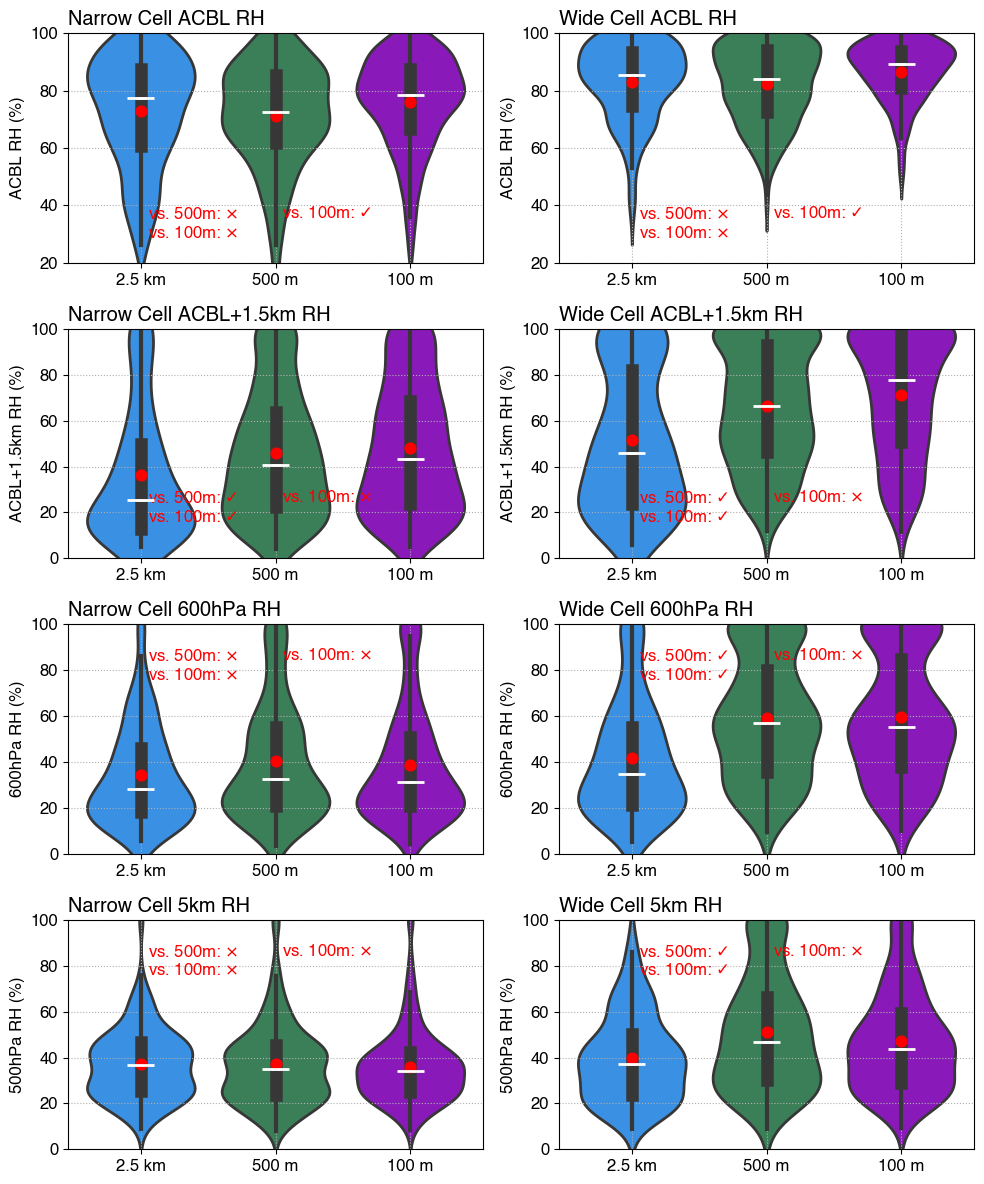

In [106]:
data_arr = [
    [[narrow_RHacbl_d2.values, narrow_RHacbl_d3.values, narrow_RHacbl_d4.values],
     [wide_RHacbl_d2.values, wide_RHacbl_d3.values, wide_RHacbl_d4.values]],
    [[narrow_RHlfc1500_d2.values, narrow_RHlfc1500_d3.values, narrow_RHlfc1500_d4.values],
     [wide_RHlfc1500_d2.values, wide_RHlfc1500_d3.values, wide_RHlfc1500_d4.values]],
    [[narrow_RH600mb_d2.values, narrow_RH600mb_d3.values, narrow_RH600mb_d4.values],
     [wide_RH600mb_d2.values, wide_RH600mb_d3.values, wide_RH600mb_d4.values]],
    # [[narrow_RH500mb_d2.values, narrow_RH500mb_d3.values, narrow_RH500mb_d4.values],
    #  [wide_RH500mb_d2.values, wide_RH500mb_d3.values, wide_RH500mb_d4.values]],
    [[narrow_RH5km_d2.values, narrow_RH5km_d3.values, narrow_RH5km_d4.values],
     [wide_RH5km_d2.values, wide_RH5km_d3.values, wide_RH5km_d4.values]],
    # [[narrow_PW_d2.values, narrow_PW_d3.values, narrow_PW_d4.values],
    #  [wide_PW_d2.values, wide_PW_d3.values, wide_PW_d4.values]],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_RHacbl23+'\n'+'vs. 100m: '+narrow_sig_RHacbl23, 'd3':'vs. 100m: '+narrow_sig_RHacbl34},
     {'d2':'vs. 500m: '+wide_sig_RHacbl23+'\n'+'vs. 100m: '+wide_sig_RHacbl23, 'd3':'vs. 100m: '+wide_sig_RHacbl34},],
    [{'d2':'vs. 500m: '+narrow_sig_RHlfc150023+'\n'+'vs. 100m: '+narrow_sig_RHlfc150023, 'd3':'vs. 100m: '+narrow_sig_RHlfc150034},
     {'d2':'vs. 500m: '+wide_sig_RHlfc150023+'\n'+'vs. 100m: '+wide_sig_RHlfc150023, 'd3':'vs. 100m: '+wide_sig_RHlfc150034},],
    [{'d2':'vs. 500m: '+narrow_sig_RH600mb23+'\n'+'vs. 100m: '+narrow_sig_RH600mb23, 'd3':'vs. 100m: '+narrow_sig_RH600mb34},
     {'d2':'vs. 500m: '+wide_sig_RH600mb23+'\n'+'vs. 100m: '+wide_sig_RH600mb23, 'd3':'vs. 100m: '+wide_sig_RH600mb34},],
    [{'d2':'vs. 500m: '+narrow_sig_RH5km23+'\n'+'vs. 100m: '+narrow_sig_RH5km23, 'd3':'vs. 100m: '+narrow_sig_RH5km34},
     {'d2':'vs. 500m: '+wide_sig_RH5km23+'\n'+'vs. 100m: '+wide_sig_RH5km23, 'd3':'vs. 100m: '+wide_sig_RH5km34},],
    # [{'d2':'vs. 500m: '+narrow_sig_PW23+'\n'+'vs. 100m: '+narrow_sig_PW23, 'd3':'vs. 100m: '+narrow_sig_PW34},
    #  {'d2':'vs. 500m: '+wide_sig_PW23+'\n'+'vs. 100m: '+wide_sig_PW23, 'd3':'vs. 100m: '+wide_sig_PW34},],
]
ypos_sig = [[40]*2, [30]*2, [90]*2, [90]*2, [6.5]*2]
titles = [
    ['Narrow Cell ACBL RH','Wide Cell ACBL RH'], 
    ['Narrow Cell ACBL+1.5km RH','Wide Cell ACBL+1.5km RH'], 
    ['Narrow Cell 600hPa RH','Wide Cell 600hPa RH'], 
    ['Narrow Cell 5km RH', 'Wide Cell 5km RH'],
    # ['Narrow Cell Precipitable Water', 'Wide Cell Precipitable Water'],
]
ylabels = [['ACBL RH (%)']*2, ['ACBL+1.5km RH (%)']*2, ['600hPa RH (%)']*2, ['5km RH (%)']*2, ['PW (cm)']*2]
ylims = [[(20,100)]*2, [(0,100)]*2, [(0,100)]*2, [(0,100)]*2, [(0,7)]*2]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 12
figsize = (10, 12)
# figname = f'{figdir}Violin_NarrowWide_RH_PW_d2_d3_d4.png'
figname = f'{figdir}Violin_NarrowWide_RH_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


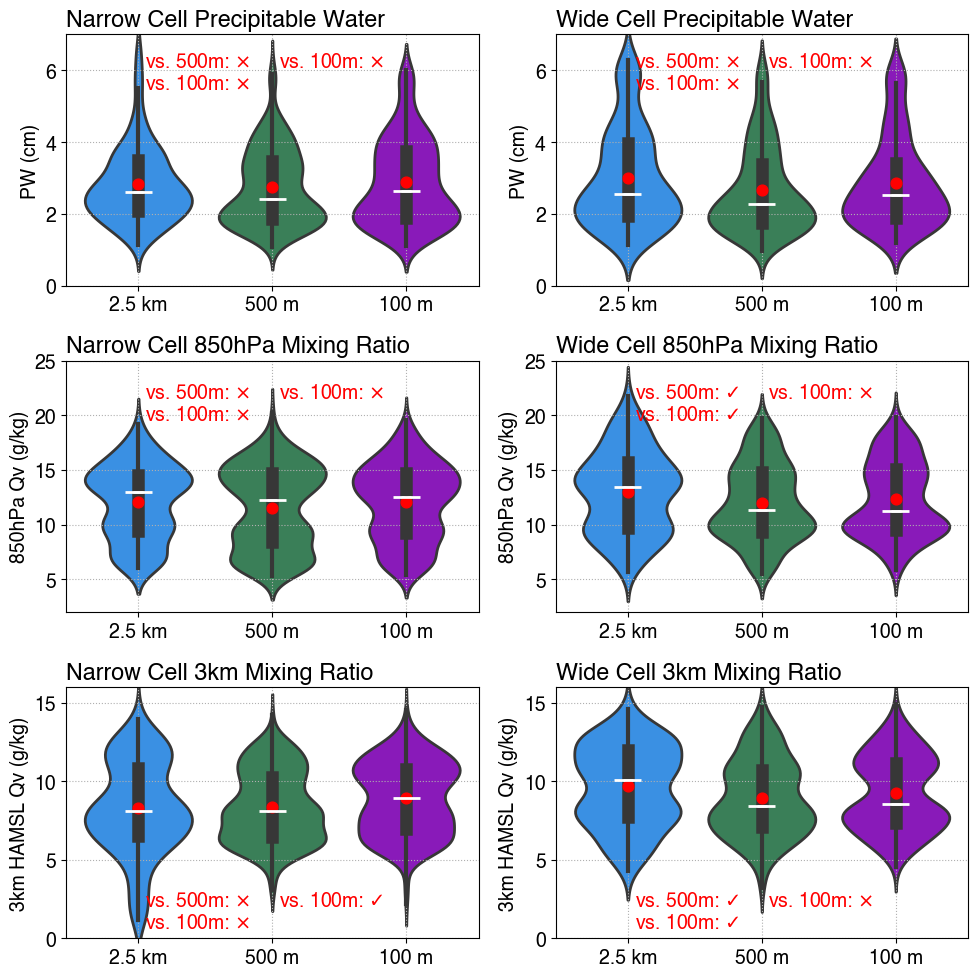

In [119]:
data_arr = [
    [[narrow_PW_d2.values, narrow_PW_d3.values, narrow_PW_d4.values],
     [wide_PW_d2.values, wide_PW_d3.values, wide_PW_d4.values]],
    [[narrow_Q850mb_d2.values, narrow_Q850mb_d3.values, narrow_Q850mb_d4.values],
     [wide_Q850mb_d2.values, wide_Q850mb_d3.values, wide_Q850mb_d4.values]],
    [[narrow_Q3km_d2.values, narrow_Q3km_d3.values, narrow_Q3km_d4.values],
     [wide_Q3km_d2.values, wide_Q3km_d3.values, wide_Q3km_d4.values]],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_PW23+'\n'+'vs. 100m: '+narrow_sig_PW23, 'd3':'vs. 100m: '+narrow_sig_PW34},
     {'d2':'vs. 500m: '+wide_sig_PW23+'\n'+'vs. 100m: '+wide_sig_PW23, 'd3':'vs. 100m: '+wide_sig_PW34},],
    [{'d2':'vs. 500m: '+narrow_sig_Q850mb23+'\n'+'vs. 100m: '+narrow_sig_Q850mb23, 'd3':'vs. 100m: '+narrow_sig_Q850mb34},
     {'d2':'vs. 500m: '+wide_sig_Q850mb23+'\n'+'vs. 100m: '+wide_sig_Q850mb23, 'd3':'vs. 100m: '+wide_sig_Q850mb34},],
    [{'d2':'vs. 500m: '+narrow_sig_Q3km23+'\n'+'vs. 100m: '+narrow_sig_Q3km23, 'd3':'vs. 100m: '+narrow_sig_Q3km34},
     {'d2':'vs. 500m: '+wide_sig_Q3km23+'\n'+'vs. 100m: '+wide_sig_Q3km23, 'd3':'vs. 100m: '+wide_sig_Q3km34},],
]
ypos_sig = [[6.5]*2, [23]*2, [3]*2]
titles = [
    ['Narrow Cell Precipitable Water', 'Wide Cell Precipitable Water'],
    ['Narrow Cell 850hPa Mixing Ratio','Wide Cell 850hPa Mixing Ratio'], 
    ['Narrow Cell 3km Mixing Ratio','Wide Cell 3km Mixing Ratio'], 
]
ylabels = [['PW (cm)']*2, ['850hPa Qv (g/kg)']*2, ['3km HAMSL Qv (g/kg)']*2]
ylims = [[(0,7)]*2, [(2,25)]*2, [(0,16)]*2]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 14
figsize = (10, 10)
# figname = f'{figdir}Violin_NarrowWide_RH_PW_d2_d3_d4.png'
figname = f'{figdir}Violin_NarrowWide_PW_Qv_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [87]:
# LCL temperature
narrow_sig_BWSacbl23 = kstest_data(narrow_BWSacbl_d2.values[~np.isnan(narrow_BWSacbl_d2)], 
                                     narrow_BWSacbl_d3.values[~np.isnan(narrow_BWSacbl_d3)], 'Narrow Cell BWSacbl D2 vs. D3', alpha=alpha)
narrow_sig_BWSacbl24 = kstest_data(narrow_BWSacbl_d2.values[~np.isnan(narrow_BWSacbl_d2)], 
                                     narrow_BWSacbl_d4.values[~np.isnan(narrow_BWSacbl_d4)], 'Narrow Cell BWSacbl D2 vs. D4', alpha=alpha)
narrow_sig_BWSacbl34 = kstest_data(narrow_BWSacbl_d3.values[~np.isnan(narrow_BWSacbl_d3)], 
                                     narrow_BWSacbl_d4.values[~np.isnan(narrow_BWSacbl_d4)], 'Narrow Cell BWSacbl D3 vs. D4', alpha=alpha)
# LCL height
narrow_sig_BWS03km23 = kstest_data(narrow_BWS03km_d2.values[~np.isnan(narrow_BWS03km_d2)], 
                                     narrow_BWS03km_d3.values[~np.isnan(narrow_BWS03km_d3)], 'Narrow Cell BWS03km D2 vs. D3', alpha=alpha)
narrow_sig_BWS03km24 = kstest_data(narrow_BWS03km_d2.values[~np.isnan(narrow_BWS03km_d2)], 
                                     narrow_BWS03km_d4.values[~np.isnan(narrow_BWS03km_d4)], 'Narrow Cell BWS03km D2 vs. D4', alpha=alpha)
narrow_sig_BWS03km34 = kstest_data(narrow_BWS03km_d3.values[~np.isnan(narrow_BWS03km_d3)], 
                                     narrow_BWS03km_d4.values[~np.isnan(narrow_BWS03km_d4)], 'Narrow Cell BWS03km D3 vs. D4', alpha=alpha)
# LFC height
narrow_sig_BWS06km23 = kstest_data(narrow_BWS06km_d2.values[~np.isnan(narrow_BWS06km_d2)], 
                                     narrow_BWS06km_d3.values[~np.isnan(narrow_BWS06km_d3)], 'Narrow Cell BWS06km D2 vs. D3', alpha=alpha)
narrow_sig_BWS06km24 = kstest_data(narrow_BWS06km_d2.values[~np.isnan(narrow_BWS06km_d2)], 
                                     narrow_BWS06km_d4.values[~np.isnan(narrow_BWS06km_d4)], 'Narrow Cell BWS06km D2 vs. D4', alpha=alpha)
narrow_sig_BWS06km34 = kstest_data(narrow_BWS06km_d3.values[~np.isnan(narrow_BWS06km_d3)], 
                                     narrow_BWS06km_d4.values[~np.isnan(narrow_BWS06km_d4)], 'Narrow Cell BWS06km D3 vs. D4', alpha=alpha)

# LCL temperature
wide_sig_BWSacbl23 = kstest_data(wide_BWSacbl_d2.values[~np.isnan(wide_BWSacbl_d2)], 
                                     wide_BWSacbl_d3.values[~np.isnan(wide_BWSacbl_d3)], 'Wide Cell BWSacbl D2 vs. D3', alpha=alpha)
wide_sig_BWSacbl24 = kstest_data(wide_BWSacbl_d2.values[~np.isnan(wide_BWSacbl_d2)], 
                                     wide_BWSacbl_d4.values[~np.isnan(wide_BWSacbl_d4)], 'Wide Cell BWSacbl D2 vs. D4', alpha=alpha)
wide_sig_BWSacbl34 = kstest_data(wide_BWSacbl_d3.values[~np.isnan(wide_BWSacbl_d3)], 
                                     wide_BWSacbl_d4.values[~np.isnan(wide_BWSacbl_d4)], 'Wide Cell BWSacbl D3 vs. D4', alpha=alpha)
# LCL height
wide_sig_BWS03km23 = kstest_data(wide_BWS03km_d2.values[~np.isnan(wide_BWS03km_d2)], 
                                     wide_BWS03km_d3.values[~np.isnan(wide_BWS03km_d3)], 'Wide Cell BWS03km D2 vs. D3', alpha=alpha)
wide_sig_BWS03km24 = kstest_data(wide_BWS03km_d2.values[~np.isnan(wide_BWS03km_d2)], 
                                     wide_BWS03km_d4.values[~np.isnan(wide_BWS03km_d4)], 'Wide Cell BWS03km D2 vs. D4', alpha=alpha)
wide_sig_BWS03km34 = kstest_data(wide_BWS03km_d3.values[~np.isnan(wide_BWS03km_d3)], 
                                     wide_BWS03km_d4.values[~np.isnan(wide_BWS03km_d4)], 'Wide Cell BWS03km D3 vs. D4', alpha=alpha)
# LFC height
wide_sig_BWS06km23 = kstest_data(wide_BWS06km_d2.values[~np.isnan(wide_BWS06km_d2)], 
                                     wide_BWS06km_d3.values[~np.isnan(wide_BWS06km_d3)], 'Wide Cell BWS06km D2 vs. D3', alpha=alpha)
wide_sig_BWS06km24 = kstest_data(wide_BWS06km_d2.values[~np.isnan(wide_BWS06km_d2)], 
                                     wide_BWS06km_d4.values[~np.isnan(wide_BWS06km_d4)], 'Wide Cell BWS06km D2 vs. D4', alpha=alpha)
wide_sig_BWS06km34 = kstest_data(wide_BWS06km_d3.values[~np.isnan(wide_BWS06km_d3)], 
                                     wide_BWS06km_d4.values[~np.isnan(wide_BWS06km_d4)], 'Wide Cell BWS06km D3 vs. D4', alpha=alpha)

Narrow Cell BWSacbl D2 vs. D3: Same distributions
Statistics=0.127, p=0.022
Narrow Cell BWSacbl D2 vs. D4: Same distributions
Statistics=0.138, p=0.012
Narrow Cell BWSacbl D3 vs. D4: Same distributions
Statistics=0.053, p=0.573
Narrow Cell BWS03km D2 vs. D3: Different distributions
Statistics=0.160, p=0.002
Narrow Cell BWS03km D2 vs. D4: Different distributions
Statistics=0.228, p=0.000
Narrow Cell BWS03km D3 vs. D4: Same distributions
Statistics=0.095, p=0.041
Narrow Cell BWS06km D2 vs. D3: Same distributions
Statistics=0.092, p=0.181
Narrow Cell BWS06km D2 vs. D4: Same distributions
Statistics=0.114, p=0.060
Narrow Cell BWS06km D3 vs. D4: Same distributions
Statistics=0.062, p=0.383
Wide Cell BWSacbl D2 vs. D3: Same distributions
Statistics=0.086, p=0.390
Wide Cell BWSacbl D2 vs. D4: Same distributions
Statistics=0.104, p=0.225
Wide Cell BWSacbl D3 vs. D4: Same distributions
Statistics=0.049, p=0.881
Wide Cell BWS03km D2 vs. D3: Different distributions
Statistics=0.296, p=0.000
Wide 

/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3578698/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


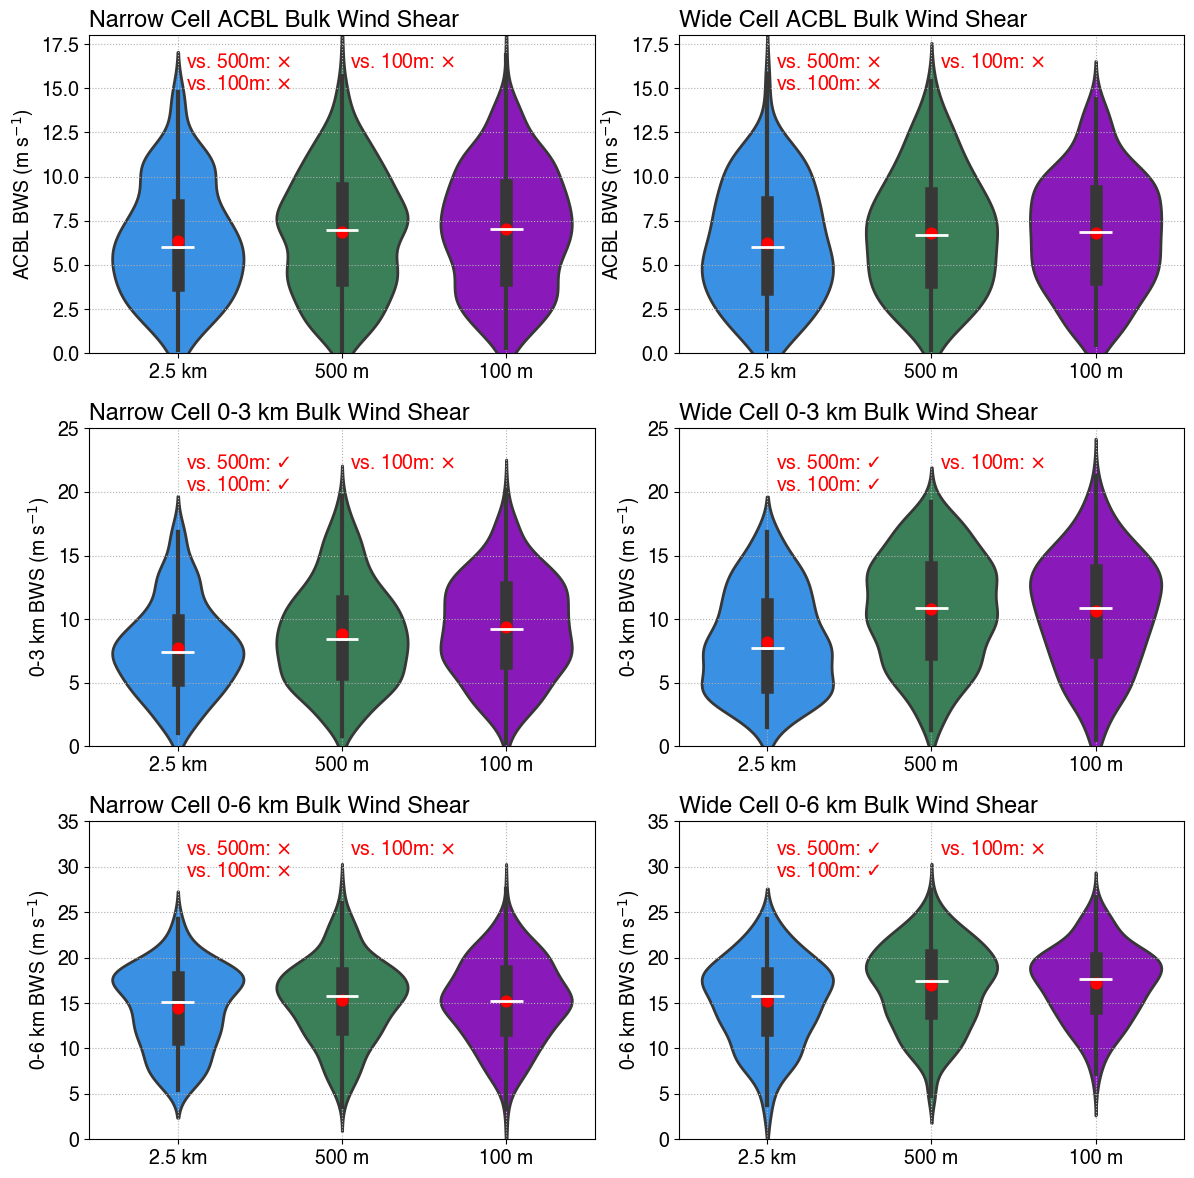

In [88]:
data_arr = [
    [[narrow_BWSacbl_d2.values, narrow_BWSacbl_d3.values, narrow_BWSacbl_d4.values],
     [wide_BWSacbl_d2.values, wide_BWSacbl_d3.values, wide_BWSacbl_d4.values]],
    [[narrow_BWS03km_d2.values, narrow_BWS03km_d3.values, narrow_BWS03km_d4.values],
     [wide_BWS03km_d2.values, wide_BWS03km_d3.values, wide_BWS03km_d4.values]],
    [[narrow_BWS06km_d2.values, narrow_BWS06km_d3.values, narrow_BWS06km_d4.values],
     [wide_BWS06km_d2.values, wide_BWS06km_d3.values, wide_BWS06km_d4.values]],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_BWSacbl23+'\n'+'vs. 100m: '+narrow_sig_BWSacbl23, 'd3':'vs. 100m: '+narrow_sig_BWSacbl34},
     {'d2':'vs. 500m: '+wide_sig_BWSacbl23+'\n'+'vs. 100m: '+wide_sig_BWSacbl23, 'd3':'vs. 100m: '+wide_sig_BWSacbl34},],
    [{'d2':'vs. 500m: '+narrow_sig_BWS03km23+'\n'+'vs. 100m: '+narrow_sig_BWS03km23, 'd3':'vs. 100m: '+narrow_sig_BWS03km34},
     {'d2':'vs. 500m: '+wide_sig_BWS03km23+'\n'+'vs. 100m: '+wide_sig_BWS03km23, 'd3':'vs. 100m: '+wide_sig_BWS03km34},],
    [{'d2':'vs. 500m: '+narrow_sig_BWS06km23+'\n'+'vs. 100m: '+narrow_sig_BWS06km23, 'd3':'vs. 100m: '+narrow_sig_BWS06km34},
     {'d2':'vs. 500m: '+wide_sig_BWS06km23+'\n'+'vs. 100m: '+wide_sig_BWS06km23, 'd3':'vs. 100m: '+wide_sig_BWS06km34},],
]
ypos_sig = [[17]*2, [23]*2, [33]*2]
titles = [
    ['Narrow Cell ACBL Bulk Wind Shear','Wide Cell ACBL Bulk Wind Shear'], 
    ['Narrow Cell 0-3 km Bulk Wind Shear','Wide Cell 0-3 km Bulk Wind Shear'], 
    ['Narrow Cell 0-6 km Bulk Wind Shear', 'Wide Cell 0-6 km Bulk Wind Shear'],
]
ylabels = [['ACBL BWS (m s$^{-1}$)']*2, ['0-3 km BWS (m s$^{-1}$)']*2, ['0-6 km BWS (m s$^{-1}$)']*2, ]
ylims = [[(0,18)]*2, [(0,25)]*2, [(0,35)]*2,]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 14
figsize = (12, 12)
figname = f'{figdir}Violin_NarrowWide_BWS_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

## Function to plot nrow x ncol of histogram

In [43]:
def plot_mxn_hist(nrow, ncol, da, hist_bins, xlabels=None, ylabels=None, titles=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
    bar_labels = list(name_map.values())
    bar_colors = list(lcolors.values())
    
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col]
            bar_data = da[row][col]
            bins = hist_bins[row][col]
            ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
            for src in range(len(bar_data)):
                ax.axvline(np.nanmedian(bar_data[src]), color=bar_colors[src], ls='--')
            ax.legend()
            # ax.set_xlim(xlims[row][col])
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':')
            
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

In [89]:
# bins_lifetime = np.arange(5,200,10)
# bins_maxdbz = np.arange(10, 71, 5)
# bins_eth10dbz = np.arange(0, 21, 1)
# hist_bins = [
#     [bins_lifetime] * 2,
#     [bins_maxdbz] * 2,
#     [bins_eth10dbz] * 2,
# ]
# data_arr = [
#     [[narrow_track_lifetime_d2, narrow_track_lifetime_d3, narrow_track_lifetime_d4],[wide_track_lifetime_d2, wide_track_lifetime_d3, wide_track_lifetime_d4]],
#     [[narrow_maxdbz_d2, narrow_maxdbz_d3, narrow_maxdbz_d4],[wide_maxdbz_d2, wide_maxdbz_d3, wide_maxdbz_d4]],
#     [[narrow_maxETH10dbz_d2, narrow_maxETH10dbz_d3, narrow_maxETH10dbz_d4],[wide_maxETH10dbz_d2, wide_maxETH10dbz_d3, wide_maxETH10dbz_d4]],
# ]
# titles = [['Narrow Cell Lifetime','Wide Cell Lifetime'], ['Narrow Cell Max Reflectivity','Wide Cell Max Reflectivity'], ['Narrow Cell Max Echo-top', 'Wide Cell Max Echo-top']]
# xlabels = [['Lifetime (min)']*2, ['Max Reflectivity (dBZ)']*2, ['Max 10dBZ ETH (km)']*2, ]
# ylabels = [['PDF',''], ['PDF',''], ['PDF',''],]
# nrow = len(data_arr)
# ncol = len(data_arr[0]) if data_arr else 0

# fontsize = 14
# figsize = (12, 12)
# figname = f'{figdir}PDF_NarrowWide_Lifetime_maxRefl_maxETH10dBZ_d2_d3_d4.png'
# fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [90]:
# preCI_t = -3  # preCI time to get a single value

# bins_EL = np.arange(6,17.1,1)
# bins_CAPE = np.arange(0, 7001, 500)
# bins_CAPEacbl = np.arange(-150, 201, 25)
# bins_CIN = np.arange(-100, 0.1, 5)
# hist_bins = [
#     [bins_EL] * 2,
#     [bins_CAPE] * 2,
#     [bins_CAPEacbl] * 2,
#     [bins_CIN] * 2,
# ]
# data_arr = [
#     [[narrow_pELmu_d2.sel(times=preCI_t), narrow_pELmu_d3.sel(times=preCI_t), narrow_pELmu_d4.sel(times=preCI_t)],
#      [wide_pELmu_d2.sel(times=preCI_t), wide_pELmu_d3.sel(times=preCI_t), wide_pELmu_d4.sel(times=preCI_t)]],
#     [[narrow_pCAPEmu_d2.sel(times=preCI_t), narrow_pCAPEmu_d3.sel(times=preCI_t), narrow_pCAPEmu_d4.sel(times=preCI_t)],
#      [wide_pCAPEmu_d2.sel(times=preCI_t), wide_pCAPEmu_d3.sel(times=preCI_t), wide_pCAPEmu_d4.sel(times=preCI_t)]],
#     [[narrow_pCAPEacbl_d2.sel(times=preCI_t), narrow_pCAPEacbl_d3.sel(times=preCI_t), narrow_pCAPEacbl_d4.sel(times=preCI_t)],
#      [wide_pCAPEacbl_d2.sel(times=preCI_t), wide_pCAPEacbl_d3.sel(times=preCI_t), wide_pCAPEacbl_d4.sel(times=preCI_t)]],
#     [[narrow_pCINmu_d2.sel(times=preCI_t), narrow_pCINmu_d3.sel(times=preCI_t), narrow_pCINmu_d4.sel(times=preCI_t)],
#      [wide_pCINmu_d2.sel(times=preCI_t), wide_pCINmu_d3.sel(times=preCI_t), wide_pCINmu_d4.sel(times=preCI_t)]],
# ]
# titles = [
#     ['Narrow Cell MU LNB','Wide Cell MU LNB'], 
#     ['Narrow Cell MU CAPE','Wide Cell MU CAPE'], 
#     ['Narrow Cell ACBL CAPE', 'Wide Cell ACBL CAPE'],
#     ['Narrow Cell MU CIN', 'Wide Cell MU CIN'],
# ]
# xlabels = [['MU LNB (km)']*2, ['MU CAPE (J kg$^{-1}$)']*2, ['ACBL CAPE (J kg$^{-1}$)']*2, ['MU CIN (J kg$^{-1}$)']*2]
# ylabels = [['PDF',''], ['PDF',''], ['PDF',''], ['PDF','']]
# nrow = len(data_arr)
# ncol = len(data_arr[0]) if data_arr else 0

# fontsize = 12
# figsize = (10, 12)
# figname = f'{figdir}PDF_NarrowWide_pEL_pCAPE_pCIN_d2_d3_d4.png'
# fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [91]:
# preCI_t = -3  # preCI time to get a single value

# bins_LCLz = np.arange(0, 4.6, 0.5)
# bins_LCLt = np.arange(260, 305.1, 5)
# bins_LFCz = np.arange(0, 4.6, 0.5)
# hist_bins = [
#     [bins_LCLt] * 2,
#     [bins_LCLz] * 2,
#     [bins_LFCz] * 2,
# ]
# data_arr = [
#     [[narrow_LCLt_d2.sel(times=preCI_t), narrow_LCLt_d3.sel(times=preCI_t), narrow_LCLt_d4.sel(times=preCI_t)],
#      [wide_LCLt_d2.sel(times=preCI_t), wide_LCLt_d3.sel(times=preCI_t), wide_LCLt_d4.sel(times=preCI_t)]],
#     [[narrow_LCLz_d2.sel(times=preCI_t), narrow_LCLz_d3.sel(times=preCI_t), narrow_LCLz_d4.sel(times=preCI_t)],
#      [wide_LCLz_d2.sel(times=preCI_t), wide_LCLz_d3.sel(times=preCI_t), wide_LCLz_d4.sel(times=preCI_t)]],
#     [[narrow_pLFCz_d2.sel(times=preCI_t), narrow_pLFCz_d3.sel(times=preCI_t), narrow_pLFCz_d4.sel(times=preCI_t)],
#      [wide_pLFCz_d2.sel(times=preCI_t), wide_pLFCz_d3.sel(times=preCI_t), wide_pLFCz_d4.sel(times=preCI_t)]],
# ]
# titles = [
#     ['Narrow Cell LCL Temperature','Wide Cell LCL Temperature'], 
#     ['Narrow Cell LCL Height','Wide Cell LCL Height'], 
#     ['Narrow Cell MU LFC Height', 'Wide Cell MU LFC Height'],
# ]
# xlabels = [['LCL Temp (K)']*2, ['LCL Height (km)']*2, ['LFC Height (km)']*2, ]
# ylabels = [['PDF',''], ['PDF',''], ['PDF',''], ]
# nrow = len(data_arr)
# ncol = len(data_arr[0]) if data_arr else 0

# fontsize = 14
# figsize = (12, 12)
# figname = f'{figdir}PDF_NarrowWide_LCL_pLFC_d2_d3_d4.png'
# fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [92]:
# preCI_t = -3  # preCI time to get a single value

# bins_RHacbl = np.arange(30, 101, 10)
# bins_RH600 = np.arange(0, 101, 10)
# bins_PW = np.arange(1, 7.1, 0.5)
# hist_bins = [
#     [bins_RHacbl] * 2,
#     [bins_RH600] * 2,
#     [bins_RH600] * 2,
#     [bins_RH600] * 2,
#     [bins_PW] * 2,
# ]
# data_arr = [
#     [[narrow_RHacbl_d2.sel(times=preCI_t), narrow_RHacbl_d3.sel(times=preCI_t), narrow_RHacbl_d4.sel(times=preCI_t)],
#      [wide_RHacbl_d2.sel(times=preCI_t), wide_RHacbl_d3.sel(times=preCI_t), wide_RHacbl_d4.sel(times=preCI_t)]],
#     [[narrow_RHlfc1500_d2.sel(times=preCI_t), narrow_RHlfc1500_d3.sel(times=preCI_t), narrow_RHlfc1500_d4.sel(times=preCI_t)],
#      [wide_RHlfc1500_d2.sel(times=preCI_t), wide_RHlfc1500_d3.sel(times=preCI_t), wide_RHlfc1500_d4.sel(times=preCI_t)]],
#     [[narrow_RH600mb_d2.sel(times=preCI_t), narrow_RH600mb_d3.sel(times=preCI_t), narrow_RH600mb_d4.sel(times=preCI_t)],
#      [wide_RH600mb_d2.sel(times=preCI_t), wide_RH600mb_d3.sel(times=preCI_t), wide_RH600mb_d4.sel(times=preCI_t)]],
#     [[narrow_RH500mb_d2.sel(times=preCI_t), narrow_RH500mb_d3.sel(times=preCI_t), narrow_RH500mb_d4.sel(times=preCI_t)],
#      [wide_RH500mb_d2.sel(times=preCI_t), wide_RH500mb_d3.sel(times=preCI_t), wide_RH500mb_d4.sel(times=preCI_t)]],
#     [[narrow_PW_d2.sel(times=preCI_t), narrow_PW_d3.sel(times=preCI_t), narrow_PW_d4.sel(times=preCI_t)],
#      [wide_PW_d2.sel(times=preCI_t), wide_PW_d3.sel(times=preCI_t), wide_PW_d4.sel(times=preCI_t)]],
# ]
# titles = [
#     ['Narrow Cell ACBL RH','Wide Cell ACBL RH'], 
#     ['Narrow Cell ACBL+1.5km RH','Wide Cell ACBL+1.5km RH'], 
#     ['Narrow Cell 600hPa RH','Wide Cell 600hPa RH'], 
#     ['Narrow Cell 500hPa RH', 'Wide Cell 500hPa RH'],
#     ['Narrow Cell Precipitable Water', 'Wide Cell Precipitable Water'],
# ]
# xlabels = [['ACBL RH (%)']*2, ['ACBL+1.5km RH (%)']*2, ['600hPa RH (%)']*2, ['500hPa RH (%)']*2, ['PW (cm)']*2]
# ylabels = [['PDF',''], ['PDF',''], ['PDF',''], ['PDF',''], ['PDF','']]
# nrow = len(data_arr)
# ncol = len(data_arr[0]) if data_arr else 0

# fontsize = 12
# figsize = (10, 15)
# figname = f'{figdir}PDF_NarrowWide_RH_PW_d2_d3_d4.png'
# fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [93]:
# preCI_t = -3  # preCI time to get a single value

# bins_BWSacbl = np.arange(0, 18.1, 2)
# bins_BWS03km = np.arange(0, 25.1, 2.5)
# bins_BWS06km = np.arange(0, 35.1, 5)
# hist_bins = [
#     [bins_BWSacbl] * 2,
#     [bins_BWS03km] * 2,
#     [bins_BWS06km] * 2,
# ]
# data_arr = [
#     [[narrow_BWSacbl_d2.sel(times=preCI_t), narrow_BWSacbl_d3.sel(times=preCI_t), narrow_BWSacbl_d4.sel(times=preCI_t)],
#      [wide_BWSacbl_d2.sel(times=preCI_t), wide_BWSacbl_d3.sel(times=preCI_t), wide_BWSacbl_d4.sel(times=preCI_t)]],
#     [[narrow_BWS03km_d2.sel(times=preCI_t), narrow_BWS03km_d3.sel(times=preCI_t), narrow_BWS03km_d4.sel(times=preCI_t)],
#      [wide_BWS03km_d2.sel(times=preCI_t), wide_BWS03km_d3.sel(times=preCI_t), wide_BWS03km_d4.sel(times=preCI_t)]],
#     [[narrow_BWS06km_d2.sel(times=preCI_t), narrow_BWS06km_d3.sel(times=preCI_t), narrow_BWS06km_d4.sel(times=preCI_t)],
#      [wide_BWS06km_d2.sel(times=preCI_t), wide_BWS06km_d3.sel(times=preCI_t), wide_BWS06km_d4.sel(times=preCI_t)]],
# ]
# titles = [
#     ['Narrow Cell ACBL Bulk Wind Shear','Wide Cell ACBL Bulk Wind Shear'], 
#     ['Narrow Cell 0-3 km Bulk Wind Shear','Wide Cell 0-3 km Bulk Wind Shear'], 
#     ['Narrow Cell 0-6 km Bulk Wind Shear', 'Wide Cell 0-6 km Bulk Wind Shear'],
# ]
# xlabels = [['ACBL BWS (m s$^{-1}$)']*2, ['0-3 km BWS (m s$^{-1}$)']*2, ['0-6 km BWS (m s$^{-1}$)']*2, ]
# ylabels = [['PDF',''], ['PDF',''], ['PDF',''], ]
# nrow = len(data_arr)
# ncol = len(data_arr[0]) if data_arr else 0

# fontsize = 14
# figsize = (12, 12)
# figname = f'{figdir}PDF_NarrowWide_BWS_d2_d3_d4.png'
# fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [94]:
# figname